## **ANÁLISIS DE SLOPE UNITS CON EVENTOS DE LLUVIA DE RADAR**

### **ANÁLISIS CON EL INVENTARIO DE SENSORES REMOTOS**

In [1]:
# ── Densidad de pendientes por tipo de ladera ──────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === 1) Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

In [9]:
su['slope_mean']

0        22.804145
1        36.675028
2        30.573870
3        17.069585
4        21.984775
           ...    
57519    12.720728
57520    28.823678
57521    25.816091
57522    39.192384
57523    27.518582
Name: slope_mean, Length: 57524, dtype: float64

In [8]:

su['flowacum_m'].describe()

count    5.752400e+04
mean     4.455451e+03
std      6.619213e+04
min      1.810811e+00
25%      3.183245e+01
50%      6.202789e+01
75%      3.051375e+02
max      3.098407e+06
Name: flowacum_m, dtype: float64

In [ ]:
su['tpi_mean'].describe()


count    57524.000000
mean         4.473355
std          0.503511
min          2.596671
25%          4.112168
50%          4.420217
75%          4.791457
max          9.260953
Name: twi_mean, dtype: float64

In [11]:
su['twi_mean'].describe()

count    57524.000000
mean         4.473355
std          0.503511
min          2.596671
25%          4.112168
50%          4.420217
75%          4.791457
max          9.260953
Name: twi_mean, dtype: float64

In [13]:
su['curvatura'].unique()

array([4, 2, 5, 3, 9, 1, 6])

In [18]:
'slope_mean'
'aspect_maj'
'flowacum_m'
'tpi_mean'
'twi_mean'
'curvatura'


'curvatura'

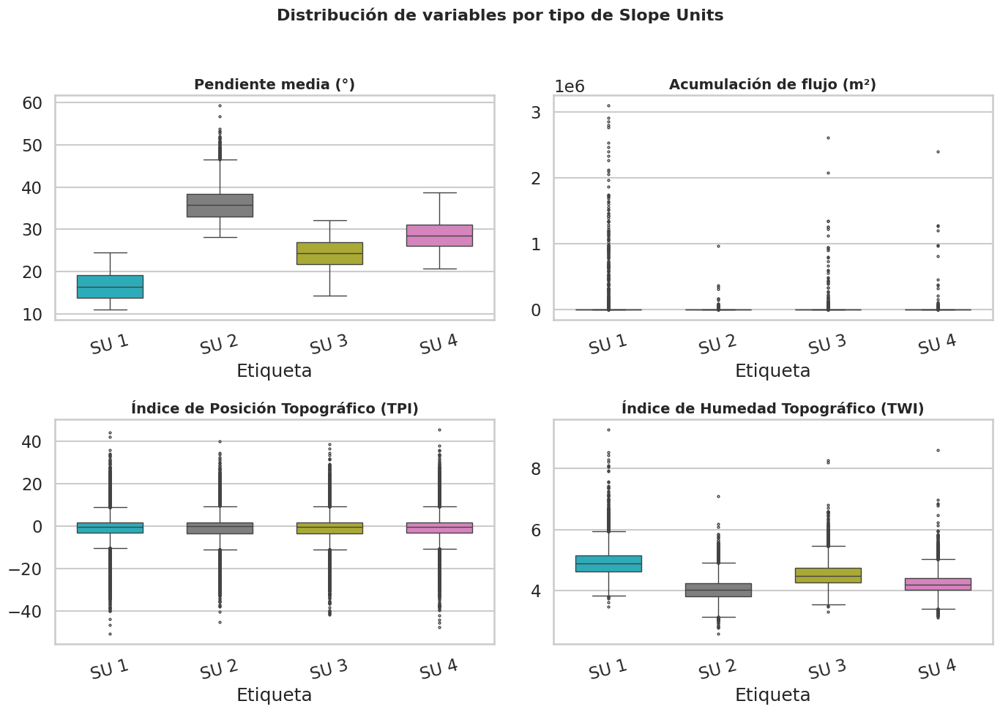

In [21]:
# ── Densidad de pendientes por tipo de ladera ──────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === 1) Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# === 2) Saneo mínimo ===
su['cluster4']   = pd.to_numeric(su['cluster4'], errors='coerce').astype('Int64')
su['slope_mean'] = pd.to_numeric(su['slope_mean'], errors='coerce')

# Filtrar clases válidas y pendientes no negativas
valid = [0, 1, 2, 3]
su = su[su['cluster4'].isin(valid) & su['slope_mean'].notna() & (su['slope_mean'] >= 0)].copy()

# Mapear descripciones y asegurar orden de leyenda
# desc_map = {
#     0: 'Pendientes\nmoderadas',
#     1: 'Pendientes\nescarpadas',
#     2: 'Pendientes\nfuertes',
#     3: 'Pendientes\nmuy fuertes'
# }

desc_map = {
    0: 'SU 1',
    1: 'SU 2',
    2: 'SU 3',
    3: 'SU 4'
}

su['Etiqueta'] = su['cluster4'].map(desc_map)

cat_order = [desc_map[i] for i in valid]  # 0→3
su['Etiqueta'] = pd.Categorical(su['Etiqueta'], categories=cat_order, ordered=True)

# Colores provistos (mapeados por etiqueta en el mismo orden 0→3)
palette = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']
pal_dict = {lab: col for lab, col in zip(cat_order, palette)}


# Variables numéricas a explorar
variables = ['slope_mean', 'flowacum_m', 'tpi_mean', 'twi_mean']
titulos   = {
    'slope_mean': 'Pendiente media (°)',
    'flowacum_m': 'Acumulación de flujo (m²)',
    'tpi_mean':   'Índice de Posición Topográfico (TPI)',
    'twi_mean':   'Índice de Humedad Topográfico (TWI)'
}

# Configuración general de estilo
sns.set_theme(style="whitegrid", context="talk")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, var in zip(axes, variables):
    sns.boxplot(
        data=su,
        x='Etiqueta', y=var,
        hue='Etiqueta',          # nuevo
        palette=pal_dict,
        ax=ax,
        width=0.6,
        fliersize=2,
        dodge=False
    )
    ax.set_title(titulos[var], fontsize=14, weight='bold')
    #ax.set_xlabel("Tipo de Slope Unit")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=15)

    # quitar leyenda redundante
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.suptitle("Distribución de variables por tipo de Slope Units", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



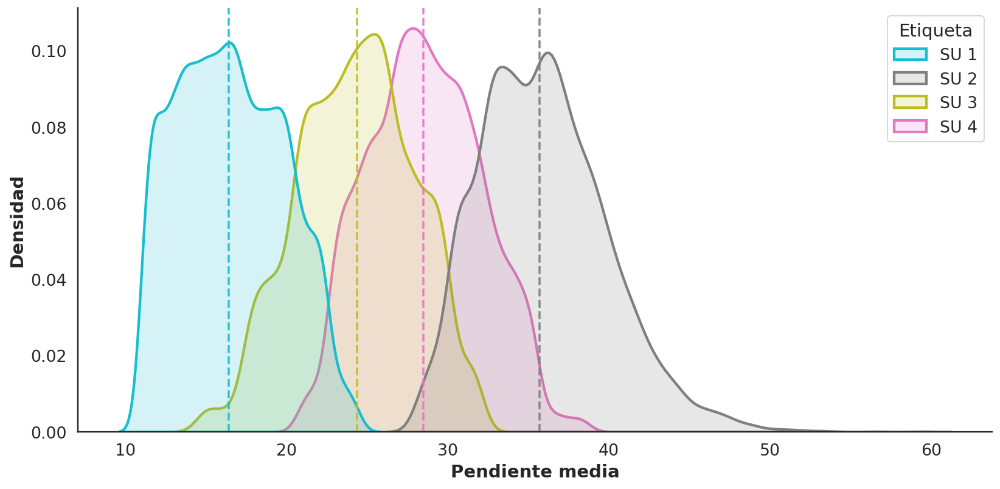

In [14]:
# ── Densidad de pendientes por tipo de ladera ──────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === 1) Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# === 2) Saneo mínimo ===
su['cluster4']   = pd.to_numeric(su['cluster4'], errors='coerce').astype('Int64')
su['slope_mean'] = pd.to_numeric(su['slope_mean'], errors='coerce')

# Filtrar clases válidas y pendientes no negativas
valid = [0, 1, 2, 3]
su = su[su['cluster4'].isin(valid) & su['slope_mean'].notna() & (su['slope_mean'] >= 0)].copy()

# Mapear descripciones y asegurar orden de leyenda
# desc_map = {
#     0: 'Pendientes\nmoderadas',
#     1: 'Pendientes\nescarpadas',
#     2: 'Pendientes\nfuertes',
#     3: 'Pendientes\nmuy fuertes'
# }

desc_map = {
    0: 'SU 1',
    1: 'SU 2',
    2: 'SU 3',
    3: 'SU 4'
}

su['Etiqueta'] = su['cluster4'].map(desc_map)

cat_order = [desc_map[i] for i in valid]  # 0→3
su['Etiqueta'] = pd.Categorical(su['Etiqueta'], categories=cat_order, ordered=True)

# Colores provistos (mapeados por etiqueta en el mismo orden 0→3)
palette = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']
pal_dict = {lab: col for lab, col in zip(cat_order, palette)}

# === 3) Gráfico KDE (superpuesto) ===
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.25)

fig, ax = plt.subplots(figsize=(12, 6), dpi=140)

sns.kdeplot(
    data=su, x='slope_mean', hue='Etiqueta',
    fill=True, common_norm=False, alpha=0.18, linewidth=2.2,
    bw_adjust=1.0, clip=(0, None), palette=pal_dict, ax=ax
)

# Medianas por tipo (línea punteada del mismo color)
medianas = su.groupby('Etiqueta')['slope_mean'].median()
for lab, med in medianas.items():
    ax.axvline(med, color=pal_dict[lab], linestyle='--', linewidth=1.8, alpha=0.9)
# Nota visual para medianas
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([0], [0], color='black', linestyle='--', linewidth=1.8)]
labels  += ['Mediana']
#ax.legend(handles, labels, title='Tipo de ladera', frameon=False, ncol=2)

# Etiquetas y estética
ax.set_xlabel('Pendiente media', weight='bold')
ax.set_ylabel('Densidad', weight='bold')
# ax.set_title('Distribución de pendientes por tipo de ladera', weight='bold', pad=12)

ax.spines[['right','top']].set_visible(False)
ax.grid(False)
plt.tight_layout()
# plt.savefig('kde_pendiente_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()

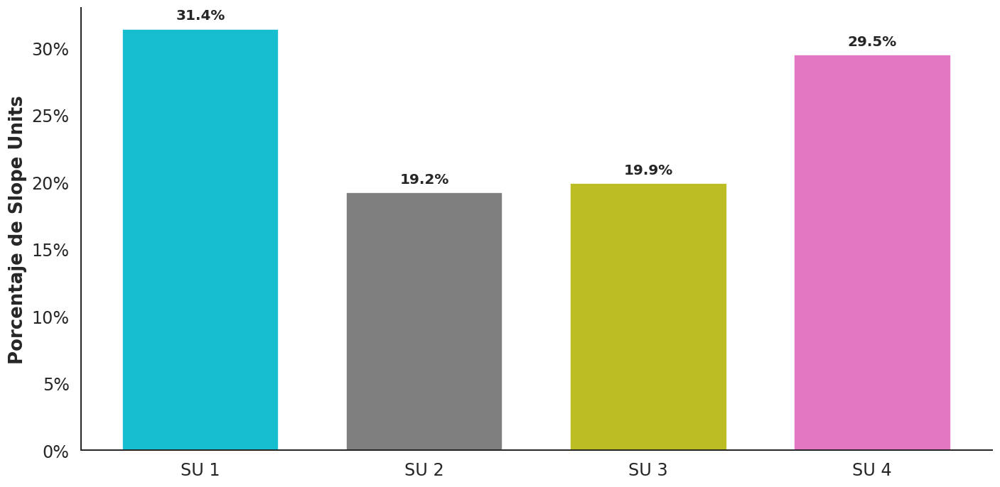

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import os

# === 1. Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# === 2. Calcular porcentajes de cada tipo de ladera ===
# Contar unidades por tipo
counts = su['cluster4'].value_counts().sort_index()

# Calcular porcentajes
percentages = counts / counts.sum()

# Crear DataFrame para graficar
df = pd.DataFrame({
    'Tipo de Ladera': counts.index,
    'Porcentaje': percentages.values
})

# Mapear descripciones
# desc_map = {
#     0: 'Pendientes\nmoderadas',
#     1: 'Pendientes\nescarpadas',
#     2: 'Pendientes\nfuertes',
#     3: 'Pendientes\nmuy fuertes'
# }

desc_map = {
    0: 'SU 1',
    1: 'SU 2',
    2: 'SU 3',
    3: 'SU 4'
}

df['Descripción'] = df['Tipo de Ladera'].map(desc_map)
# Ordenar por porcentaje de mayor a menor
#df = df.sort_values(by='Porcentaje', ascending=False).reset_index(drop=True)
# Ordenar para que queden SU 1, SU 2, SU 3, SU 4
df = df.sort_values(by='Tipo de Ladera', ascending=True).reset_index(drop=True)


# === 3. Graficar ===
palette = ['#17becf', '#7f7f7f', '#bcbd22','#e377c2']

sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(df['Descripción'], df['Porcentaje'], 
              color=[palette[i] for i in df['Tipo de Ladera']], width=0.7)

# Etiquetas encima de cada barra
for bar, pct in zip(bars, df['Porcentaje']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{pct*100:.1f}%',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Formato del eje Y
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Etiquetas y título
ax.set_ylabel('Porcentaje de Slope Units', weight='bold')
ax.set_xlabel('')
#ax.set_title('Distribución de tipos de laderas en la zona de estudio', weight='bold', pad=15)

# Quitar bordes innecesarios
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Fondo blanco
ax.set_facecolor('white')
ax.grid(False)

plt.tight_layout()
#plt.savefig('porcentaje_tipos_laderas.png', dpi=300, bbox_inches='tight')
plt.show()

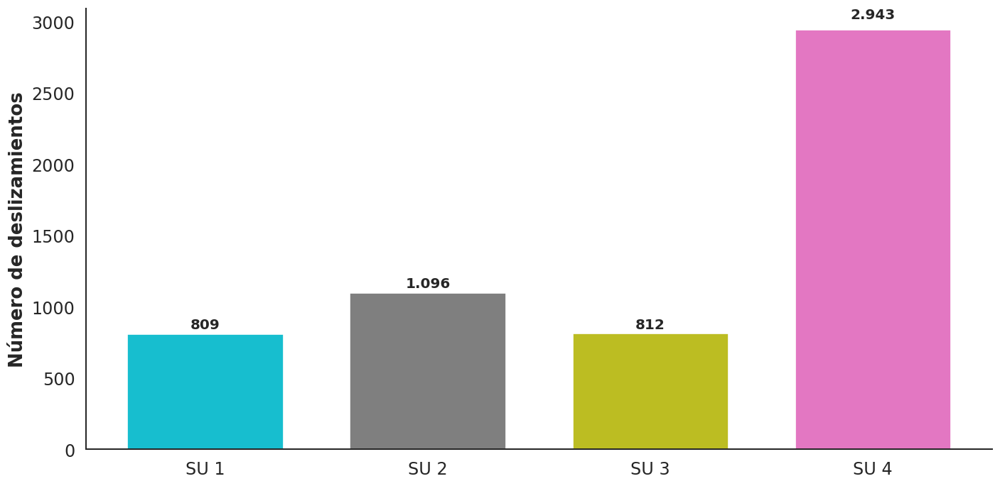

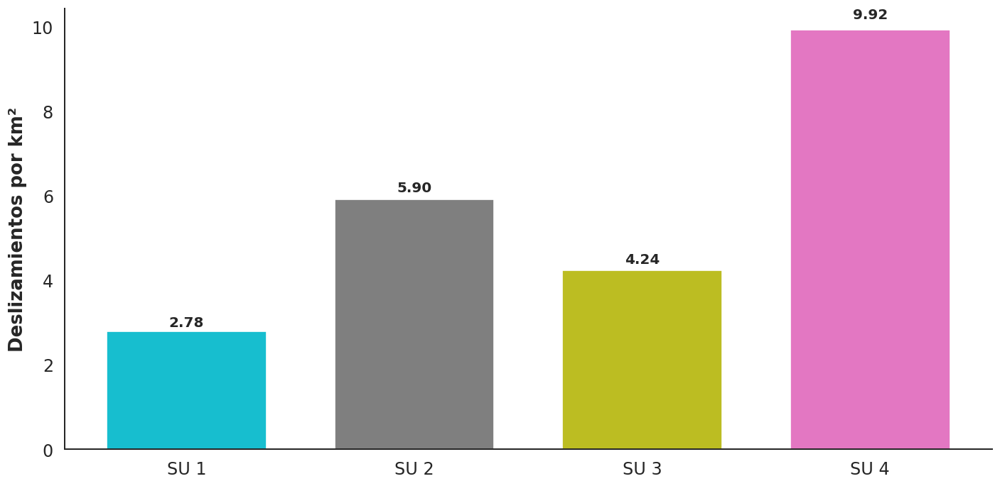

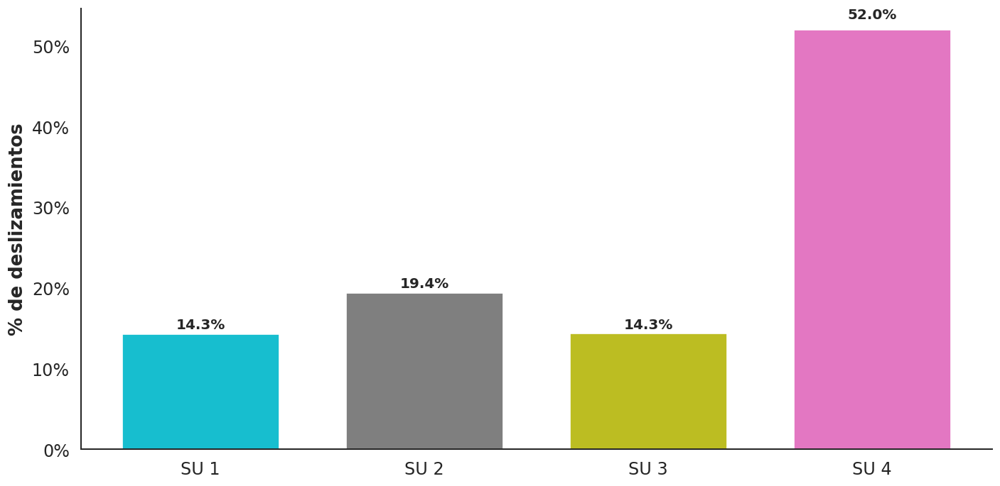

In [6]:
# === Distribución y densidad de deslizamientos por tipo de ladera (orden SU1..SU4) ===
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
# ------------------------------
# 1) Cargar y preparar datos
# ------------------------------
dir_data   = '../../DATA/shape_files/'
shp_name   = 'slope_units_analisis.shp'
COL_CLUSTER = 'cluster4'
COL_SLIDES  = 'n_mm'

# Mapas y orden fijo
desc_map = {0: 'SU 1', 1: 'SU 2', 2: 'SU 3', 3: 'SU 4'}
desc_to_code = {v: k for k, v in desc_map.items()}
ORDER = ['SU 1', 'SU 2', 'SU 3', 'SU 4']
palette = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']  # 0,1,2,3

gdf = gpd.read_file(os.path.join(dir_data, shp_name))
gdf[COL_CLUSTER] = pd.to_numeric(gdf[COL_CLUSTER], errors='coerce')
gdf[COL_SLIDES]  = pd.to_numeric(gdf[COL_SLIDES],  errors='coerce').fillna(0)
gdf = gdf.loc[gdf.geometry.notna() & gdf[COL_CLUSTER].isin([0,1,2,3])].copy()
gdf['tipo'] = gdf[COL_CLUSTER].map(desc_map)

# ------------------------------
# 2) Totales por tipo (orden SU1..SU4)
# ------------------------------
totales_tipo = gdf.groupby('tipo', as_index=True)[COL_SLIDES].sum()
totales_tipo = totales_tipo.reindex(ORDER).fillna(0)  # asegurar orden y presencia de las 4 categorías
df_tot = totales_tipo.reset_index(name='Deslizamientos')

# ------------------------------
# 3) Densidad por km² (orden SU1..SU4)
# ------------------------------
# Determinar UTM aproximado
gdf_wgs = gdf.to_crs(4326)
c = gdf_wgs.unary_union.centroid
zone = int((c.x + 180)//6) + 1
epsg = int(f"{326 if c.y >= 0 else 327}{zone:02d}")  # 326xx norte, 327xx sur

gdf_m = gdf.to_crs(epsg)
gdf_m['area_km2'] = gdf_m.geometry.area / 1e6
gdf_m = gdf_m.loc[gdf_m['area_km2'] > 0].copy()
gdf_m['dens_su_km2'] = gdf_m[COL_SLIDES] / gdf_m['area_km2']

agg = (
    gdf_m.groupby('tipo')
         .agg(
             n_su=('tipo', 'size'),
             deslizamientos_totales=(COL_SLIDES, 'sum'),
             area_total_km2=('area_km2', 'sum')
         )
)
agg['densidad_tipo_km2'] = agg['deslizamientos_totales'] / agg['area_total_km2']
agg = agg.reindex(ORDER)  # asegurar orden
agg[['n_su','deslizamientos_totales','area_total_km2','densidad_tipo_km2']] = \
    agg[['n_su','deslizamientos_totales','area_total_km2','densidad_tipo_km2']].fillna(0)

# ------------------------------
# 4) Estilo y utilidades de gráfico
# ------------------------------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

def format_axes(ax, ylabel):
    ax.set_ylabel(ylabel, weight='bold')
    ax.set_xlabel('')
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.set_facecolor('white')
    ax.grid(False)

def add_labels(ax, bars, fmt):
    for b in bars:
        v = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            v + (0.02*v if v > 0 else 0.02),
            fmt(v),
            ha='center', va='bottom', fontsize=12, weight='bold'
        )

# ------------------------------
# 5) Gráfico: Totales (orden SU1..SU4)
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
colors_tot = [palette[desc_to_code[t]] for t in df_tot['tipo']]
bars = ax.bar(df_tot['tipo'], df_tot['Deslizamientos'], color=colors_tot, width=0.7)
add_labels(ax, bars, lambda v: f'{int(v):,}'.replace(',', '.'))
format_axes(ax, 'Número de deslizamientos')
plt.tight_layout()
plt.show()

# ------------------------------
# 6) Gráfico: Densidad (des/km²) (orden SU1..SU4)
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
colors_den = [palette[desc_to_code[t]] for t in agg.index]
bars2 = ax.bar(agg.index, agg['densidad_tipo_km2'].values, color=colors_den, width=0.7)
add_labels(ax, bars2, lambda v: f'{v:.2f}')
format_axes(ax, 'Deslizamientos por km²')
plt.tight_layout()
plt.show()

# ------------------------------
# 7) % de Slope Units con deslizamientos por tipo (orden SU1..SU4)
#    (corrige el error de longitudes desalineadas)
# ------------------------------
su_con_slides = gdf.loc[gdf[COL_SLIDES] > 0].copy()

# Conteos totales de SUs por tipo y de SUs con deslizamientos por tipo, alineados y completos
counts_total_su  = gdf['tipo'].value_counts().reindex(ORDER).fillna(0)
counts_con_slide = su_con_slides['tipo'].value_counts().reindex(ORDER).fillna(0)

# Porcentaje de SUs con deslizamientos dentro de cada tipo
percentages_slides = (counts_con_slide / counts_total_su.replace(0, pd.NA)).fillna(0)

df_slides = pd.DataFrame({
    'Tipo de Ladera': ORDER,
    'Porcentaje con Deslizamientos': percentages_slides.values
})

# fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
# colors_pct = [palette[desc_to_code[t]] for t in df_slides['Tipo de Ladera']]
# bars3 = ax.bar(df_slides['Tipo de Ladera'], df_slides['Porcentaje con Deslizamientos'],
#                color=colors_pct, width=0.7)
# add_labels(ax, bars3, lambda v: f'{v*100:.1f}%')
# format_axes(ax, '% Slope Units con deslizamientos')
# plt.tight_layout()
# plt.show()

# ------------------------------
# 8) NUEVO: % de deslizamientos por tipo respecto al total (orden SU1..SU4)
# ------------------------------
desliz_por_tipo = totales_tipo.copy()  # ya está reindexado a ORDER
total_desliz = desliz_por_tipo.sum()
pct_desliz_total = (desliz_por_tipo / total_desliz) if total_desliz > 0 else desliz_por_tipo*0

df_pct_total = pd.DataFrame({
    'Tipo de Ladera': ORDER,
    'Porcentaje del total de deslizamientos': pct_desliz_total.values
})


fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
colors_pct2 = [palette[desc_to_code[t]] for t in df_pct_total['Tipo de Ladera']]
bars4 = ax.bar(df_pct_total['Tipo de Ladera'],
               df_pct_total['Porcentaje del total de deslizamientos'],
               color=colors_pct2, width=0.7)
add_labels(ax, bars4, lambda v: f'{v*100:.1f}%')
format_axes(ax, '% de deslizamientos')

# Mostrar eje Y en porcentaje
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

plt.tight_layout()
plt.show()


### **MAPA**

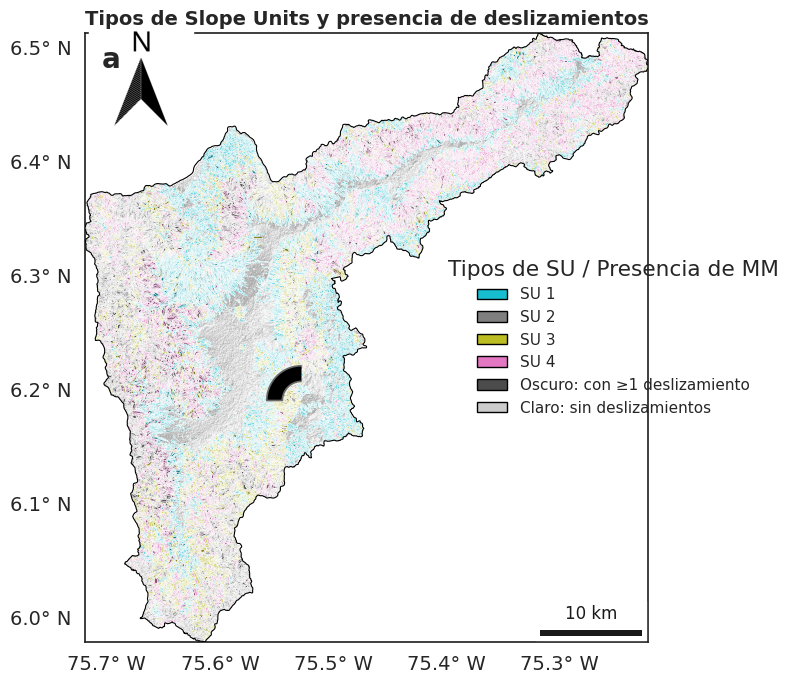

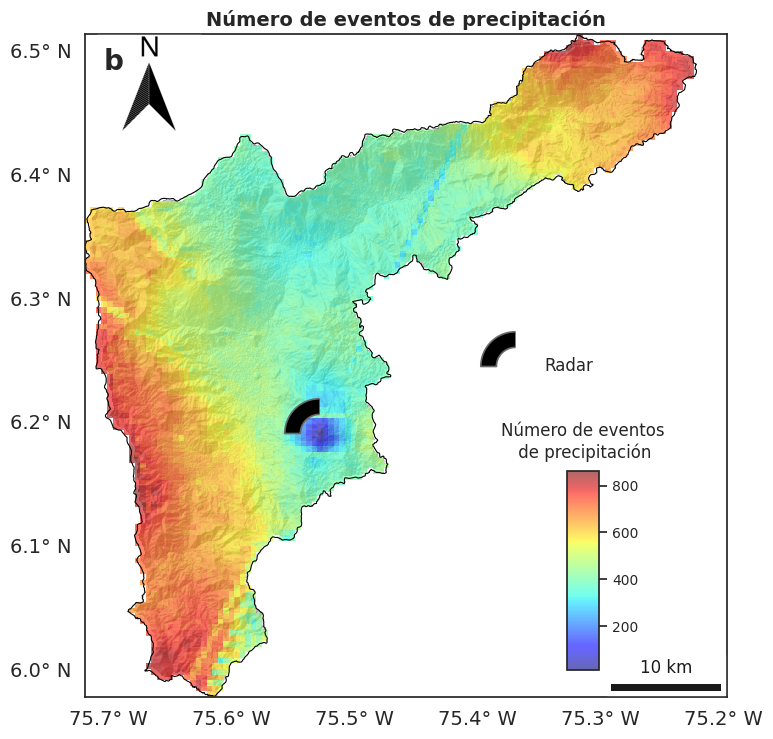

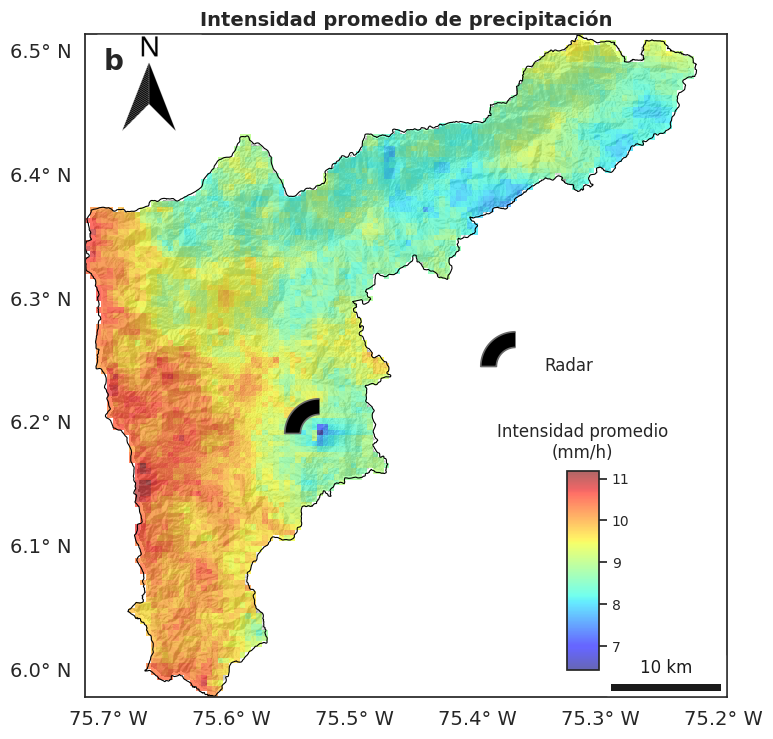

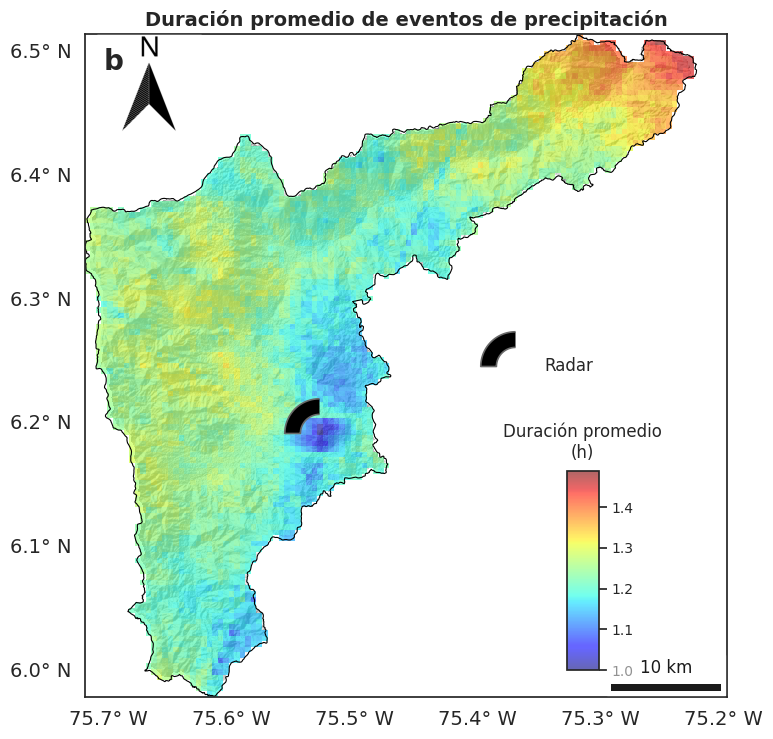

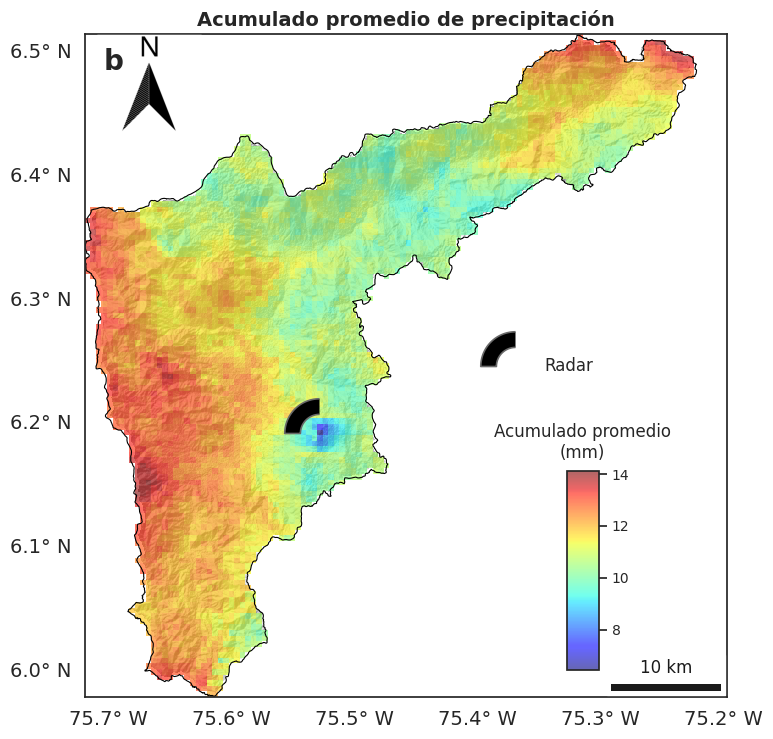

In [ ]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb, to_hex


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def _blend_hex(color_hex, factor=0.5, target='white'):
    """
    Mezcla un color con blanco o negro.
    factor en [0,1]: 0 = original, 1 = todo target.
    """
    c = np.array(to_rgb(color_hex))
    if target == 'white':
        t = np.array([1,1,1])
    else:
        t = np.array([0,0,0])
    out = c*(1-factor) + t*factor
    out = np.clip(out, 0, 1)
    return to_hex(out)

def lighten(color_hex, factor=0.35):
    return _blend_hex(color_hex, factor=factor, target='white')

def darken(color_hex, factor=0.35):
    return _blend_hex(color_hex, factor=factor, target='black')


# ====================== NUEVO: MAPA DE SLOPE UNITS ======================
def make_su_type_map(
    dem, geojson_path, slope_units_path, output_path, nombre_png,
    radar_csv_path, letter, desc_map, palette, min_deslizamientos=1
):
    """
    Mapa SOLO de Slope Units:
    - Color por tipo de SU (cluster4 → desc_map y palette).
    - Misma paleta con dos intensidades: oscuro (≥1 deslizamiento), claro (0 deslizamientos).
    """
    fig, ax = plt.subplots(figsize=(8, 9))

    # Polígono de recorte
    geojson = gpd.read_file(geojson_path)

    # Radar
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # Slope Units
    su_gdf = gpd.read_file(slope_units_path)
    if "cluster4" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'cluster4'.")
    if "n_mm" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")

    # CRS consistente y recorte
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")

    # Etiquetas y colores base
    valid = sorted(desc_map.keys())
    cat_order = [desc_map[i] for i in valid]
    pal_dict  = {desc_map[k]: col for k, col in zip(valid, palette)}

    su_gdf['Etiqueta'] = su_gdf['cluster4'].map(desc_map)
    su_gdf = su_gdf[su_gdf['Etiqueta'].isin(cat_order)].copy()
    su_gdf['Etiqueta'] = pd.Categorical(su_gdf['Etiqueta'], categories=cat_order, ordered=True)

    # Flag de deslizamientos
    su_gdf['has_mm'] = su_gdf['n_mm'].fillna(0).astype(float) >= min_deslizamientos

    # Color por SU: tono según tipo; oscuro si has_mm, claro si no
    def color_su(row):
        base = pal_dict[row['Etiqueta']]
        return darken(base, 0.35) if row['has_mm'] else lighten(base, 0.35)
    su_gdf['color_fill'] = su_gdf.apply(color_su, axis=1)

    # DEM + hillshade para contexto
    if dem.rio.crs != geojson.crs:
        poly_crs = geojson.to_crs(dem.rio.crs)
    else:
        poly_crs = geojson
    dem_recortado = dem.rio.clip(poly_crs.geometry, poly_crs.crs)

    sombra = hillshade(dem_recortado)
    # Extent en EPSG:4326 para colocar la imagen correctamente
    # Creamos una malla simple con bounds del geojson para mostrar la sombra
    b = geojson.total_bounds  # minx, miny, maxx, maxy
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower',
              extent=[b[0], b[2], b[1], b[3]], alpha=0.3)

    # SU pintadas
    su_gdf.plot(ax=ax, color=su_gdf['color_fill'], linewidth=0.25, zorder=3)

    # Límite
    geojson.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, zorder=4)

    # Radar (mismo símbolo)
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path); radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Ejes, formato, escala, norte
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    distance_meters = 111320
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5,
                        length_fraction=0.25, scale_loc="top", font_properties={'size': 12})
    ax.add_artist(scalebar)

    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Leyenda: categorías y clave de saturación
    # 1) Entradas por tipo (colores base)
    from matplotlib.patches import Patch
    cat_handles = [Patch(facecolor=pal_dict[lab], edgecolor='black', label=lab) for lab in cat_order]
    # 2) Clave de intensidad (oscuro/claro)
    key_handles = [
        Patch(facecolor=darken('#999999', 0.5), edgecolor='black', label='Oscuro: con ≥1 deslizamiento'),
        Patch(facecolor=lighten('#999999', 0.5), edgecolor='black', label='Claro: sin deslizamientos')
    ]
    handles = cat_handles + key_handles

    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(0.62, 0.50),
              fontsize=11, frameon=False, title="Tipos de SU / Presencia de MM")

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.set_title("Tipos de Slope Units y presencia de deslizamientos", fontsize=14, weight='bold')

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_slope_units.png', bbox_inches='tight', pad_inches=0.1, dpi=150)
    plt.show()
    plt.close()

# ====================== MODIFICADO: MAPA DE LLUVIA (SIN SU) ======================
def make_individual_event_map(
    dem, data, variable, nombre_variable, titulo,
    geojson_path, output_path, nombre_png,
    radar_csv_path,
    letter,
    slope_units_path,      # (ya no se usa para dibujar)
    min_deslizamientos,    # (ya no se usa para dibujar)
    cmap='jet'
):
    fig, ax = plt.subplots(figsize=(8, 9))

    # Límite
    geojson = gpd.read_file(geojson_path)

    # Radar
    radar_df  = pd.read_csv(radar_csv_path)
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # Ráster de lluvia y DEM
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)

    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    else:
        poligono = geojson
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    sombra = hillshade(dem_recortado)
    extent = [
        float(data_recortada['lon'].min().values),
        float(data_recortada['lon'].max().values),
        float(data_recortada['lat'].min().values),
        float(data_recortada['lat'].max().values)
    ]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # (Opcional) rangos
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35

    # Capa de calor
    pcm = ax.pcolormesh(
        data_recortada['lon'], data_recortada['lat'], data_recortada.T,
        cmap=cmap, shading='auto', alpha=0.6
        # , vmin=vmin, vmax=vmax
    )

    # Límite
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # Radar
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path); radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Ejes/escala/norte
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    distance_meters = 111320
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5,
                        length_fraction=0.25, scale_loc="top", font_properties={'size': 12})
    ax.add_artist(scalebar)

    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Barra de color (inset)
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3])
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Leyenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='center left',
              bbox_to_anchor=(0.62, 0.50), fontsize=12, frameon=False)

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.set_title(titulo, fontsize=14, weight='bold')

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()


#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis.shp')  # debe tener columna 'n_mm'

desc_map = {0:'SU 1', 1:'SU 2', 2:'SU 3', 3:'SU 4'}
palette  = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']  # orden 0,1,2,3

# 1) PRIMERO: mapa de Slope Units (tipo + intensidad por deslizamientos)
make_su_type_map(
    dem=dem,
    geojson_path=geojson_path,
    slope_units_path=slope_units_path,
    output_path=output_figures,
    nombre_png=name_png,
    radar_csv_path=radar,
    letter='a',
    desc_map=desc_map,
    palette=palette,
    min_deslizamientos=1
)

# # 2) DESPUÉS: mapas de lluvia (sin SU)
# for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
#     make_individual_event_map(
#         dem, interpolated_ds_0_15, variable, nombre_variable, titulo,
#         geojson_path, output_figures, name_png,
#         radar,
#         letter='b',  # o cambia letras como prefieras
#         slope_units_path=slope_units_path,       # ya no se dibujan
#         min_deslizamientos=1,                    # ya no se usa para dibujar
#         cmap='jet'
#     )


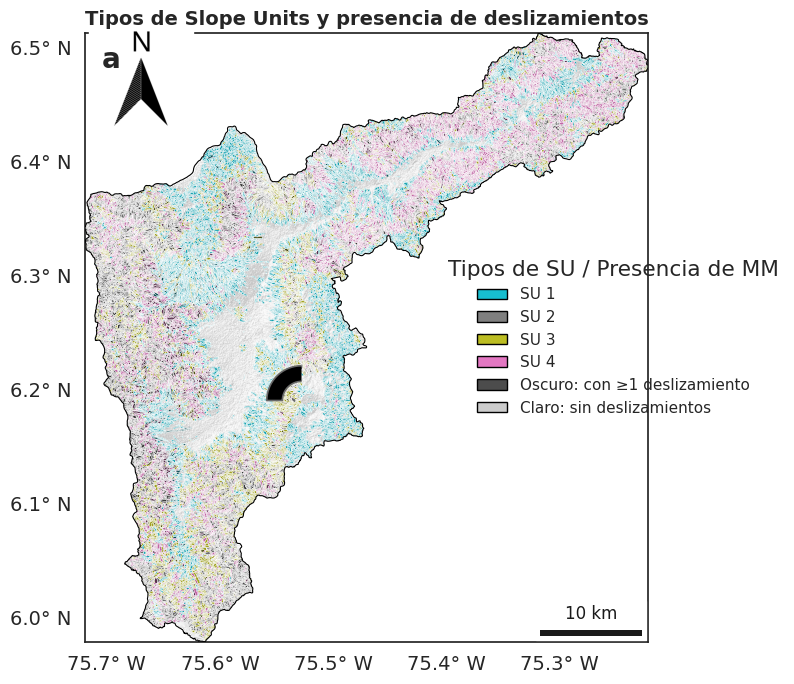

In [7]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb, to_hex


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def _blend_hex(color_hex, factor=0.5, target='white'):
    """
    Mezcla un color con blanco o negro.
    factor en [0,1]: 0 = original, 1 = todo target.
    """
    c = np.array(to_rgb(color_hex))
    if target == 'white':
        t = np.array([1,1,1])
    else:
        t = np.array([0,0,0])
    out = c*(1-factor) + t*factor
    out = np.clip(out, 0, 1)
    return to_hex(out)

def lighten(color_hex, factor=0.35):
    return _blend_hex(color_hex, factor=factor, target='white')

def darken(color_hex, factor=0.35):
    return _blend_hex(color_hex, factor=factor, target='black')


# ====================== NUEVO: MAPA DE SLOPE UNITS ======================
def make_su_type_map(
    dem, geojson_path, slope_units_path, output_path, nombre_png,
    radar_csv_path, letter, desc_map, palette, min_deslizamientos=1
):
    """
    Mapa SOLO de Slope Units:
    - Color por tipo de SU (cluster4 → desc_map y palette).
    - Misma paleta con dos intensidades: oscuro (≥1 deslizamiento), claro (0 deslizamientos).
    """
    fig, ax = plt.subplots(figsize=(8, 9))

    # Polígono de recorte
    geojson = gpd.read_file(geojson_path)

    # Radar
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # Slope Units
    su_gdf = gpd.read_file(slope_units_path)
    if "cluster4" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'cluster4'.")
    if "n_mm" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")

    # CRS consistente y recorte
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")

    # Etiquetas y colores base
    valid = sorted(desc_map.keys())
    cat_order = [desc_map[i] for i in valid]
    pal_dict  = {desc_map[k]: col for k, col in zip(valid, palette)}

    su_gdf['Etiqueta'] = su_gdf['cluster4'].map(desc_map)
    su_gdf = su_gdf[su_gdf['Etiqueta'].isin(cat_order)].copy()
    su_gdf['Etiqueta'] = pd.Categorical(su_gdf['Etiqueta'], categories=cat_order, ordered=True)

    # Flag de deslizamientos
    su_gdf['has_mm'] = su_gdf['n_mm'].fillna(0).astype(float) >= min_deslizamientos

    # Color por SU: tono según tipo; oscuro si has_mm, claro si no
# --- reemplaza tu función color_su por esta ---
    def color_su(row, factor_claro=0.15, factor_oscuro=0.60):
        base = pal_dict[row['Etiqueta']]
        # Sin MM: un poco más oscuro que el color base
        if not row['has_mm']:
            return darken(base, factor=factor_claro)
        # Con MM: bastante más oscuro
        else:
            return darken(base, factor=factor_oscuro)

    su_gdf['color_fill'] = su_gdf.apply(color_su, axis=1)

    # DEM + hillshade para contexto
    if dem.rio.crs != geojson.crs:
        poly_crs = geojson.to_crs(dem.rio.crs)
    else:
        poly_crs = geojson
    dem_recortado = dem.rio.clip(poly_crs.geometry, poly_crs.crs)

    sombra = hillshade(dem_recortado)
    # Extent en EPSG:4326 para colocar la imagen correctamente
    # Creamos una malla simple con bounds del geojson para mostrar la sombra
    b = geojson.total_bounds  # minx, miny, maxx, maxy
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower',
              extent=[b[0], b[2], b[1], b[3]], alpha=0.3)

    # SU pintadas
    su_gdf.plot(ax=ax, color=su_gdf['color_fill'], linewidth=0.25, zorder=3)

    # Límite
    geojson.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, zorder=4)

    # Radar (mismo símbolo)
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path); radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Ejes, formato, escala, norte
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    distance_meters = 111320
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5,
                        length_fraction=0.25, scale_loc="top", font_properties={'size': 12})
    ax.add_artist(scalebar)

    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Leyenda: categorías y clave de saturación
    # 1) Entradas por tipo (colores base)
    from matplotlib.patches import Patch
    cat_handles = [Patch(facecolor=pal_dict[lab], edgecolor='black', label=lab) for lab in cat_order]
    # 2) Clave de intensidad (oscuro/claro)
    key_handles = [
        Patch(facecolor=darken('#999999', 0.5), edgecolor='black', label='Oscuro: con ≥1 deslizamiento'),
        Patch(facecolor=lighten('#999999', 0.5), edgecolor='black', label='Claro: sin deslizamientos')
    ]
    handles = cat_handles + key_handles

    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(0.62, 0.50),
              fontsize=11, frameon=False, title="Tipos de SU / Presencia de MM")

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.set_title("Tipos de Slope Units y presencia de deslizamientos", fontsize=14, weight='bold')

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_slope_units.png', bbox_inches='tight', pad_inches=0.1, dpi=150)
    plt.show()
    plt.close()



#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis.shp')  # debe tener columna 'n_mm'

desc_map = {0:'SU 1', 1:'SU 2', 2:'SU 3', 3:'SU 4'}
palette  = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']  # orden 0,1,2,3

# 1) PRIMERO: mapa de Slope Units (tipo + intensidad por deslizamientos)
make_su_type_map(
    dem=dem,
    geojson_path=geojson_path,
    slope_units_path=slope_units_path,
    output_path=output_figures,
    nombre_png=name_png,
    radar_csv_path=radar,
    letter='a',
    desc_map=desc_map,
    palette=palette,
    min_deslizamientos=1
)

In [ ]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb, to_hex


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def _blend_hex(color_hex, factor=0.5, target='white'):
    """
    Mezcla un color con blanco o negro.
    factor en [0,1]: 0 = original, 1 = todo target.
    """
    c = np.array(to_rgb(color_hex))
    if target == 'white':
        t = np.array([1,1,1])
    else:
        t = np.array([0,0,0])
    out = c*(1-factor) + t*factor
    out = np.clip(out, 0, 1)
    return to_hex(out)

def lighten(color_hex, factor=0.35):
    return _blend_hex(color_hex, factor=factor, target='white')

def darken(color_hex, factor=0.35):
    return _blend_hex(color_hex, factor=factor, target='black')


# ====================== NUEVO: MAPA DE SLOPE UNITS ======================
def make_su_type_map(
    dem, geojson_path, slope_units_path, output_path, nombre_png,
    radar_csv_path, letter, desc_map, palette, min_deslizamientos=1
):
    """
    Mapa SOLO de Slope Units:
    - Color por tipo de SU (cluster4 → desc_map y palette).
    - Misma paleta con dos intensidades: oscuro (≥1 deslizamiento), claro (0 deslizamientos).
    """
    fig, ax = plt.subplots(figsize=(8, 9))

    # Polígono de recorte
    geojson = gpd.read_file(geojson_path)

    # Radar
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # Slope Units
    su_gdf = gpd.read_file(slope_units_path)
    if "cluster4" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'cluster4'.")
    if "n_mm" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")

    # CRS consistente y recorte
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")

    # Etiquetas y colores base
    valid = sorted(desc_map.keys())
    cat_order = [desc_map[i] for i in valid]
    pal_dict  = {desc_map[k]: col for k, col in zip(valid, palette)}

    su_gdf['Etiqueta'] = su_gdf['cluster4'].map(desc_map)
    su_gdf = su_gdf[su_gdf['Etiqueta'].isin(cat_order)].copy()
    su_gdf['Etiqueta'] = pd.Categorical(su_gdf['Etiqueta'], categories=cat_order, ordered=True)

    # Flag de deslizamientos
    su_gdf['has_mm'] = su_gdf['n_mm'].fillna(0).astype(float) >= min_deslizamientos

    # Color por SU: tono según tipo; oscuro si has_mm, claro si no
    def color_su(row):
        base = pal_dict[row['Etiqueta']]
        return darken(base, 0.35) if row['has_mm'] else lighten(base, 0.35)
    su_gdf['color_fill'] = su_gdf.apply(color_su, axis=1)

    # DEM + hillshade para contexto
    if dem.rio.crs != geojson.crs:
        poly_crs = geojson.to_crs(dem.rio.crs)
    else:
        poly_crs = geojson
    dem_recortado = dem.rio.clip(poly_crs.geometry, poly_crs.crs)

    sombra = hillshade(dem_recortado)
    # Extent en EPSG:4326 para colocar la imagen correctamente
    # Creamos una malla simple con bounds del geojson para mostrar la sombra
    b = geojson.total_bounds  # minx, miny, maxx, maxy
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower',
              extent=[b[0], b[2], b[1], b[3]], alpha=0.3)

    # SU pintadas
    su_gdf.plot(ax=ax, color=su_gdf['color_fill'], linewidth=0.25, zorder=3)

    # Límite
    geojson.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, zorder=4)

    # Radar (mismo símbolo)
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path); radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Ejes, formato, escala, norte
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    distance_meters = 111320
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5,
                        length_fraction=0.25, scale_loc="top", font_properties={'size': 12})
    ax.add_artist(scalebar)

    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Leyenda: categorías y clave de saturación
    # 1) Entradas por tipo (colores base)
    from matplotlib.patches import Patch
    cat_handles = [Patch(facecolor=pal_dict[lab], edgecolor='black', label=lab) for lab in cat_order]
    # 2) Clave de intensidad (oscuro/claro)
    key_handles = [
        Patch(facecolor=darken('#999999', 0.5), edgecolor='black', label='Oscuro: con ≥1 deslizamiento'),
        Patch(facecolor=lighten('#999999', 0.5), edgecolor='black', label='Claro: sin deslizamientos')
    ]
    handles = cat_handles + key_handles

    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(0.62, 0.50),
              fontsize=11, frameon=False, title="Tipos de SU / Presencia de MM")

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.set_title("Tipos de Slope Units y presencia de deslizamientos", fontsize=14, weight='bold')

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_slope_units.png', bbox_inches='tight', pad_inches=0.1, dpi=150)
    plt.show()
    plt.close()




#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis.shp')  # debe tener columna 'n_mm'

desc_map = {0:'SU 1', 1:'SU 2', 2:'SU 3', 3:'SU 4'}
palette  = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']  # orden 0,1,2,3

# 1) PRIMERO: mapa de Slope Units (tipo + intensidad por deslizamientos)
make_su_type_map(
    dem=dem,
    geojson_path=geojson_path,
    slope_units_path=slope_units_path,
    output_path=output_figures,
    nombre_png=name_png,
    radar_csv_path=radar,
    letter='a',
    desc_map=desc_map,
    palette=palette,
    min_deslizamientos=1
)

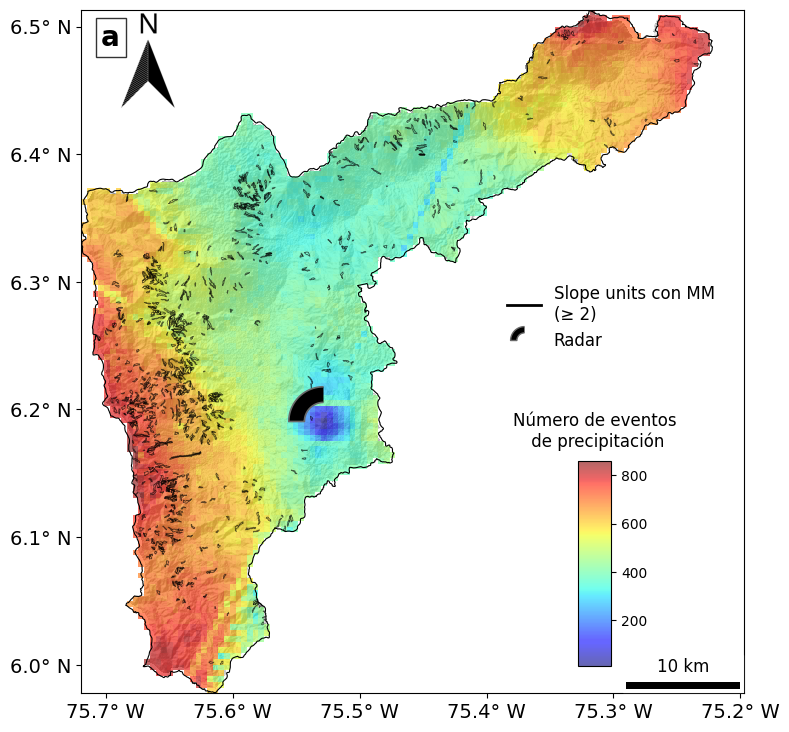

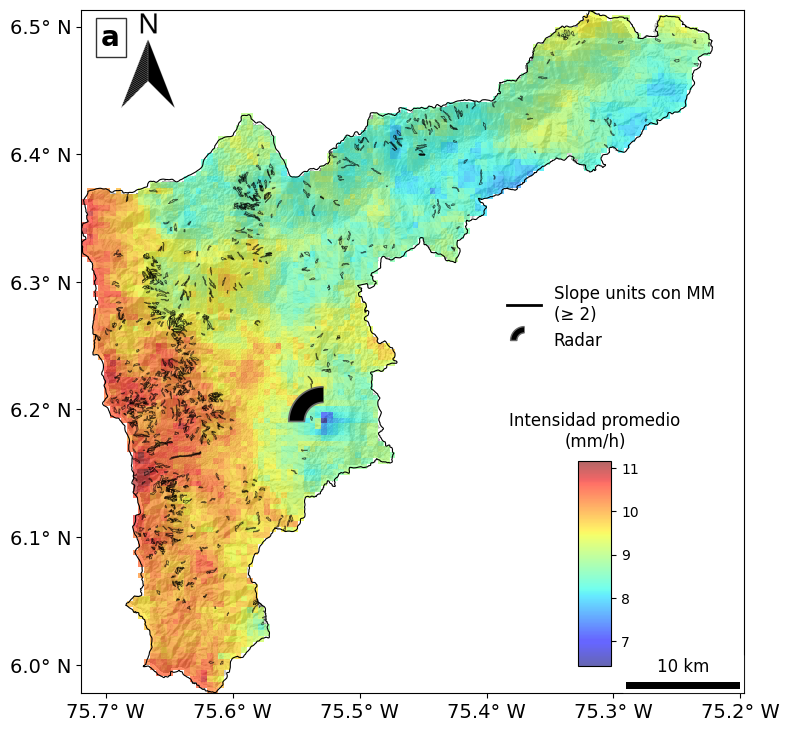

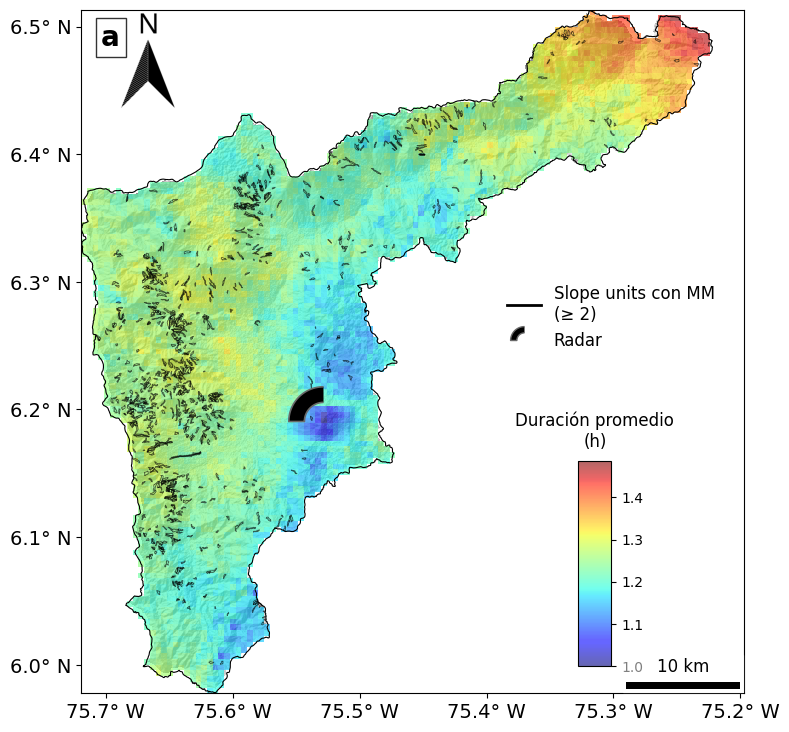

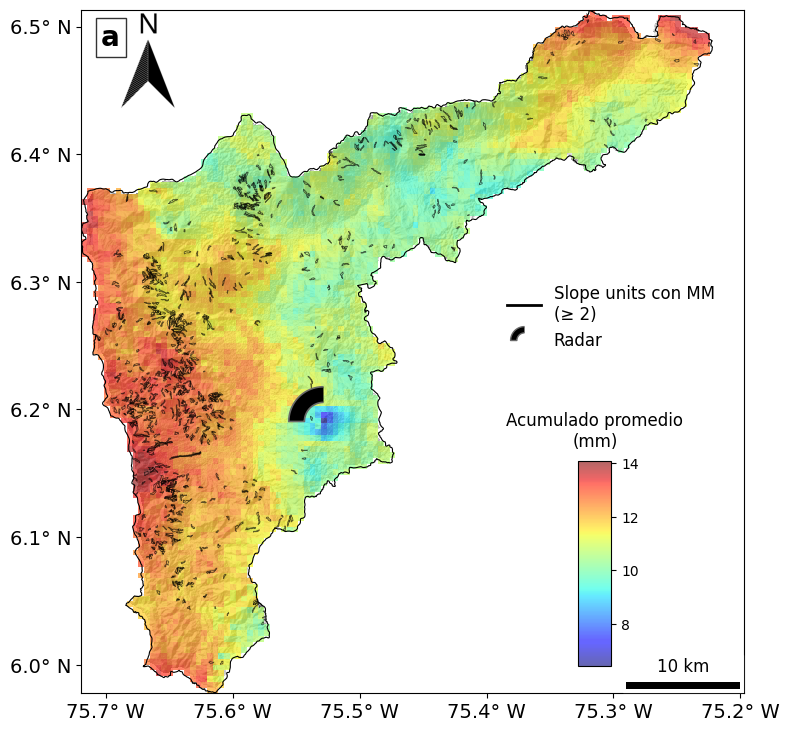

In [ ]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def make_individual_event_map(
    dem, data, variable, nombre_variable, titulo,
    geojson_path, output_path, nombre_png,
    radar_csv_path,
    letter,
    slope_units_path,                   # NUEVO: ruta a slope units
    min_deslizamientos,              # NUEVO: umbral de n_mm
    cmap='jet'
):
    fig, ax = plt.subplots(figsize=(8, 9))

    # ────────── polígonos de recorte (AMVA) ──────────
    geojson = gpd.read_file(geojson_path)

    # ────────── radar (icono y ubicación) ──────────
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # ────────── slope units (filtrado n_mm ≥ 1) ──────────
    su_gdf = gpd.read_file(slope_units_path)                               # NUEVO
    # Asegurar que existe la columna
    if "n_mm" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")

    su_gdf = su_gdf[su_gdf["n_mm"].fillna(0) >= min_deslizamientos]        # NUEVO: filtro
    # Reproyectar al CRS del geojson
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)

    # Recortar slope units por el polígono de estudio
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")              # NUEVO (alternativa: gpd.clip)

    # ────────── datos ráster y DEM ──────────
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)

    # Clip DEM asegurando que 'poligono' siempre exista
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    else:
        poligono = geojson
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Sombreado del relieve
    sombra = hillshade(dem_recortado)
    extent = [
        float(data_recortada['lon'].min().values),
        float(data_recortada['lon'].max().values),
        float(data_recortada['lat'].min().values),
        float(data_recortada['lat'].max().values)
    ]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # Rango sugerido (opcional)
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35

    # Capa de calor
    pcm = ax.pcolormesh(
        data_recortada['lon'], data_recortada['lat'], data_recortada.T,
        cmap=cmap, shading='auto', alpha=0.6
        # , vmin=vmin, vmax=vmax  # activa si quieres forzar escala fija
    )

    # Contorno del límite
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # ────────── DIBUJAR SLOPE UNITS FILTRADAS ──────────
    # Estilo: contorno rojo y relleno semitransparente
    su_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.6, alpha=0.6, zorder=4)  # NUEVO
    # Si prefieres relleno: usa facecolor='crimson', alpha=0.25

    # Icono/posición del radar
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path)
    radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Formato ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Escala gráfica
    distance_meters = 111320
    scalebar = ScaleBar(
        distance_meters, location="lower right", box_alpha=0.5,
        length_fraction=0.25, scale_loc="top", font_properties={'size': 12}
    )
    ax.add_artist(scalebar)

    # Norte
    
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Barra de color en un “inset”
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3])  # [x, y, width, height] en coordenadas del eje
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Leyenda (reemplazamos entradas)
    handles, labels = ax.get_legend_handles_labels()

    # Handle para slope units (cuadro rojo)
    handle_su = Line2D([], [], linestyle='-', color='black', linewidth=2,
                       label=f"Slope units con MM\n(≥ {min_deslizamientos})")  # NUEVO

    handle_radar = Line2D([], [], marker=radar_ms, linestyle='None',
                          markerfacecolor='black', markeredgecolor='dimgray',
                          markersize=20, label='Radar')

    # Construir nueva leyenda sin duplicados
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in ('Radar',):
            new_handles.append(h); new_labels.append(lab)
    new_handles.extend([handle_su, handle_radar])
    new_labels.extend([f"Slope units con MM\n(≥ {min_deslizamientos})", 'Radar'])

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.legend(new_handles, new_labels, loc='center left',
              bbox_to_anchor=(0.62, 0.50), fontsize=12, frameon=False)

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()


#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis.shp')  # debe tener columna 'n_mm'

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(
        dem, interpolated_ds_0_15, variable, nombre_variable, titulo,
        geojson_path, output_figures, name_png,
        radar,
        letter,
        slope_units_path=slope_units_path,       # NUEVO
        min_deslizamientos=2,                    # NUEVO: n_mm ≥ 1
        cmap='jet'
    )


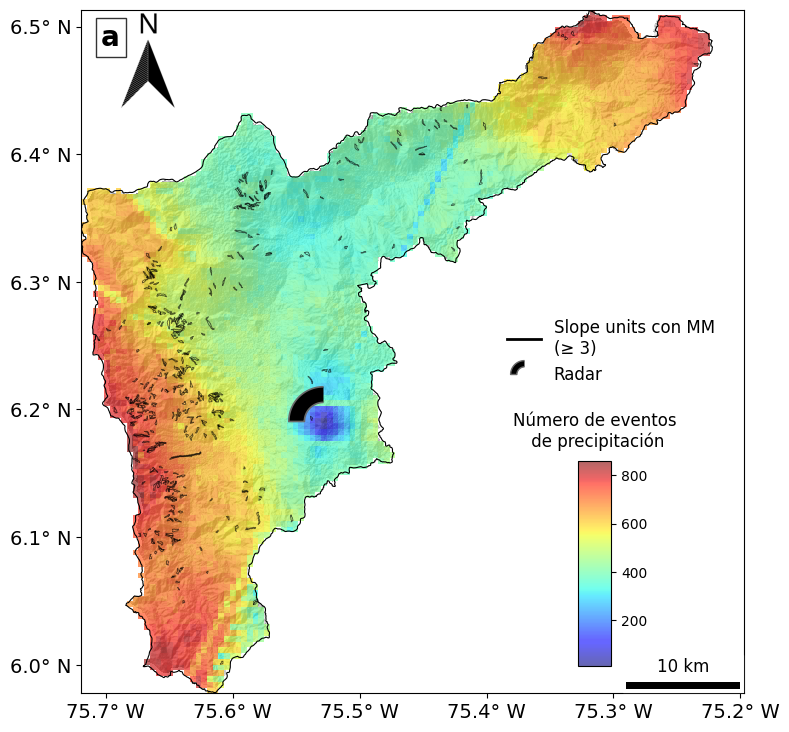

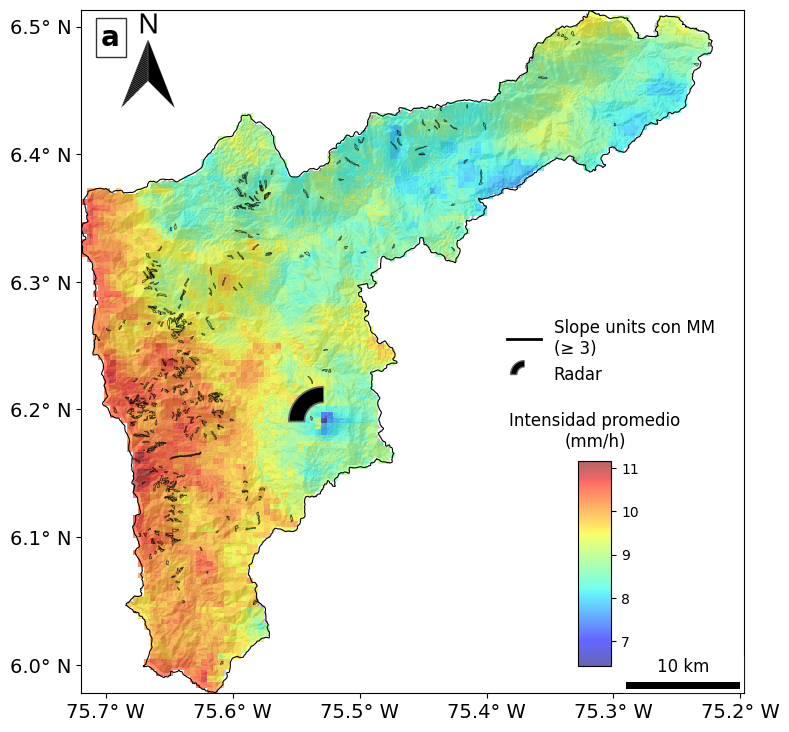

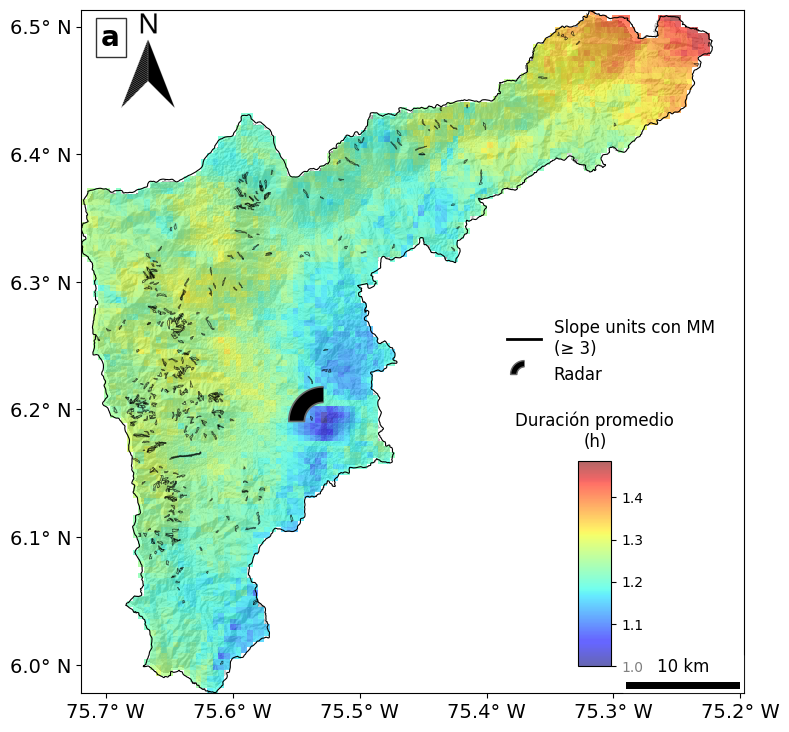

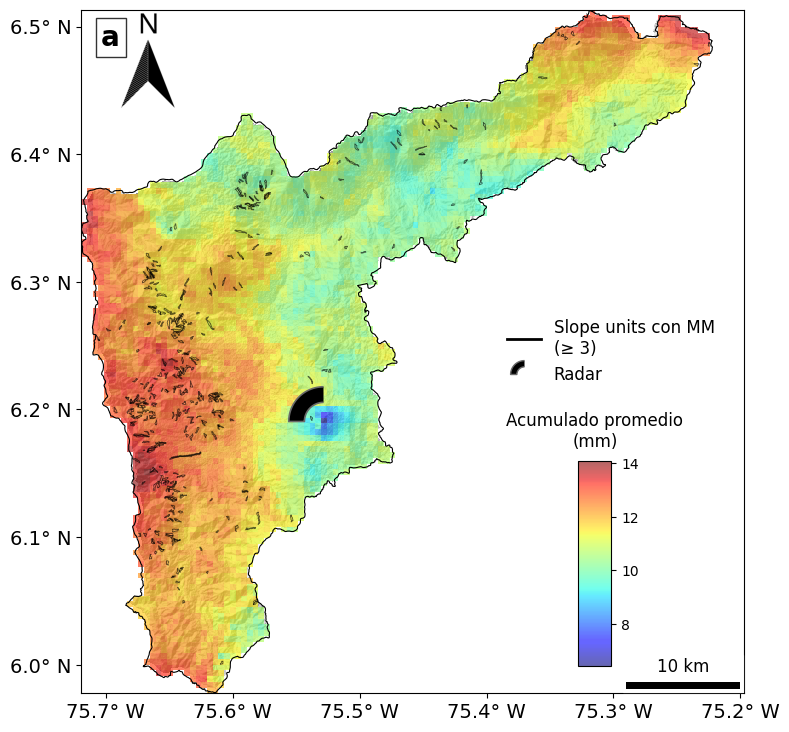

In [5]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def make_individual_event_map(
    dem, data, variable, nombre_variable, titulo,
    geojson_path, output_path, nombre_png,
    radar_csv_path,
    letter,
    slope_units_path,                   # NUEVO: ruta a slope units
    min_deslizamientos,              # NUEVO: umbral de n_mm
    cmap='jet'
):
    fig, ax = plt.subplots(figsize=(8, 9))

    # ────────── polígonos de recorte (AMVA) ──────────
    geojson = gpd.read_file(geojson_path)

    # ────────── radar (icono y ubicación) ──────────
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # ────────── slope units (filtrado n_mm ≥ 1) ──────────
    su_gdf = gpd.read_file(slope_units_path)                               # NUEVO
    # Asegurar que existe la columna
    if "n_mm" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")

    su_gdf = su_gdf[su_gdf["n_mm"].fillna(0) >= min_deslizamientos]        # NUEVO: filtro
    # Reproyectar al CRS del geojson
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)

    # Recortar slope units por el polígono de estudio
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")              # NUEVO (alternativa: gpd.clip)

    # ────────── datos ráster y DEM ──────────
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)

    # Clip DEM asegurando que 'poligono' siempre exista
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    else:
        poligono = geojson
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Sombreado del relieve
    sombra = hillshade(dem_recortado)
    extent = [
        float(data_recortada['lon'].min().values),
        float(data_recortada['lon'].max().values),
        float(data_recortada['lat'].min().values),
        float(data_recortada['lat'].max().values)
    ]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # Rango sugerido (opcional)
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35

    # Capa de calor
    pcm = ax.pcolormesh(
        data_recortada['lon'], data_recortada['lat'], data_recortada.T,
        cmap=cmap, shading='auto', alpha=0.6
        # , vmin=vmin, vmax=vmax  # activa si quieres forzar escala fija
    )

    # Contorno del límite
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # ────────── DIBUJAR SLOPE UNITS FILTRADAS ──────────
    # Estilo: contorno rojo y relleno semitransparente
    su_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.6, alpha=0.6, zorder=4)  # NUEVO
    # Si prefieres relleno: usa facecolor='crimson', alpha=0.25

    # Icono/posición del radar
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path)
    radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Formato ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Escala gráfica
    distance_meters = 111320
    scalebar = ScaleBar(
        distance_meters, location="lower right", box_alpha=0.5,
        length_fraction=0.25, scale_loc="top", font_properties={'size': 12}
    )
    ax.add_artist(scalebar)

    # Norte
    
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Barra de color en un “inset”
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3])  # [x, y, width, height] en coordenadas del eje
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Leyenda (reemplazamos entradas)
    handles, labels = ax.get_legend_handles_labels()

    # Handle para slope units (cuadro rojo)
    handle_su = Line2D([], [], linestyle='-', color='black', linewidth=2,
                       label=f"Slope units con MM\n(≥ {min_deslizamientos})")  # NUEVO

    handle_radar = Line2D([], [], marker=radar_ms, linestyle='None',
                          markerfacecolor='black', markeredgecolor='dimgray',
                          markersize=20, label='Radar')

    # Construir nueva leyenda sin duplicados
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in ('Radar',):
            new_handles.append(h); new_labels.append(lab)
    new_handles.extend([handle_su, handle_radar])
    new_labels.extend([f"Slope units con MM\n(≥ {min_deslizamientos})", 'Radar'])

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.legend(new_handles, new_labels, loc='center left',
              bbox_to_anchor=(0.62, 0.50), fontsize=12, frameon=False)

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()


#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis.shp')  # debe tener columna 'n_mm'

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(
        dem, interpolated_ds_0_15, variable, nombre_variable, titulo,
        geojson_path, output_figures, name_png,
        radar,
        letter,
        slope_units_path=slope_units_path,       # NUEVO
        min_deslizamientos=3,                    # NUEVO: n_mm ≥ 1
        cmap='jet'
    )


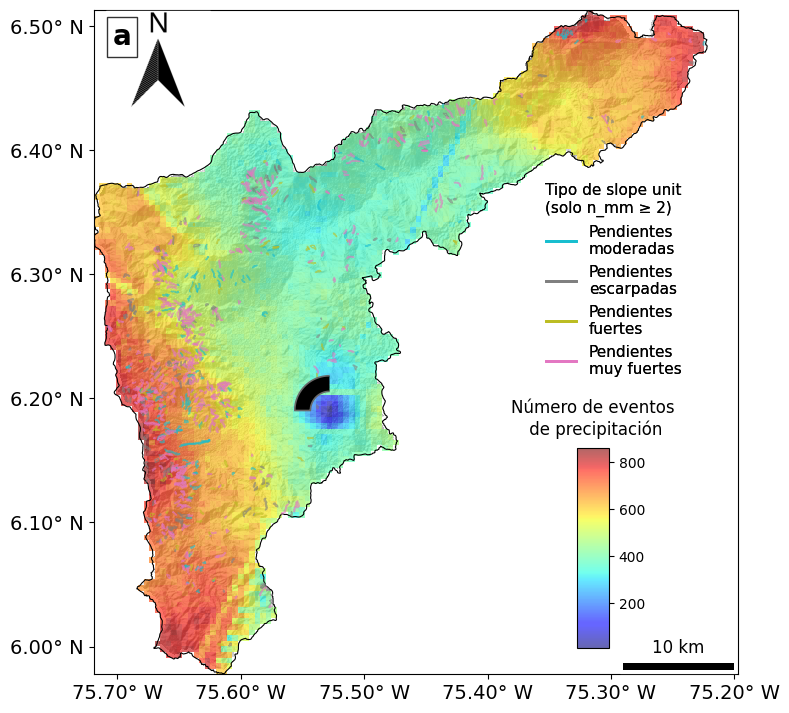

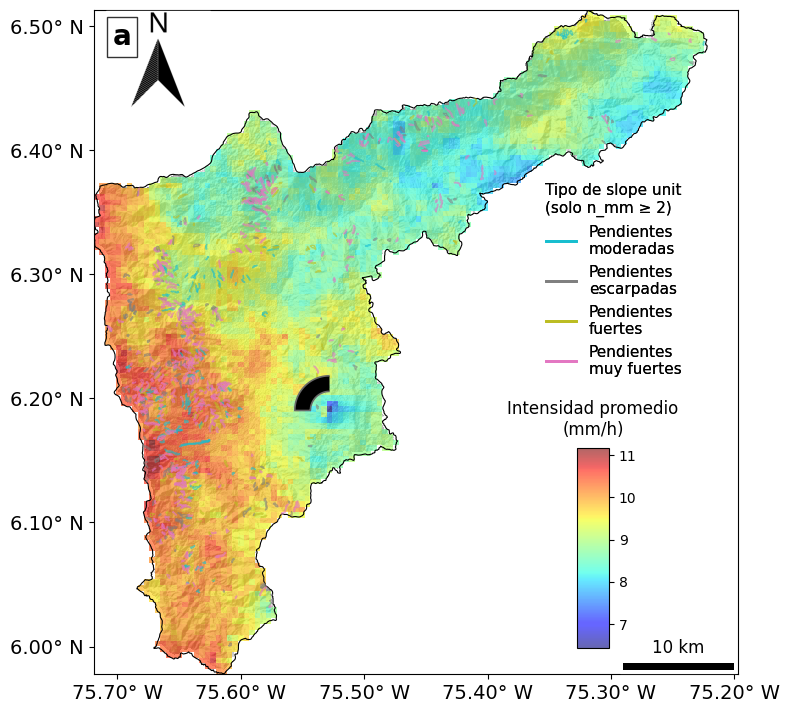

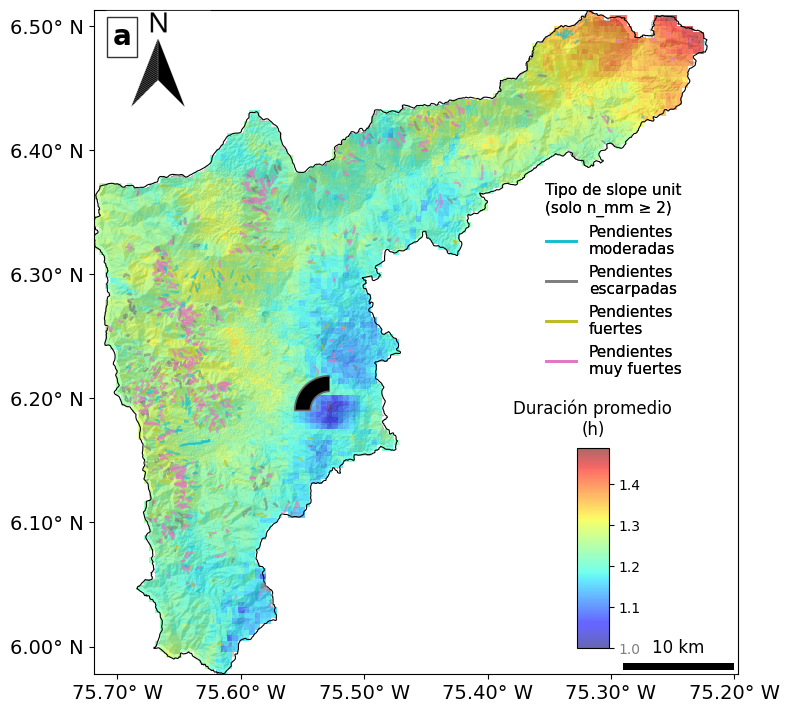

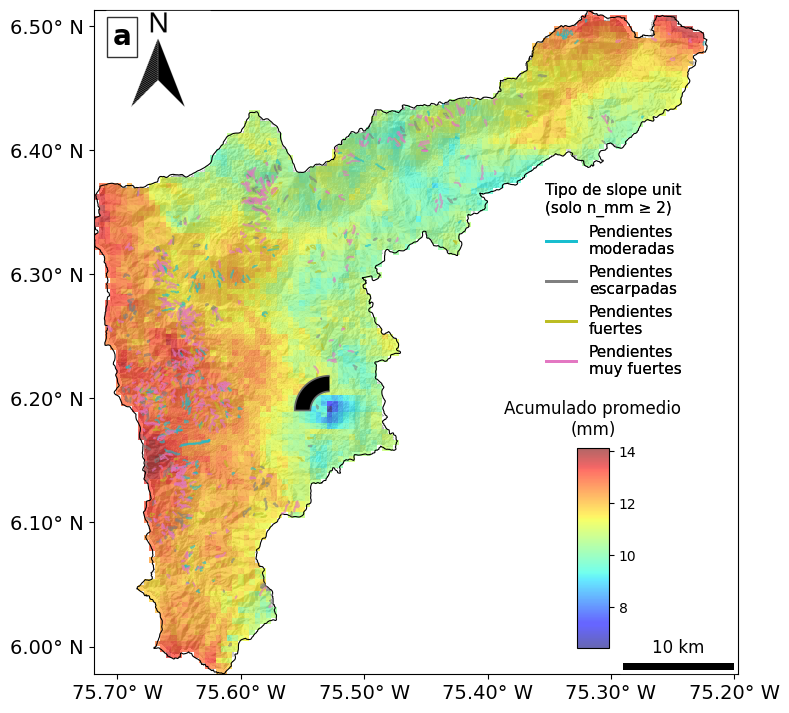

In [2]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

desc_map = {
    0: 'Pendientes\nmoderadas',
    1: 'Pendientes\nescarpadas',
    2: 'Pendientes\nfuertes',
    3: 'Pendientes\nmuy fuertes'
}
palette = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']  # 0,1,2,3
colors_by_cluster = {k: palette[k] for k in desc_map.keys()}

def find_cluster_column(df):
    """
    Devuelve el nombre real de la columna de clúster aunque venga como
    'cluster 4', 'cluster4' o 'cluster_4'. Lanza error si no la encuentra.
    """
    normalized = {c: c.strip().lower().replace(' ', '').replace('-', '').replace('_','')
                  for c in df.columns}
    for raw, norm in normalized.items():
        if norm == 'cluster4':
            return raw
    raise ValueError("No se encontró la columna de clúster (espere algo como 'cluster 4' / 'cluster4').")

def make_individual_event_map(
    dem, data, variable, nombre_variable, titulo,
    geojson_path, output_path, nombre_png,
    radar_csv_path,
    letter,
    slope_units_path,                   # ruta a slope units
    cmap='jet'
):
    fig, ax = plt.subplots(figsize=(8, 9))

    # ────────── polígono de estudio ──────────
    geojson = gpd.read_file(geojson_path)

    # ────────── radar (icono) ──────────
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # ────────── slope units (SOLO n_mm ≥ 2) ──────────
    su_gdf = gpd.read_file(slope_units_path)
    if "n_mm" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")
    cluster_col = find_cluster_column(su_gdf)

    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)

    # Recorte al AMVA (más eficiente con clip)
    su_gdf = gpd.clip(su_gdf, geojson)

    # Filtro definitivo: SOLO n_mm ≥ 2
    su_sel = su_gdf[su_gdf["n_mm"].fillna(0) >= 2]

    # ────────── ráster radar y DEM ──────────
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)

    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    else:
        poligono = geojson
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Hillshade
    sombra = hillshade(dem_recortado)
    extent = [
        float(data_recortada['lon'].min().values),
        float(data_recortada['lon'].max().values),
        float(data_recortada['lat'].min().values),
        float(data_recortada['lat'].max().values)
    ]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # Capa de calor
    pcm = ax.pcolormesh(
        data_recortada['lon'], data_recortada['lat'], data_recortada.T,
        cmap=cmap, shading='auto', alpha=0.6
    )

    # Contorno del límite
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # ────────── DIBUJO: SOLO n_mm ≥ 2 POR CLÚSTER (color de borde) ──────────
    for cl in sorted(colors_by_cluster.keys()):
        col = colors_by_cluster[cl]
        g = su_sel[su_sel[cluster_col] == cl]
        if len(g) > 0:
            g.plot(ax=ax, facecolor='none', edgecolor=col, linewidth=0.9, alpha=0.6, zorder=5)

    # Icono/posición del radar
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path)
    radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=6
    )

    # Ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Escala
    scalebar = ScaleBar(111320, location="lower right", box_alpha=0.5,
                        length_fraction=0.25, scale_loc="top",
                        font_properties={'size': 12})
    ax.add_artist(scalebar)

    # Norte
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Barra de color
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3])  # [x, y, width, height] en coords del eje
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # ────────── LEYENDAS ──────────
    # Leyenda de tipos (colores por cluster) — indicamos el filtro en el título
    cluster_handles = [
        Line2D([], [], linestyle='-', color=colors_by_cluster[i], linewidth=2, label=desc_map[i])
        for i in sorted(desc_map.keys())
    ]
    leg1 = ax.legend(cluster_handles, [desc_map[i] for i in sorted(desc_map.keys())],
                     title="Tipo de slope unit\n(solo n_mm ≥ 2)", loc='upper left',
                     bbox_to_anchor=(0.68, 0.76), frameon=False, fontsize=11, title_fontsize=11)
    ax.add_artist(leg1)

    # Segunda leyenda (solo Radar)
    # ax.legend([Line2D([], [], marker=radar_ms, linestyle='None',
    #                   markerfacecolor='black', markeredgecolor='dimgray', markersize=14)],
    #           ["Radar"], loc='center left', bbox_to_anchor=(0.62, 0.50),
    #           frameon=False, fontsize=12)

    # Letra del panel
    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=120)
    plt.show()
    plt.close()

#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

# Rutas base
radar_events     = '../../DATA/rainfall/radar/'
output_figures   = '../../FIGURES/spatial_analysis/radar/'

# Variables a mapear
variables      = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación',
                  'Intensidad promedio\n(mm/h)',
                  'Duración promedio\n(h)',
                  'Acumulado promedio\n(mm)']
titles         = ['Número de eventos de precipitación',
                  'Intensidad promedio de precipitación',
                  'Duración promedio de eventos de precipitación',
                  'Acumulado promedio de precipitación']

# Insumos espaciales
dem_path    = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'
dem         = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

# NetCDF y máscara de coordenadas a excluir
coord_file  = f'{radar_events}coordenadas_que_no.csv'
file_nc     = 'eventos_lluvia_5mm_1horas_2.nc'
ds_interp   = filter_and_interpolate_data(f'{radar_events}{file_nc}', coord_file)
name_png    = file_nc.split('.')[0]

# Posición del radar (CSV con columnas: latitud, longitud)
radar_csv = '../../DATA/coords_radar.csv'

# Slope units (debe contener columnas: 'n_mm' y 'cluster 4' / 'cluster4' / 'cluster_4')
dir_data          = '../../DATA/shape_files/'
slope_units_path  = os.path.join(dir_data, 'slope_units_analisis.shp')

# Letra de panel (si haces figuras compuestas)
letter = 'a'

# Generar mapas
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(
        dem=dem,
        data=ds_interp,
        variable=variable,
        nombre_variable=nombre_variable,
        titulo=titulo,
        geojson_path=geojson_path,
        output_path=output_figures,
        nombre_png=name_png,
        radar_csv_path=radar_csv,
        letter=letter,
        slope_units_path=slope_units_path,  # Solo se graficarán n_mm ≥ 2 dentro de la función
        cmap='jet'
    )





### **ANÁLISIS CON EL INVENTARIO DE GEOHAZARDS**

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

dir_data   = '../../DATA/shape_files/'
# Cargar capas (asegúrate de ajustar las rutas)
clusters = gpd.read_file(os.path.join(dir_data, 'clusters.shp')).to_crs(epsg=32618)               # polígonos de zonas (1–5)
su       = gpd.read_file(os.path.join(dir_data, 'detallado_clasificado_proto.shp')).to_crs(epsg=32618)  # slope units con columna ‘cluster4’
slides   = gpd.read_file(os.path.join(dir_data, 'sensores_remotos_amva.geojson')).to_crs(epsg=32618)   # puntos de deslizamientos


#1. Asignar a cada slope unit su “zona” dominante

su['su_idx'] = su.index                      # identificador temporal
# 2.1 Intersección
piezas = gpd.overlay(
    su[['su_idx','geometry']],
    clusters[['Cluster','geometry']],
    how='intersection'
)
piezas['area_int'] = piezas.geometry.area    # área de intersección
# 2.2 Zona dominante por área
idx_max = piezas.groupby('su_idx')['area_int'].idxmax()
dom     = piezas.loc[idx_max, ['su_idx','Cluster']].rename(columns={'Cluster':'zona'})
# 2.3 Unir al GeoDataFrame original
su = su.merge(dom, on='su_idx', how='left')


#guardar su
#su.to_file(os.path.join(dir_data, 'slope_units_zonas.geojson'), driver='GeoJSON')
#2. Contar deslizamientos dentro de cada slope unit
join = gpd.sjoin(
    slides[['geometry']],
    su[['su_idx','geometry']],
    how='left',
    predicate='within'
)
counts = join.groupby('su_idx').size().rename('n_mm')
su = su.merge(counts, on='su_idx', how='left')
su['n_mm'] = su['n_mm'].fillna(0).astype(int)
su['si_no'] = (su['n_mm'] > 0).astype(int)

#guardar slope units con conteo de deslizamientos
su.to_file(os.path.join(dir_data,'slope_units_analisis.shp'))

In [ ]:
dir_data   = '../../DATA/landslides/Geohazard_RS.gpkg'
slides   = gpd.read_file(os.path.join(dir_data, 'landslides/Geohazard_RS.gpkg')).to_crs(epsg=32618)   # puntos de deslizamientos

In [21]:
slides

,Tipo,Fecha,geometry
0,Landslide,2001-09-22,POINT Z (440472.244 676610.001 0.000)
1,Debris Flow,2000-10-01,POINT Z (432069.036 682035.918 0.000)
2,Debris Flow,2001-10-14,POINT Z (431515.574 681815.459 0.000)
3,Landslide,2002-06-04,POINT Z (431515.574 681815.459 0.000)
4,Debris Flow,2003-09-24,POINT Z (431515.574 681815.459 0.000)
...,...,...,...
2763,None,None,POINT Z (435262.928 702365.532 0.000)
2764,None,None,POINT Z (435398.004 702348.864 0.000)
2765,None,None,POINT Z (434107.566 702896.772 0.000)
2766,None,None,POINT Z (433927.219 698671.954 0.000)


In [22]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import shapely.wkb as wkb
import fiona
import os

dir_data = '../../DATA/shape_files/'

# 1) Cargar polígonos de zonas y slope units en EPSG:32618
clusters = gpd.read_file(os.path.join(dir_data, 'clusters.shp')).to_crs(epsg=32618)               # polígonos de zonas (1–5)
su       = gpd.read_file(os.path.join(dir_data, 'detallado_clasificado_proto.shp')).to_crs(epsg=32618)  # slope units (tienen 'cluster4' y geometry)
su['su_idx'] = su.index  # identificador temporal de cada slope unit

# 2) Zona dominante por intersección (como ya hacías)
piezas = gpd.overlay(
    su[['su_idx','geometry']],
    clusters[['Cluster','geometry']],
    how='intersection'
)
piezas['area_int'] = piezas.geometry.area
idx_max = piezas.groupby('su_idx')['area_int'].idxmax()
dom     = piezas.loc[idx_max, ['su_idx','Cluster']].rename(columns={'Cluster':'zona'})
su      = su.merge(dom, on='su_idx', how='left')

# 3) Cargar el inventario GPKG (POINT Z) y preparar
gpkg_path = '../../DATA/landslides/Geohazard_RS.gpkg'

# (opcional) inspeccionar capas del .gpkg
layers = fiona.listlayers(gpkg_path)
# Si sabes el nombre exacto de la capa, puedes usar layer='NombreCapa' directamente.
slides_gpkg = gpd.read_file(gpkg_path, layer=layers[0])  # toma la primera capa

# Asegurar CRS: si viene sin CRS, asumimos UTM 18N (EPSG:32618) por los valores XY que muestras
if slides_gpkg.crs is None:
    slides_gpkg = slides_gpkg.set_crs(epsg=32618, allow_override=True)
else:
    slides_gpkg = slides_gpkg.to_crs(epsg=32618)

# Limpiar geometrías nulas/vacías
slides_gpkg = slides_gpkg[slides_gpkg.geometry.notna() & ~slides_gpkg.geometry.is_empty]

# Convertir POINT Z → POINT 2D (algunas operaciones 2D no soportan Z)
slides_gpkg = slides_gpkg.set_geometry(
    slides_gpkg.geometry.map(lambda g: wkb.loads(wkb.dumps(g, output_dimension=2)))
)

# (Opcional) si quieres quedarte solo con ciertos tipos:
# slides_gpkg = slides_gpkg[slides_gpkg['Tipo'].isin(['Landslide','Debris Flow'])]

# 4) Spatial join: contar deslizamientos por slope unit
join_gpkg = gpd.sjoin(
    slides_gpkg[['geometry']],        # puntos
    su[['su_idx','geometry']],        # polígonos
    how='left',
    predicate='within'
)

counts_gpkg = (
    join_gpkg
    .groupby('su_idx', dropna=True)
    .size()
    .rename('n_mm_gpkg')              # nombre distinto para no chocar con n_mm previo
)

su_out = su.merge(counts_gpkg, on='su_idx', how='left')
su_out['n_mm_gpkg'] = su_out['n_mm_gpkg'].fillna(0).astype(int)
su_out['si_no_gpkg'] = (su_out['n_mm_gpkg'] > 0).astype(int)

# 5) Guardar resultado (no sobrescribas tu archivo anterior)
out_path = os.path.join(dir_data, 'slope_units_analisis_geohazard.shp')
su_out.to_file(out_path)
print(f"Guardado: {out_path}")

# (Opcional) Resumen rápido:
print(su_out[['su_idx','zona','n_mm_gpkg','si_no_gpkg']].head())
print("Slope units con ≥1 deslizamiento (GPKG):", (su_out['n_mm_gpkg'] >= 1).sum())


Guardado: ../../DATA/shape_files/slope_units_analisis_geohazard.shp
   su_idx  zona  n_mm_gpkg  si_no_gpkg
0       0   2.0          0           0
1       1   4.0          0           0
2       2   2.0          0           0
3       3   2.0          0           0
4       4   2.0          0           0
Slope units con ≥1 deslizamiento (GPKG): 1009


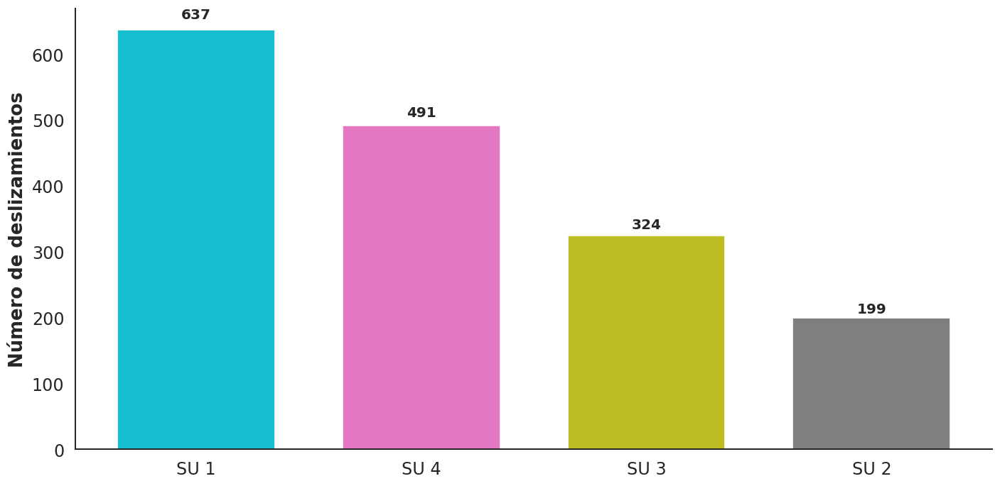

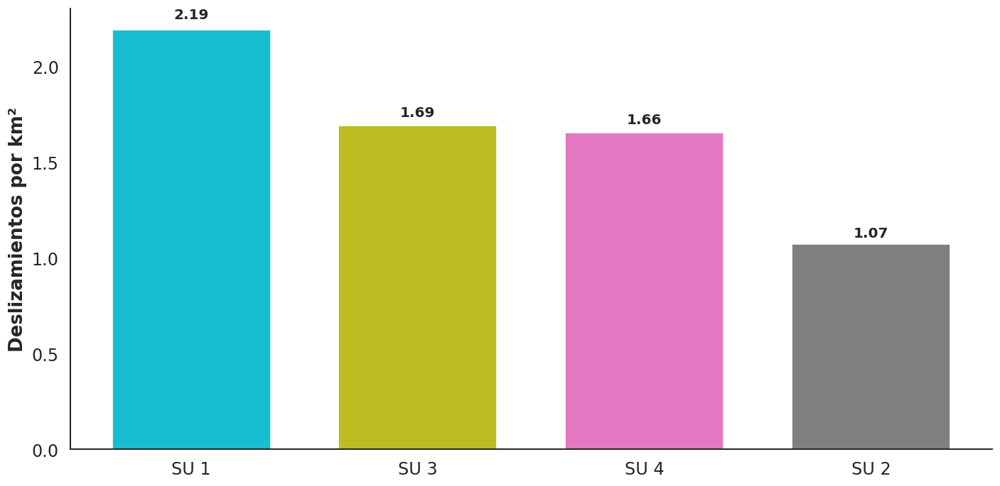

In [1]:
# === Distribución y densidad de deslizamientos por tipo de ladera (ordenado DESC) ===
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------
# 1) Cargar y preparar datos
# ------------------------------
dir_data   = '../../DATA/shape_files/'
shp_name   = 'slope_units_analisis_geohazard.shp'
COL_CLUSTER = 'cluster4'
COL_SLIDES  = 'n_mm_gpkg'

# Mapa de descripciones y paleta (coherente con tu 1.er script)
# desc_map = {
#     0: 'Pendientes\nmoderadas',
#     1: 'Pendientes\nescarpadas',
#     2: 'Pendientes\nfuertes',
#     3: 'Pendientes\nmuy fuertes'
# }

desc_map = {
    0: 'SU 1',
    1: 'SU 2',
    2: 'SU 3',
    3: 'SU 4'
}
desc_to_code = {v: k for k, v in desc_map.items()}
palette = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']  # 0,1,2,3

gdf = gpd.read_file(os.path.join(dir_data, shp_name))
gdf[COL_CLUSTER] = pd.to_numeric(gdf[COL_CLUSTER], errors='coerce')
gdf[COL_SLIDES]  = pd.to_numeric(gdf[COL_SLIDES],  errors='coerce').fillna(0)
gdf = gdf.loc[gdf.geometry.notna() & gdf[COL_CLUSTER].isin([0,1,2,3])].copy()
gdf['tipo'] = gdf[COL_CLUSTER].map(desc_map)

# ------------------------------
# 2) Totales por tipo (ordenados)
# ------------------------------
totales = (
    gdf.groupby('tipo')[COL_SLIDES]
       .sum()
       .sort_values(ascending=False)
)
df_tot = totales.reset_index(name='Deslizamientos')

# ------------------------------
# 3) Densidad por km² (ordenada)
# ------------------------------
# Determinar UTM apropiado (simple y robusto)
gdf_wgs = gdf.to_crs(4326)
c = gdf_wgs.unary_union.centroid
zone = int((c.x + 180)//6) + 1
epsg = int(f"{326 if c.y >= 0 else 327}{zone:02d}")  # 326xx norte, 327xx sur

gdf_m = gdf.to_crs(epsg)
gdf_m['area_km2'] = gdf_m.geometry.area / 1e6
gdf_m = gdf_m.loc[gdf_m['area_km2'] > 0].copy()
gdf_m['dens_su_km2'] = gdf_m[COL_SLIDES] / gdf_m['area_km2']

agg = (
    gdf_m.groupby('tipo')
         .agg(
             n_su=('tipo', 'size'),
             deslizamientos_totales=(COL_SLIDES, 'sum'),
             area_total_km2=('area_km2', 'sum')
         )
)
agg['densidad_tipo_km2'] = agg['deslizamientos_totales'] / agg['area_total_km2']
agg = agg.sort_values('densidad_tipo_km2', ascending=False)

# ------------------------------
# 4) Estilo y utilidades de gráfico
# ------------------------------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

def format_axes(ax, ylabel):
    ax.set_ylabel(ylabel, weight='bold')
    ax.set_xlabel('')
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.set_facecolor('white')
    ax.grid(False)

def add_labels(ax, bars, fmt):
    for b in bars:
        v = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            v + (0.02*v if v > 0 else 0.02),
            fmt(v),
            ha='center', va='bottom', fontsize=12, weight='bold'
        )

# ------------------------------
# 5) Gráfico: Totales (ordenado)
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
colors_tot = [palette[desc_to_code[t]] for t in df_tot['tipo']]
bars = ax.bar(df_tot['tipo'], df_tot['Deslizamientos'], color=colors_tot, width=0.7)
add_labels(ax, bars, lambda v: f'{int(v):,}'.replace(',', '.'))
format_axes(ax, 'Número de deslizamientos')
plt.tight_layout()
plt.show()

# ------------------------------
# 6) Gráfico: Densidad (des/km²) ordenada
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
colors_den = [palette[desc_to_code[t]] for t in agg.index]
bars2 = ax.bar(agg.index, agg['densidad_tipo_km2'].values, color=colors_den, width=0.7)
add_labels(ax, bars2, lambda v: f'{v:.2f}')
format_axes(ax, 'Deslizamientos por km²')
plt.tight_layout()
plt.show()


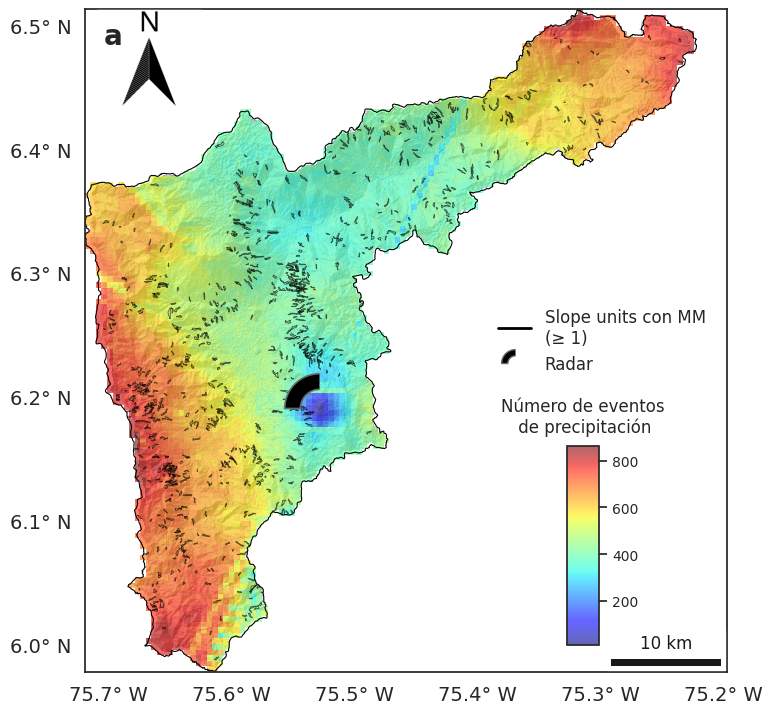

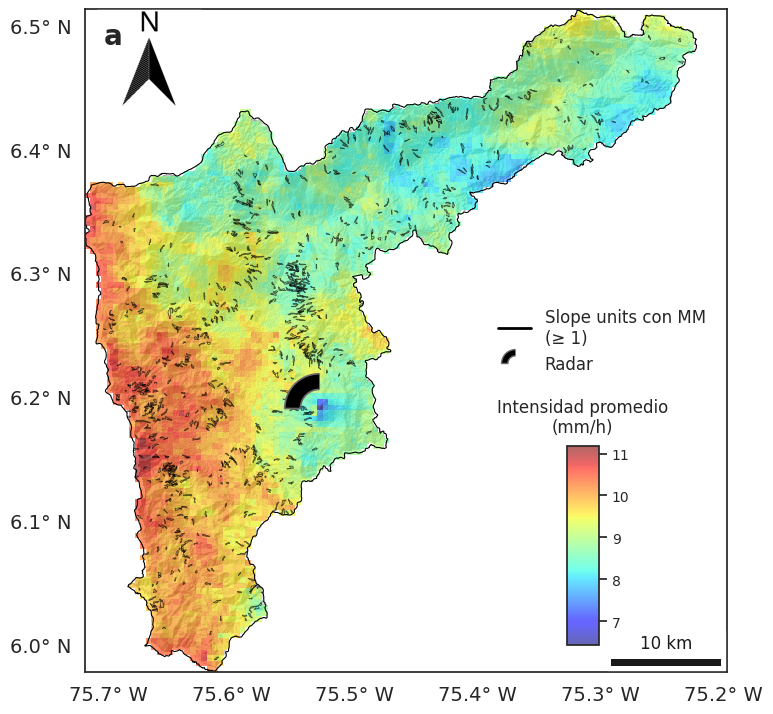

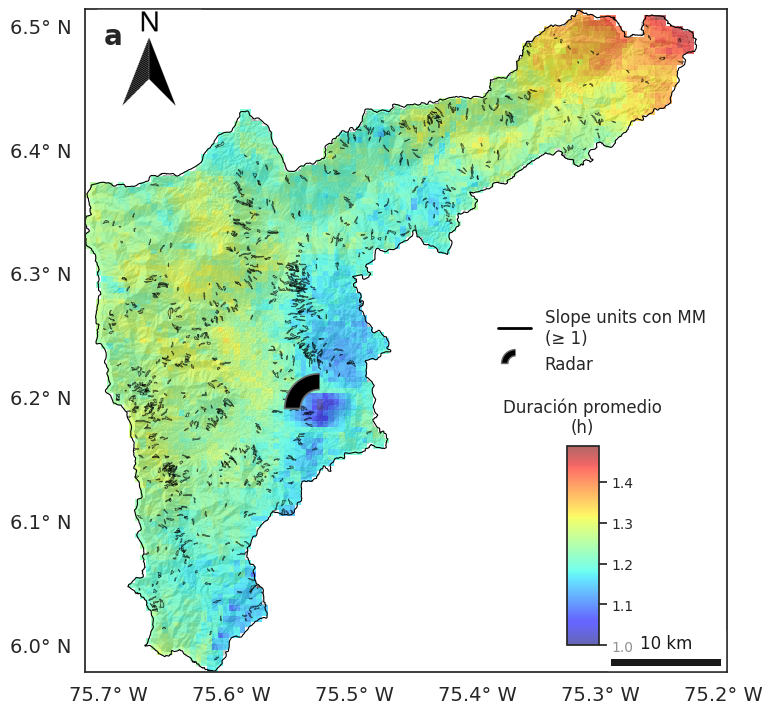

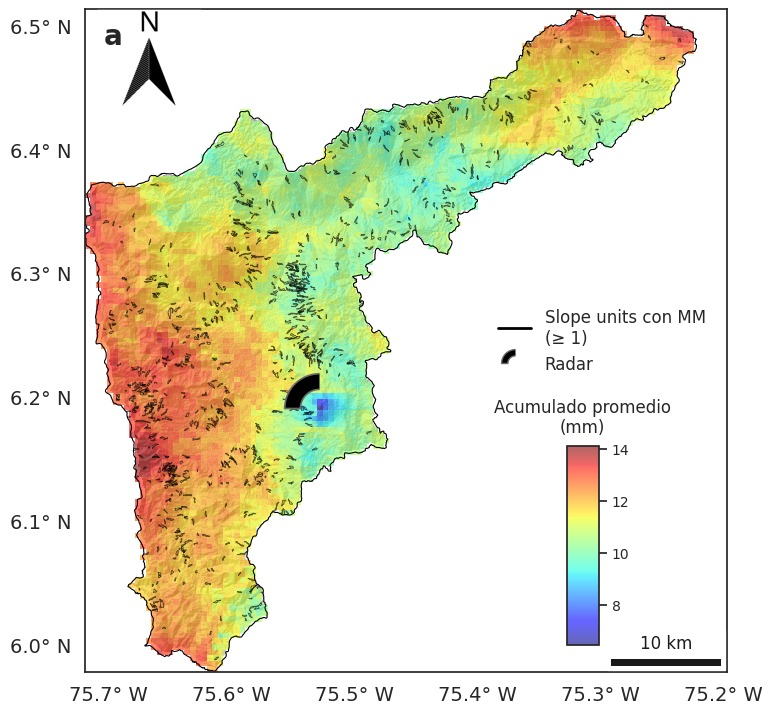

In [28]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def make_individual_event_map(
    dem, data, variable, nombre_variable, titulo,
    geojson_path, output_path, nombre_png,
    radar_csv_path,
    letter,
    slope_units_path,                   # NUEVO: ruta a slope units
    min_deslizamientos,              # NUEVO: umbral de n_mm
    cmap='jet'
):
    fig, ax = plt.subplots(figsize=(8, 9))

    # ────────── polígonos de recorte (AMVA) ──────────
    geojson = gpd.read_file(geojson_path)

    # ────────── radar (icono y ubicación) ──────────
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # ────────── slope units (filtrado n_mm ≥ 1) ──────────
    su_gdf = gpd.read_file(slope_units_path)                               # NUEVO
    # Asegurar que existe la columna
    if "n_mm_gpkg" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")
    
    su_gdf = su_gdf[su_gdf["n_mm_gpkg"].fillna(0) >= min_deslizamientos]        # NUEVO: filtro
    # Reproyectar al CRS del geojson
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)

    # Recortar slope units por el polígono de estudio
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")              # NUEVO (alternativa: gpd.clip)

    # ────────── datos ráster y DEM ──────────
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)

    # Clip DEM asegurando que 'poligono' siempre exista
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    else:
        poligono = geojson
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Sombreado del relieve
    sombra = hillshade(dem_recortado)
    extent = [
        float(data_recortada['lon'].min().values),
        float(data_recortada['lon'].max().values),
        float(data_recortada['lat'].min().values),
        float(data_recortada['lat'].max().values)
    ]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # Rango sugerido (opcional)
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35

    # Capa de calor
    pcm = ax.pcolormesh(
        data_recortada['lon'], data_recortada['lat'], data_recortada.T,
        cmap=cmap, shading='auto', alpha=0.6
        # , vmin=vmin, vmax=vmax  # activa si quieres forzar escala fija
    )

    # Contorno del límite
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # ────────── DIBUJAR SLOPE UNITS FILTRADAS ──────────
    # Estilo: contorno rojo y relleno semitransparente
    su_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.6, alpha=0.6, zorder=4)  # NUEVO
    # Si prefieres relleno: usa facecolor='crimson', alpha=0.25

    # Icono/posición del radar
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path)
    radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Formato ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Escala gráfica
    distance_meters = 111320
    scalebar = ScaleBar(
        distance_meters, location="lower right", box_alpha=0.5,
        length_fraction=0.25, scale_loc="top", font_properties={'size': 12}
    )
    ax.add_artist(scalebar)

    # Norte
    
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Barra de color en un “inset”
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3])  # [x, y, width, height] en coordenadas del eje
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Leyenda (reemplazamos entradas)
    handles, labels = ax.get_legend_handles_labels()

    # Handle para slope units (cuadro rojo)
    handle_su = Line2D([], [], linestyle='-', color='black', linewidth=2,
                       label=f"Slope units con MM\n(≥ {min_deslizamientos})")  # NUEVO

    handle_radar = Line2D([], [], marker=radar_ms, linestyle='None',
                          markerfacecolor='black', markeredgecolor='dimgray',
                          markersize=20, label='Radar')

    # Construir nueva leyenda sin duplicados
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in ('Radar',):
            new_handles.append(h); new_labels.append(lab)
    new_handles.extend([handle_su, handle_radar])
    new_labels.extend([f"Slope units con MM\n(≥ {min_deslizamientos})", 'Radar'])

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.legend(new_handles, new_labels, loc='center left',
              bbox_to_anchor=(0.62, 0.50), fontsize=12, frameon=False)

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()


#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis_geohazard.shp')  # debe tener columna 'n_mm'

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(
        dem, interpolated_ds_0_15, variable, nombre_variable, titulo,
        geojson_path, output_figures, name_png,
        radar,
        letter,
        slope_units_path=slope_units_path,       # NUEVO
        min_deslizamientos=1,                    # NUEVO: n_mm ≥ 1
        cmap='jet'
    )


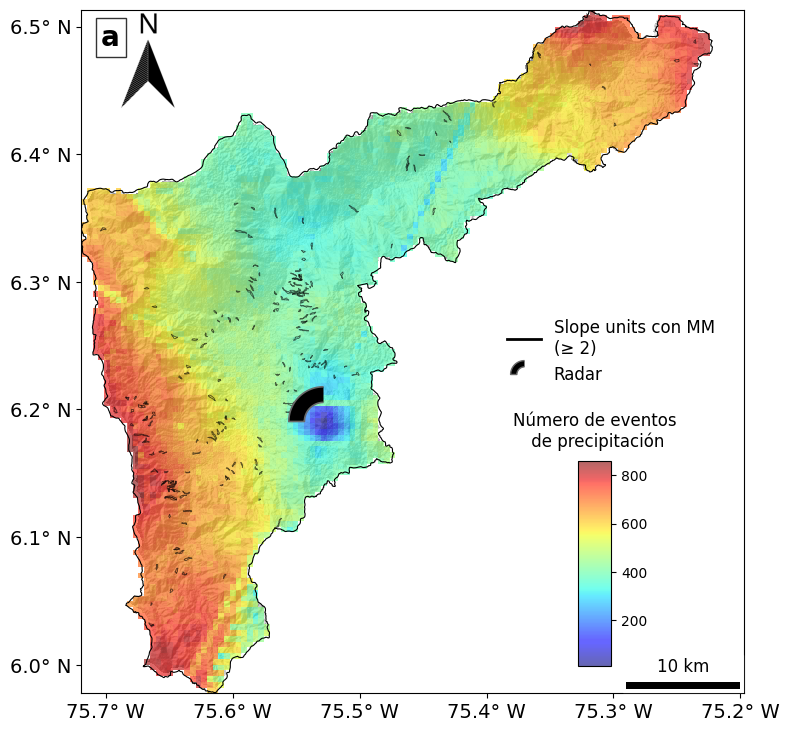

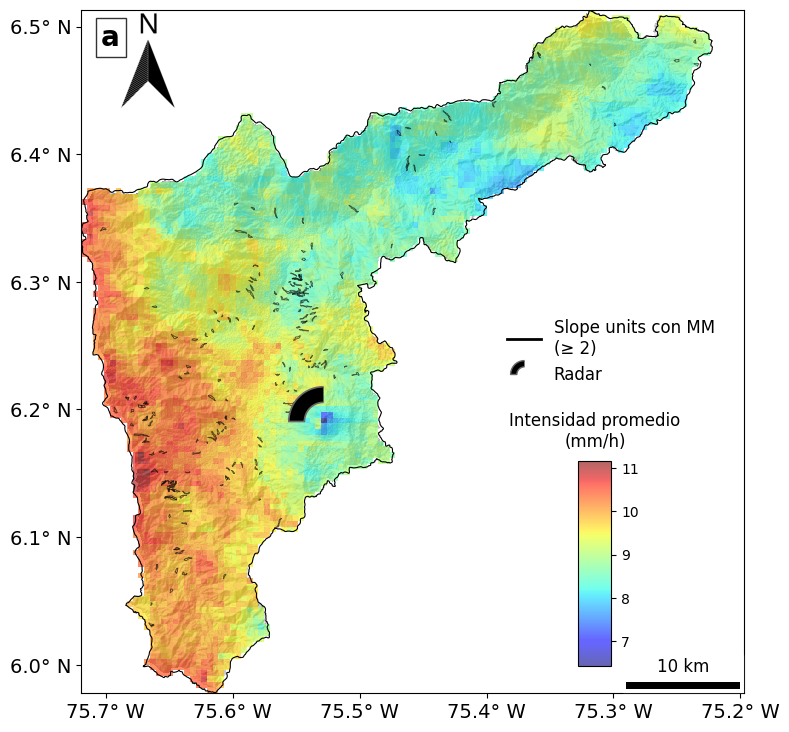

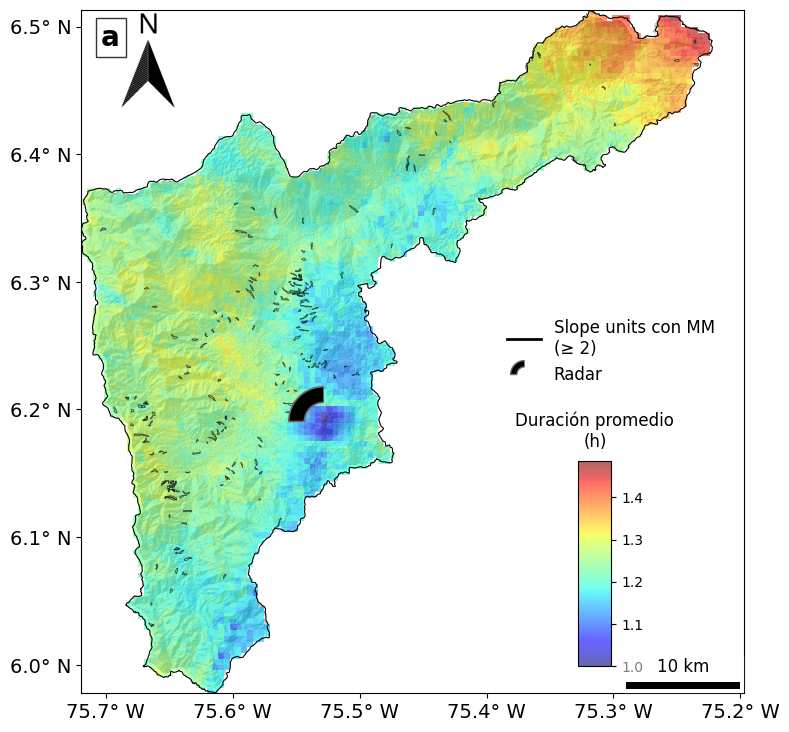

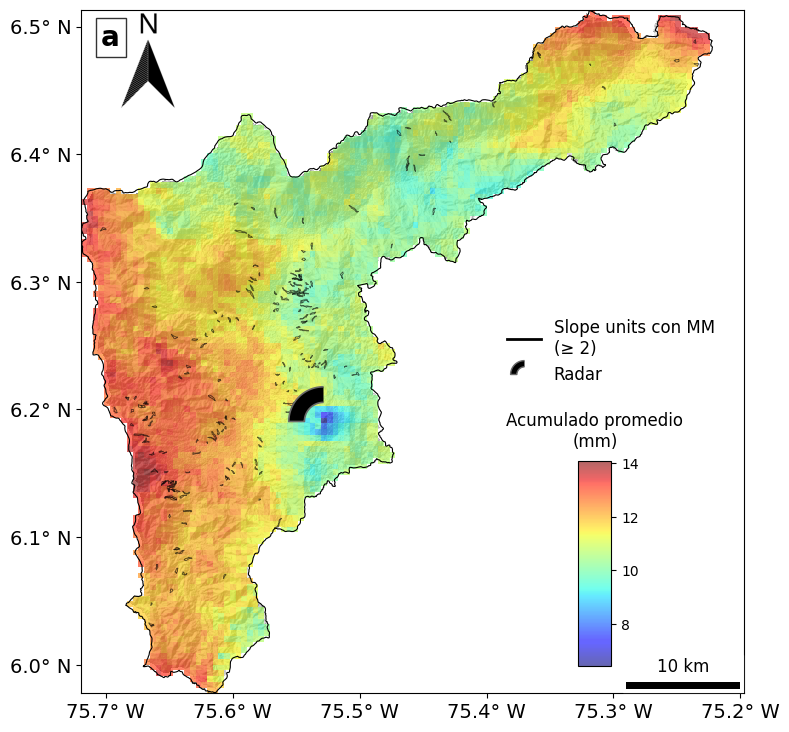

In [1]:
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize, LightSource
import matplotlib.ticker as mticker
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point, box
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D


def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def make_individual_event_map(
    dem, data, variable, nombre_variable, titulo,
    geojson_path, output_path, nombre_png,
    radar_csv_path,
    letter,
    slope_units_path,                   # NUEVO: ruta a slope units
    min_deslizamientos,              # NUEVO: umbral de n_mm
    cmap='jet'
):
    fig, ax = plt.subplots(figsize=(8, 9))

    # ────────── polígonos de recorte (AMVA) ──────────
    geojson = gpd.read_file(geojson_path)

    # ────────── radar (icono y ubicación) ──────────
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    if radar_gdf.crs != geojson.crs:
        radar_gdf = radar_gdf.to_crs(geojson.crs)

    # ────────── slope units (filtrado n_mm ≥ 1) ──────────
    su_gdf = gpd.read_file(slope_units_path)                               # NUEVO
    # Asegurar que existe la columna
    if "n_mm_gpkg" not in su_gdf.columns:
        raise ValueError("La capa de slope units no tiene la columna 'n_mm'.")
    
    su_gdf = su_gdf[su_gdf["n_mm_gpkg"].fillna(0) >= min_deslizamientos]        # NUEVO: filtro
    # Reproyectar al CRS del geojson
    if su_gdf.crs != geojson.crs:
        su_gdf = su_gdf.to_crs(geojson.crs)

    # Recortar slope units por el polígono de estudio
    su_gdf = gpd.overlay(su_gdf, geojson, how="intersection")              # NUEVO (alternativa: gpd.clip)

    # ────────── datos ráster y DEM ──────────
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)

    # Clip DEM asegurando que 'poligono' siempre exista
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    else:
        poligono = geojson
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Sombreado del relieve
    sombra = hillshade(dem_recortado)
    extent = [
        float(data_recortada['lon'].min().values),
        float(data_recortada['lon'].max().values),
        float(data_recortada['lat'].min().values),
        float(data_recortada['lat'].max().values)
    ]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # Rango sugerido (opcional)
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35

    # Capa de calor
    pcm = ax.pcolormesh(
        data_recortada['lon'], data_recortada['lat'], data_recortada.T,
        cmap=cmap, shading='auto', alpha=0.6
        # , vmin=vmin, vmax=vmax  # activa si quieres forzar escala fija
    )

    # Contorno del límite
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # ────────── DIBUJAR SLOPE UNITS FILTRADAS ──────────
    # Estilo: contorno rojo y relleno semitransparente
    su_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.6, alpha=0.6, zorder=4)  # NUEVO
    # Si prefieres relleno: usa facecolor='crimson', alpha=0.25

    # Icono/posición del radar
    radar_path = radar_marker()
    radar_ms = MarkerStyle(radar_path)
    radar_ms._transform.rotate_deg(180)
    radar_gdf.plot(
        ax=ax, marker=radar_ms, markersize=2500, facecolor='black',
        edgecolor='dimgray', linewidth=1.2, label='Radar', zorder=5
    )

    # Formato ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Escala gráfica
    distance_meters = 111320
    scalebar = ScaleBar(
        distance_meters, location="lower right", box_alpha=0.5,
        length_fraction=0.25, scale_loc="top", font_properties={'size': 12}
    )
    ax.add_artist(scalebar)

    # Norte
    
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)

    # Barra de color en un “inset”
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3])  # [x, y, width, height] en coordenadas del eje
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Leyenda (reemplazamos entradas)
    handles, labels = ax.get_legend_handles_labels()

    # Handle para slope units (cuadro rojo)
    handle_su = Line2D([], [], linestyle='-', color='black', linewidth=2,
                       label=f"Slope units con MM\n(≥ {min_deslizamientos})")  # NUEVO

    handle_radar = Line2D([], [], marker=radar_ms, linestyle='None',
                          markerfacecolor='black', markeredgecolor='dimgray',
                          markersize=20, label='Radar')

    # Construir nueva leyenda sin duplicados
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in ('Radar',):
            new_handles.append(h); new_labels.append(lab)
    new_handles.extend([handle_su, handle_radar])
    new_labels.extend([f"Slope units con MM\n(≥ {min_deslizamientos})", 'Radar'])

    ax.text(0.03, 0.98, letter, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8))

    ax.legend(new_handles, new_labels, loc='center left',
              bbox_to_anchor=(0.62, 0.50), fontsize=12, frameon=False)

    plt.tight_layout()
    # plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()


#-----------------------------------------------------------------------
#------------------ SCRIPT PRINCIPAL ----------------------------------
#-----------------------------------------------------------------------

radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos\n de precipitación', 'Intensidad promedio\n(mm/h)', 'Duración promedio\n(h)', 'Acumulado promedio\n(mm)']
titles = ['Número de eventos de precipitación', 'Intensidad promedio de precipitación', 'Duración promedio de eventos de precipitación', 'Acumulado promedio de precipitación']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)

geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# CSV con coordenadas a excluir
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos del NetCDF
file = 'eventos_lluvia_5mm_1horas_2.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# RUTA RADAR (icono ubicación)
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# ────────── NUEVO: SLOPE UNITS ──────────
dir_data   = '../../DATA/shape_files/'
slope_units_path = os.path.join(dir_data, 'slope_units_analisis_geohazard.shp')  # debe tener columna 'n_mm'

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(
        dem, interpolated_ds_0_15, variable, nombre_variable, titulo,
        geojson_path, output_figures, name_png,
        radar,
        letter,
        slope_units_path=slope_units_path,       # NUEVO
        min_deslizamientos=2,                    # NUEVO: n_mm ≥ 1
        cmap='jet'
    )


## **GRAFICOS DE DISPERSIÓN**

Tengo: 

- Tipos de Slope Units (Tipo 1, Tipo 2, Tipo 3, Tipo 4)
- Zonas de lluvia (Zona 1: Norte, Zona 2: Oriente, Zona 3: Occidente, Zona 4: Sur, Zona 5: SAP)
- Inventario de deslizamientos (Landslides: 0 = No, 1 = Yes).
- Eventos de lluvia del Radar para cada celda.

Quiero:

- Hacer un grafico de dispersión que muestre en el eje x la duracion y en el eje y la intensidad promedio para cada tipo de slope unit para cada zonas de lluvia y para cada inventario de deslizamientos.

Quiero graficar por ejemplo un punto que será la intensidad promedio para todas las slope units del tipo 1 que estan en la zonas 1 (Norte) y que tienen deslizamineto (con el tamaño del punto serán muchos deslizamientos es grande y pequeño poco deslizamientos) y la duracion promedio para todas esas slope units. La zona 1 (Norte) tendra un simbolo de un cuadrado, y el tipo de slope unit 1 tendra un color rojo.

In [6]:
# %% ================================================================
# 0) Importaciones
# ================================================================
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=UserWarning)


# %% ================================================================
# 1) Utilidad: asegurar CRS proyectado (metros) para áreas/distancias
# ================================================================
def _ensure_projected(gdf):
    """
    Si el CRS es geográfico (grados) proyecta a un CRS UTM aproximado según el cent
    roide.
    Devuelve una copia proyectada y el CRS original.
    """
    if gdf.crs is None:
        raise ValueError("El GeoDataFrame no tiene CRS definido.")

    if not gdf.crs.is_geographic:
        return gdf.copy(), gdf.crs  # ya está proyectado (metros)

    # Estimar zona UTM a partir del centroide (asume WGS84)
    centroid = gdf.to_crs(4326).geometry.unary_union.centroid
    lon = centroid.x
    lat = centroid.y
    utm_zone = int((lon + 180) // 6) + 1
    is_north = lat >= 0
    epsg = 32600 + utm_zone if is_north else 32700 + utm_zone
    return gdf.to_crs(epsg), gdf.crs


# %% ================================================================
# 2) Tu función: filtrar e interpolar NetCDF (tal cual)
# ================================================================
def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas
    en un archivo CSV y luego interpola los valores faltantes.
    """
    coords_df = pd.read_csv(coord_file)
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values

    data = xr.open_dataset(radar_file)

    mask = xr.DataArray(
        np.ones((len(data.lon), len(data.lat)), dtype=bool),
        coords=[data.lon, data.lat],
        dims=["lon", "lat"]
    )

    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False

    data_filtrado = data.where(mask, drop=True)

    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    return interpolated_ds


# %% ================================================================
# 3) Utilidades geoespaciales y de agregación
# ================================================================
def detectar_lat_lon(ds):
    """Detecta nombres de coords lat/lon y si son 1D."""
    cand_lat = ['lat', 'latitude', 'y', 'Norte']
    cand_lon = ['lon', 'longitude', 'x', 'Este']
    lat_name = next((c for c in cand_lat if c in ds.coords or c in ds.variables), None)
    lon_name = next((c for c in cand_lon if c in ds.coords or c in ds.variables), None)
    if lat_name is None or lon_name is None:
        raise ValueError("No pude detectar coordenadas de lat/lon en el NetCDF.")
    is_1d = (ds[lat_name].ndim == 1 and ds[lon_name].ndim == 1)
    return lat_name, lon_name, is_1d


def ds_a_puntos_gdf(ds, var_names, su_crs):
    """
    Convierte un Dataset (ya filtrado/interpolado) en un GeoDataFrame de puntos con
    variables var_names. Se adapta al orden de ejes (lat,lon)/(lon,lat) y a coords 1D/2D.
    """
    lat_name, lon_name, is_1d = detectar_lat_lon(ds)

    ref_var = var_names[0]
    ref_arr = np.squeeze(ds[ref_var].values)
    ref_shape = ref_arr.shape

    if is_1d:
        x = ds[lon_name].values  # lon
        y = ds[lat_name].values  # lat
        Nx, Ny = len(x), len(y)
        # Construimos SIEMPRE malla (Ny, Nx) = (lat,lon)
        LON, LAT = np.meshgrid(x, y, indexing='xy')  # -> (Ny, Nx)
        shape_yx = (Nx, Ny)  # (lon, lat)
        need_T = (ref_shape == shape_yx)
    else:
        LON = ds[lon_name].values
        LAT = ds[lat_name].values
        if ref_shape == LON.shape:
            need_T = False
        elif ref_shape == LON.T.shape:
            LON, LAT = LON.T, LAT.T
            need_T = False
        else:
            raise ValueError(
                f"No puedo alinear lon/lat 2D con la variable de referencia. "
                f"ref_shape={ref_shape}, LON.shape={LON.shape}, LAT.shape={LAT.shape}"
            )

    data_cols = {}
    for v in var_names:
        arr = np.squeeze(ds[v].values)
        if is_1d and need_T and arr.ndim == 2 and arr.shape == (Nx, Ny):
            arr = arr.T
        if arr.ndim == 2 and arr.shape != LON.shape and arr.T.shape == LON.shape:
            arr = arr.T
        if arr.shape != LON.shape:
            raise ValueError(
                f"'{v}' no calza con la malla: {arr.shape} vs {LON.shape}. "
                f"dims de '{v}': {getattr(ds[v], 'dims', None)}"
            )
        data_cols[v] = arr.ravel()

    df = pd.DataFrame({'lon': LON.ravel(), 'lat': LAT.ravel(), **data_cols})
    df = df.dropna(subset=var_names, how='all')

    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs='EPSG:4326')
    if su_crs is not None and gdf.crs != su_crs:
        gdf = gdf.to_crs(su_crs)
    return gdf


def _estimar_tamano_celda_xy(pts_gdf):
    """Estima tamaño de celda (pasos) en X e Y (metros)."""
    xs = np.asarray(pts_gdf.geometry.x)
    ys = np.asarray(pts_gdf.geometry.y)
    dx = np.diff(np.sort(xs))
    dy = np.diff(np.sort(ys))
    dx = dx[dx > 0]
    dy = dy[dy > 0]
    step_x = np.nanmedian(dx) if dx.size else np.nanmedian(dy)
    step_y = np.nanmedian(dy) if dy.size else np.nanmedian(dx)
    return float(step_x), float(step_y)


def _puntos_a_celdas(pts_gdf, half_x, half_y):
    """Convierte cada punto centroide en un polígono-celda rectangular."""
    polys = []
    for p in pts_gdf.geometry:
        x, y = p.x, p.y
        poly = Polygon([(x-half_x, y-half_y),
                        (x+half_x, y-half_y),
                        (x+half_x, y+half_y),
                        (x-half_x, y+half_y)])
        polys.append(poly)
    gdf_cells = pts_gdf.copy()
    gdf_cells.geometry = polys
    return gdf_cells


def agregar_lluvia_a_su_area_ponderada(su_gdf, puntos_gdf, var_names, fallback_radio_m=600):
    """
    Promedia variables de lluvia por SU usando ponderación areal:
      1) Convierte puntos (centros de píxel) en celdas-polígono.
      2) Interseca SU∩celdas, promedia con pesos=área de intersección.
      3) Fallback con sjoin_nearest para SU sin datos (radio en metros).
    """
    # Asegurar CRS proyectado (metros) en ambos
    su_proj, su_crs_original = _ensure_projected(su_gdf)
    pts_proj = puntos_gdf.to_crs(su_proj.crs)

    su = su_proj.copy()
    if 'su_idx' not in su.columns:
        su['su_idx'] = su.index

    # 1) Celdas-polígono
    step_x, step_y = _estimar_tamano_celda_xy(pts_proj)
    half_x, half_y = 0.5*step_x, 0.5*step_y
    cells = _puntos_a_celdas(pts_proj[['geometry'] + var_names].copy(), half_x, half_y)
    cells = cells.set_geometry('geometry')
    cells.crs = su.crs

    # 2) Intersección SU ∩ celdas
    su = su.copy()
    su['geometry'] = su['geometry'].buffer(0)  # arreglos topológicos pequeños
    inter = gpd.overlay(cells, su[['su_idx', 'geometry']], how='intersection')
    if inter.empty:
        print("[WARN] No hubo intersecciones SU∩celdas. Verifica CRS y cobertura.")
        inter['area_w'] = np.nan
    else:
        inter['area_w'] = inter.area

    # 3) Promedio ponderado
    su_vals = []
    for suidx, grp in inter.groupby('su_idx'):
        w = grp['area_w'].to_numpy()
        W = np.nansum(w)
        rec = {'su_idx': suidx}
        for v in var_names:
            vals = grp[v].to_numpy()
            rec[v] = (np.nansum(vals * w) / W) if (np.isfinite(W) and W > 0) else np.nan
        su_vals.append(rec)
    su_stats = (pd.DataFrame(su_vals).set_index('su_idx')
                if su_vals else pd.DataFrame(columns=['su_idx']+var_names).set_index('su_idx'))

    # Volcar a SU
    for v in var_names:
        su.loc[su_stats.index, v] = su_stats[v]

    # 4) Fallback: vecino más cercano para SU sin datos
 # 4) Fallback: vecino más cercano para SU sin datos
    faltan = su[su[var_names].isna().all(axis=1)].copy()
    if not faltan.empty:
        # centroide de SU
        faltan_cent = faltan.set_geometry(faltan.centroid)

        nearest = gpd.sjoin_nearest(
            faltan_cent[['su_idx', 'geometry']],
            cells[['geometry'] + var_names],
            how='left',
            max_distance=fallback_radio_m,
            distance_col='dist'
        )

        # Si por alguna razón hay duplicados por su_idx (empates), nos quedamos con la primera (o la más cercana)
        # Aquí tomamos la fila con menor distancia por su_idx:
        nearest = (nearest.sort_values('dist')
                          .groupby('su_idx', as_index=True)
                          .first())

        # Construimos una tabla de valores por su_idx para mapear
        vals_df = nearest[var_names]  # index = su_idx

        for v in var_names:
            # Serie alineada al índice de 'su' (su_idx) usando map
            mapped = su.index.to_series().map(vals_df[v])  # devuelve Serie indexada como su.index
            # Rellenamos solo donde su[v] es NaN
            su[v] = su[v].fillna(mapped)

    # Regresar al CRS original de las SU si venía geográfico
    su_out = su.to_crs(su_crs_original)
    return su_out, su_stats


def agrupar_por_tipo_y_zona(su_enriquecida, var_names):
    """
    Agrega por (tipo de SU=cluster4, zona ENTERA).
    - Lluvia: promedio entre SUs del grupo (usando datos disponibles).
    - n_mm_total: suma de deslizamientos (para tamaño de símbolo).
    Supone que 'zona' ya viene numérica (float) codificada 1..5.
    """
    # Tomamos columnas necesarias
    df = su_enriquecida[['cluster4', 'zona', 'n_mm'] + var_names].copy()

    # n_mm seguro (suma no falle)
    df['n_mm'] = pd.to_numeric(df['n_mm'], errors='coerce').fillna(0)

    # cluster4 numérico
    df['cluster4'] = pd.to_numeric(df['cluster4'], errors='coerce')

    # tipo_su: si viene 0..3 -> 1..4; si ya viene 1..4, lo dejamos
    min_c4 = df['cluster4'].min(skipna=True)
    df['tipo_su'] = np.where(pd.notnull(min_c4) & (min_c4 == 0),
                             df['cluster4'] + 1, df['cluster4'])

    # zona numérica (float -> entero). Si hay decimales por redondeo, usamos round antes del cast
    df['zona_num'] = pd.to_numeric(df['zona'], errors='coerce')
    # Requerimos zona y tipo válidos
    before = len(df)
    df = df.dropna(subset=['tipo_su', 'zona_num'], how='any').copy()
    print(f"[INFO] Filas descartadas por zona/tipo NaN: {before - len(df)}")

    # Al menos UNA variable de lluvia válida (no tiramos filas por tener alguna NaN)
    mask_lluvia = df[var_names].notna().any(axis=1)
    print(f"[INFO] SU sin ninguna variable de lluvia válida: {(~mask_lluvia).sum()}")
    df = df[mask_lluvia].copy()

    # Casteos seguros
    df['tipo_su'] = df['tipo_su'].astype(int)
    # Si vienen como 1.0, 2.0... esto los vuelve 1, 2...
    # Usar .round() por si hay floats tipo 2.0000001
    df['zona'] = df['zona_num'].round().astype(int)

    # Agregación por (tipo_su, zona)
    gp = df.groupby(['tipo_su', 'zona'], as_index=False).agg({
        var_names[0]: 'mean',   # num_eventos
        var_names[1]: 'mean',   # intensidad_promedio
        var_names[2]: 'mean',   # duracion_promedio
        var_names[3]: 'mean',   # acumulado_promedio
        var_names[4]: 'mean',   # intensidad_maxima_promedio
        'n_mm': 'sum'           # total deslizamientos
    }).rename(columns={'n_mm': 'n_mm_total'})

    return gp

# %% ================================================================
# 4) Rutas y archivos
# ================================================================
radar_events_dir = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'              # (no usado directo aquí)
output_figures   = '../../FIGURES/spatial_analysis/radar/'
os.makedirs(output_figures, exist_ok=True)

ruta_slope_units = '../../DATA/shape_files/slope_units_analisis.shp'
file_nc          = 'eventos_lluvia_5mm_1horas_2.nc'
coord_file       = f'{radar_events_dir}coordenadas_que_no.csv'

# %% ================================================================
# 5) Flujo principal
# ================================================================
# 5.1 Leer Slope Units
su_gdf = gpd.read_file(ruta_slope_units)
if su_gdf.crs is None:
    raise ValueError("El shapefile de Slope Units no tiene CRS. Asígnalo antes de continuar.")
su_crs = su_gdf.crs

for col in ['cluster4', 'zona', 'n_mm', 'si_no']:
    if col not in su_gdf.columns:
        raise ValueError(f"Falta la columna '{col}' en {ruta_slope_units}")

# 5.2 Filtrar + interpolar NetCDF
ds_filtrado = filter_and_interpolate_data(
    radar_file=os.path.join(radar_events_dir, file_nc),
    coord_file=coord_file
)

# 5.3 Dataset -> puntos (en CRS de las SU)
var_names = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio', 'intensidad_maxima_promedio']
gdf_pts = ds_a_puntos_gdf(ds_filtrado, var_names=var_names, su_crs=su_crs)
print(f"Puntos de radar tras filtrado/interpolación: {len(gdf_pts):,}")

# 5.4 Enriquecer SU con promedio ponderado por área (+fallback vecino)
su_enriquecida, su_stats = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf,
    puntos_gdf=gdf_pts,
    var_names=var_names,
    fallback_radio_m=600
)



# Debug rápido
print("Total SU:", len(su_enriquecida))
print("\nValores únicos de 'zona' (muestra 15):")
print(su_enriquecida['zona'].drop_duplicates().astype(str).head(15).to_list())
print("\n¿Cuántas SU tienen cada variable de lluvia NaN?")
for v in var_names:
    nmiss = su_enriquecida[v].isna().sum()
    print(f"  {v}: NaN en {nmiss} SU ({nmiss/len(su_enriquecida):.1%})")
print("\nFaltantes en cluster4 y zona:")
print("  cluster4 NaN:", su_enriquecida['cluster4'].isna().sum())
print("  zona NaN:", su_enriquecida['zona'].isna().sum())

# 5.5 Agregar por (tipo de SU, zona)
df_plot = agrupar_por_tipo_y_zona(su_enriquecida, var_names)


# %% ================================================================
# 5.6 Área por grupo (tipo_su, zona) y métricas normalizadas
# ================================================================
# A) Proyectar SU para calcular áreas en metros y preparar columnas
su_proj, _crs_orig = _ensure_projected(su_enriquecida)


area_tbl = su_proj[['cluster4', 'zona', 'geometry']].copy()
area_tbl['area_km2'] = area_tbl.geometry.area / 1e6  # m² -> km²


# cluster4 y zona a numéricos seguros
area_tbl['cluster4_num'] = pd.to_numeric(area_tbl['cluster4'], errors='coerce')
area_tbl['zona_num']     = pd.to_numeric(area_tbl['zona'], errors='coerce')

# descartar filas sin zona o cluster válidos
before = len(area_tbl)
area_tbl = area_tbl.dropna(subset=['cluster4_num', 'zona_num']).copy()
print(f"[INFO] SU sin zona/cluster válidos para área: {before - len(area_tbl)}")

# Mapear cluster4 -> tipo_su (si venía 0..3 => 1..4; si ya era 1..4, se mantiene)
min_c4 = area_tbl['cluster4_num'].min(skipna=True)
area_tbl['tipo_su'] = np.where(pd.notnull(min_c4) & (min_c4 == 0),
                               area_tbl['cluster4_num'] + 1,
                               area_tbl['cluster4_num']).astype(int)

# zona como entero robusto
area_tbl['zona'] = area_tbl['zona_num'].round().astype(int)

# B) Agregar área por grupo (tipo_su, zona)
area_group = (area_tbl
              .groupby(['tipo_su', 'zona'], as_index=False)['area_km2']
              .sum())

# C) Unir al df_plot y calcular densidad y proporción global
df_plot = df_plot.merge(area_group, on=['tipo_su', 'zona'], how='left')

# Densidad areal (inventario): deslizamientos por km²
df_plot['dens_mm_km2'] = df_plot['n_mm_total'] / df_plot['area_km2'].replace({0: np.nan})

# Proporción global (participación del total del inventario)
total_mm = df_plot['n_mm_total'].sum()
df_plot['p_global'] = np.where(total_mm > 0, df_plot['n_mm_total'] / total_mm, np.nan)

# (Opcional) Mensajes de control
n_area_nan = df_plot['area_km2'].isna().sum()
if n_area_nan:
    print(f"[WARN] Grupos sin área_km2 (posibles SU sin geometría válida o fuera de zona): {n_area_nan}")

print(df_plot[['tipo_su','zona','area_km2','n_mm_total','dens_mm_km2','p_global']].head())




Puntos de radar tras filtrado/interpolación: 13,209
Total SU: 57524

Valores únicos de 'zona' (muestra 15):
['2.0', '4.0', '5.0', '3.0', '1.0', 'nan']

¿Cuántas SU tienen cada variable de lluvia NaN?
  num_eventos: NaN en 0 SU (0.0%)
  intensidad_promedio: NaN en 0 SU (0.0%)
  duracion_promedio: NaN en 0 SU (0.0%)
  acumulado_promedio: NaN en 0 SU (0.0%)
  intensidad_maxima_promedio: NaN en 0 SU (0.0%)

Faltantes en cluster4 y zona:
  cluster4 NaN: 0
  zona NaN: 146
[INFO] Filas descartadas por zona/tipo NaN: 146
[INFO] SU sin ninguna variable de lluvia válida: 0
[INFO] SU sin zona/cluster válidos para área: 146
   tipo_su  zona    area_km2  n_mm_total  dens_mm_km2  p_global
0        1     1   48.713752          30     0.615843  0.005300
1        1     2  161.522940         320     1.981143  0.056537
2        1     3   47.234392         243     5.144557  0.042933
3        1     4    2.787007          45    16.146354  0.007951
4        1     5   29.089672         171     5.878375  0.030

In [9]:
df_plot

,tipo_su,zona,num_eventos,intensidad_promedio,duracion_promedio,acumulado_promedio,intensidad_maxima_promedio,n_mm_total,area_km2,dens_mm_km2,p_global
0,1,1,383.804725,8.987003,1.178788,10.533862,9.316323,30,48.713752,0.615843,0.005300
1,1,2,458.181116,8.748104,1.249677,10.902133,9.212207,320,161.522940,1.981143,0.056537
2,1,3,630.340460,9.852133,1.219701,11.975975,10.382403,243,47.234392,5.144557,0.042933
3,1,4,718.035772,10.302829,1.254815,12.828971,10.962982,45,2.787007,16.146354,0.007951
4,1,5,526.753219,9.494244,1.269431,11.944993,10.063578,171,29.089672,5.878375,0.030212
5,2,1,331.660403,9.000476,1.153330,10.381281,9.283209,29,6.349573,4.567236,0.005124
6,2,2,509.401414,8.637454,1.257125,10.867133,9.115205,310,53.755519,5.766850,0.054770
7,2,3,634.985174,9.873581,1.208760,11.965040,10.408389,337,65.193261,5.169246,0.059541
8,2,4,728.656039,10.180444,1.257973,12.757657,10.842057,186,16.777265,11.086431,0.032862
9,2,5,629.178665,9.954760,1.251398,12.456208,10.589280,234,43.215722,5.414696,0.041343


In [10]:
su_gdf.columns

Index(['index', 'slope_mean', 'aspect_maj', 'flowacum_m', 'tpi_mean',
       'ugs_majo', 'twi_mean', 'mm', 'area', 'curvatura', 'cobertura',
       'cluster4', 'su_idx', 'zona', 'n_mm', 'si_no', 'geometry'],
      dtype='object')

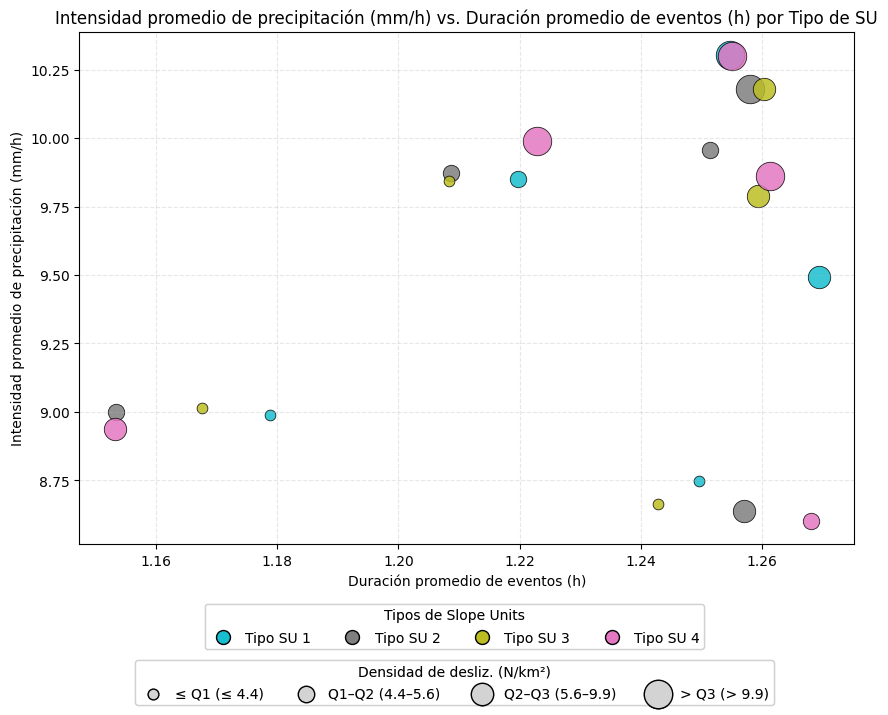

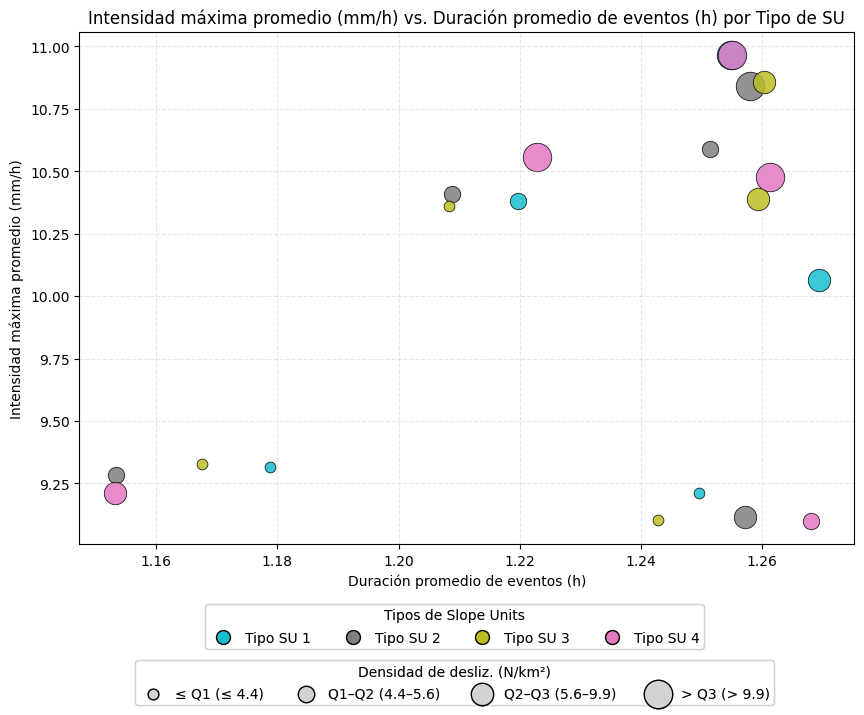

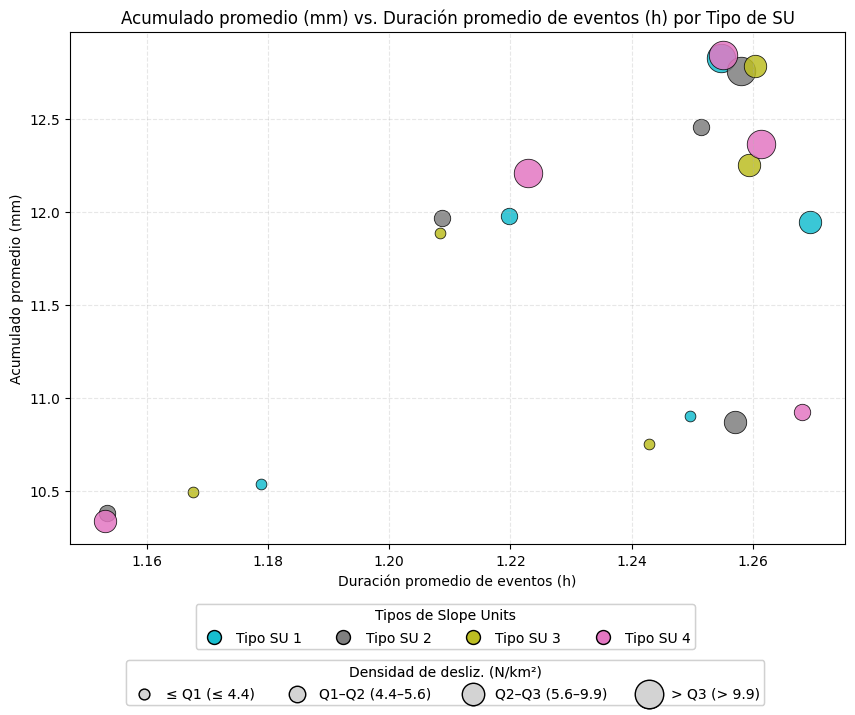

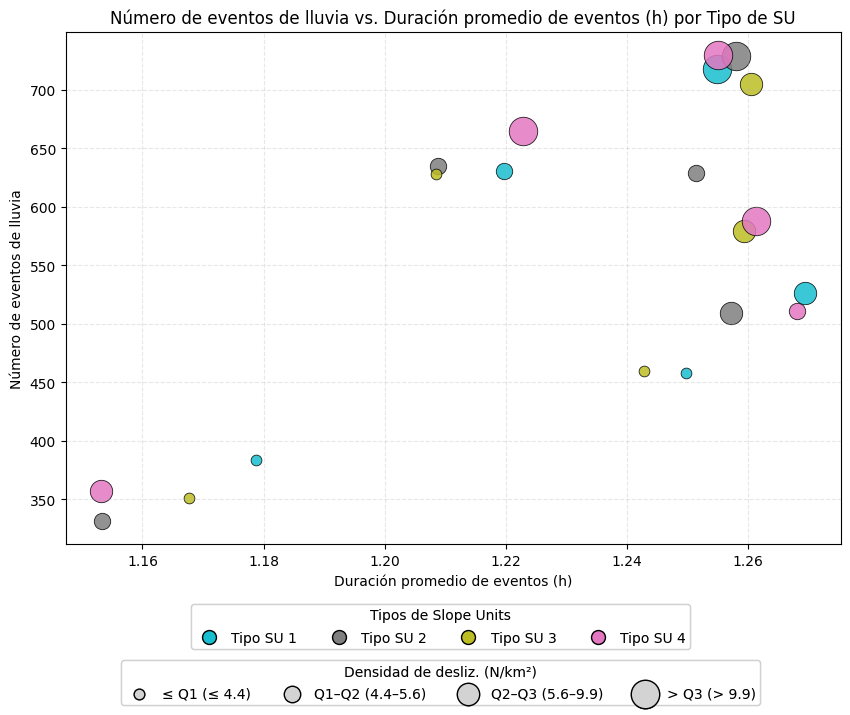

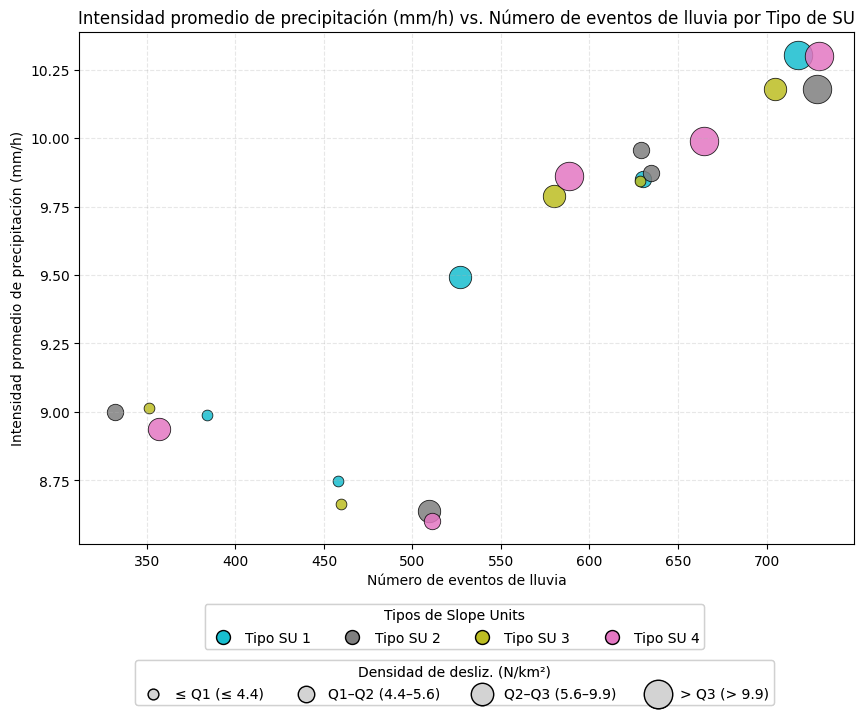

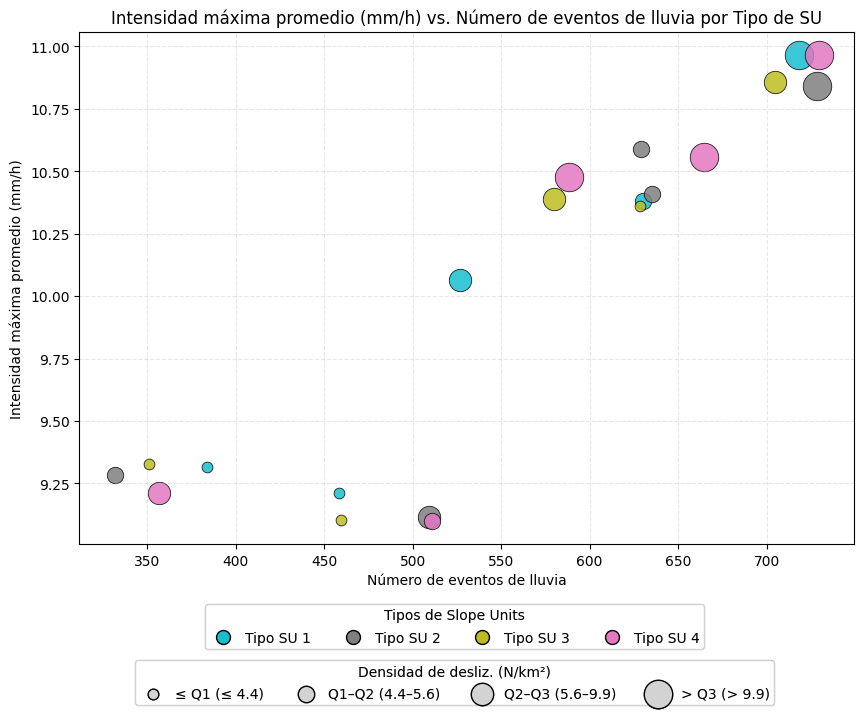

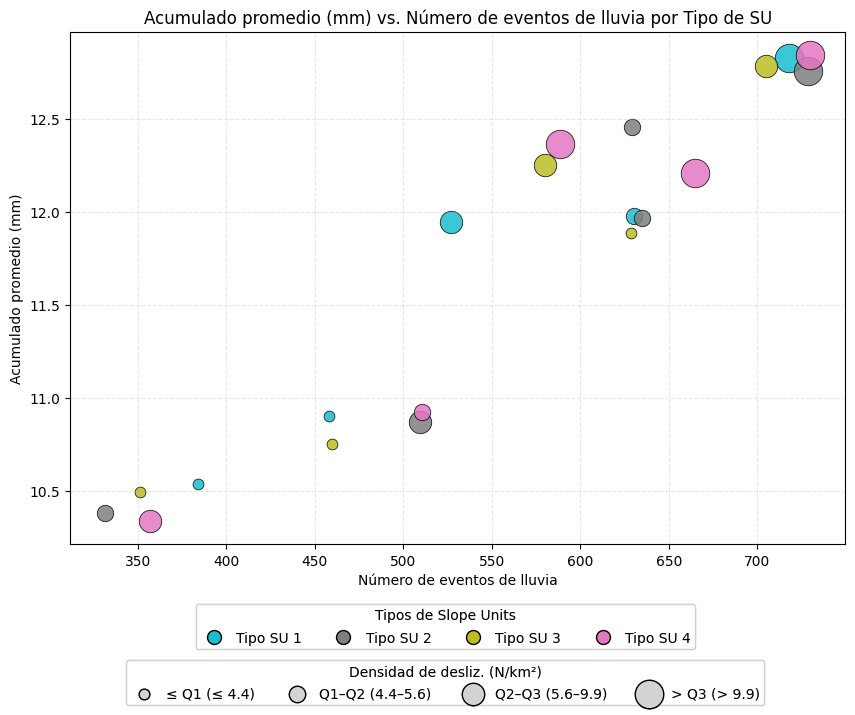

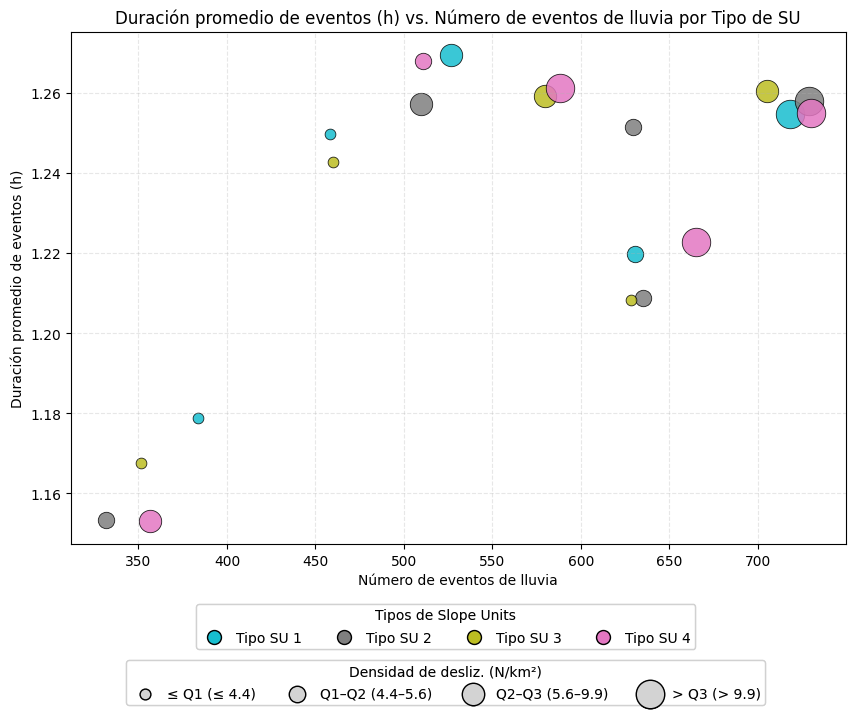

In [11]:
# ============================
# Configuración visual común
# ============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- 1) Colores por tipo de SU (se conservan) ---
color_por_tipo = {1: '#17becf', 2: '#7f7f7f', 3: '#bcbd22', 4: '#e377c2'}

# >>> Eliminado: marcadores por zona (todo será círculo 'o')
# marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
# zona_label = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}

# --- 2) Tamaños por densidad (bins por cuantiles o umbrales fijos) ---
def _build_size_by_density(df, metric='dens_mm_km2', use_quantiles=True, fmt="{:.3f}"):
    """
    Devuelve:
      - sizes: array con áreas de marcador
      - bin_labels (internas): etiquetas discretas para mapear tamaños
      - size_map: dict etiqueta->tamaño
      - display_labels: etiquetas para la leyenda con Q1, Q2, Q3 impresos
    """
    size_levels = [60, 140, 260, 420]

    x = df[metric].replace([np.inf, -np.inf], np.nan).fillna(0)

    if use_quantiles:
        q1, q2, q3 = x.quantile([0.25, 0.50, 0.75]).values
        bins = [-np.inf, q1, q2, q3, np.inf]
        bin_labels = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']  # internas
        # Etiquetas “bonitas” con valores
        display_labels = [
            f"≤ Q1 (≤ {q1:.1f})",
            f"Q1–Q2 ({q1:.1f}–{q2:.1f})",
            f"Q2–Q3 ({q2:.1f}–{q3:.1f})",
            f"> Q3 (> {q3:.1f})"
        ]
    else:
        bins = [-np.inf, 0.02, 0.05, 0.10, np.inf]
        bin_labels = ['≤ 0.02', '0.02–0.05', '0.05–0.10', '> 0.10']
        display_labels = bin_labels[:]  # mismas

    cats = pd.cut(x, bins=bins, labels=bin_labels, right=True)
    size_map = dict(zip(bin_labels, size_levels))
    sizes = cats.map(size_map).astype(float).values

    return sizes, bin_labels, size_map, display_labels


def _add_legends(fig, ax, size_labels, size_map, display_labels=None):
    """Crea y añade (1) leyenda de tamaños por densidad y (2) leyenda de tipos de SU."""

    if display_labels is None:
        display_labels = size_labels

    # 1) Tamaños (densidad areal)
    handles_sizes = [
        ax.scatter([], [], s=size_map[label], c='lightgray', edgecolor='k', label=display_labels[i])
        for i, label in enumerate(size_labels)
    ]
    leg1 = fig.legend(handles=handles_sizes, title='Densidad de desliz. (N/km²)',
                      loc='lower center', bbox_to_anchor=(0.5, 0.03),
                      ncol=len(size_labels), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 2) Tipos de SU (colores)
    handles_tipos = [
        mlines.Line2D([], [], color=color_por_tipo[t], marker='o', linestyle='None',
                      label=f'Tipo SU {t}', markersize=10, markeredgecolor='k')
        for t in sorted(color_por_tipo.keys())
    ]
    leg2 = fig.legend(handles=handles_tipos, title='Tipos de Slope Units',
                      loc='lower center', bbox_to_anchor=(0.5, 0.10),
                      ncol=len(color_por_tipo), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    fig.add_artist(leg1); fig.add_artist(leg2)


def graficar_dispersion_su(
    df, x_col, y_col,
    title=None, savepath=None,
    figsize=(10, 8), alpha=0.85,
    size_metric='dens_mm_km2',   # <<< NUEVO: tamaños por densidad
    use_quantiles=True           # <<< Usa cuantiles para los bins de tamaño
):
    """
    Grafica un scatter reutilizable para df_plot con:
      - color por tipo_su
      - TODOS los puntos con marcador circular 'o'
      - tamaño por bins de 'size_metric' (dens_mm_km2 por defecto)
    """
    # Validaciones mínimas
    req_cols = {'tipo_su', x_col, y_col, size_metric}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    # Tamaños por densidad
    sizes, size_labels, size_map_local, display_labels = _build_size_by_density(df, metric=size_metric,
                                                                use_quantiles=use_quantiles)

    fig, ax = plt.subplots(figsize=figsize)

    # Iteración por filas (todo círculo, color por tipo_su)
    for i, row in df.iterrows():
        tipo = int(row['tipo_su'])
        x = row[x_col]
        y = row[y_col]
        s = sizes[i]
        ax.scatter(
            x, y,
            s=s,
            c=color_por_tipo.get(tipo, 'gray'),
            marker='o',             # <<< círculo fijo
            edgecolor='k',
            linewidth=0.6,
            alpha=alpha
        )

    # Ejes y estilo
    xlabel = col_pretty.get(x_col, x_col)
    ylabel = col_pretty.get(y_col, y_col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title is None:
        title = f'{ylabel} vs. {xlabel} por Tipo de SU'
    ax.set_title(title)

    ax.grid(True, linestyle='--', alpha=0.3)

    # Leyendas (tamaños por densidad + tipos de SU)
    _add_legends(fig, ax, size_labels=size_labels, size_map=size_map_local, display_labels=display_labels)

    # Ajuste de márgenes (dos leyendas abajo)
    plt.subplots_adjust(bottom=0.24)

    # Guardado opcional
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return ax


# Etiquetas legibles por columna (para ejes y títulos)
col_pretty = {
    'duracion_promedio': 'Duración promedio de eventos (h)',
    'intensidad_promedio': 'Intensidad promedio de precipitación (mm/h)',
    'intensidad_maxima_promedio': 'Intensidad máxima promedio (mm/h)',
    'acumulado_promedio': 'Acumulado promedio (mm)',
    'num_eventos': 'Número de eventos de lluvia'
}

pares = [
    ('duracion_promedio', 'intensidad_promedio'),
    ('duracion_promedio', 'intensidad_maxima_promedio'),
    ('duracion_promedio', 'acumulado_promedio'),
    ('duracion_promedio', 'num_eventos'),
    ('num_eventos', 'intensidad_promedio'),
    ('num_eventos', 'intensidad_maxima_promedio'),
    ('num_eventos', 'acumulado_promedio'),
    ('num_eventos', 'duracion_promedio')
]

# Ejecución
for x_col, y_col in pares:
    titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU"
    graficar_dispersion_su(
        df_plot,
        x_col=x_col,
        y_col=y_col,
        title=titulo,
        savepath=False,          # o ruta si quieres guardar
        size_metric='dens_mm_km2',
        use_quantiles=True
    )


### **GRAFICO DE DISPERSIÓN CON LA LLUVIA DE LARGO PLAZO**

In [26]:
# ========= CONFIG =========
# Ruta del NetCDF generado para 1 día (del script anterior)
nc_1d_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_1d.nc"
nc_15d_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_15d.nc"
nc_30d_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_30d.nc"
nc_60d_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_60d.nc"
nc_90d_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_90d.nc"

# ========= 1) Abrir y convertir a puntos (en CRS de las SU) =========
ds_1d = xr.open_dataset(nc_1d_path)
ds_15d = xr.open_dataset(nc_15d_path)
ds_30d = xr.open_dataset(nc_30d_path)
ds_60d = xr.open_dataset(nc_60d_path)
ds_90d = xr.open_dataset(nc_90d_path)

# Verificación básica: debe existir 'mean' en el Dataset
assert 'mean' in ds_1d.data_vars, "No encuentro la variable 'mean' en el NetCDF de 1 día."
assert 'mean' in ds_15d.data_vars, "No encuentro la variable 'mean' en el NetCDF de 15 días."
assert 'mean' in ds_30d.data_vars, "No encuentro la variable 'mean' en el NetCDF de 30 días."
assert 'mean' in ds_60d.data_vars, "No encuentro la variable 'mean' en el NetCDF de 60 días."   
assert 'mean' in ds_90d.data_vars, "No encuentro la variable 'mean' en el NetCDF de 90 días."

# Convierto a puntos usando tu utilidad (reutiliza 'su_crs' que ya definiste)
gdf_pts_1d = ds_a_puntos_gdf(ds_1d, var_names=['mean'], su_crs=su_crs)
gdf_pts_1d = gdf_pts_1d.rename(columns={'mean': 'acum1d_mean'})  # nombre más claro

gdf_pts_15d = ds_a_puntos_gdf(ds_15d, var_names=['mean'], su_crs=su_crs)
gdf_pts_15d = gdf_pts_15d.rename(columns={'mean': 'acum15d_mean'})  # nombre más claro

gdf_pts_30d = ds_a_puntos_gdf(ds_30d, var_names=['mean'], su_crs=su_crs)
gdf_pts_30d = gdf_pts_30d.rename(columns={'mean': 'acum30d_mean'})  # nombre más claro

gdf_pts_60d = ds_a_puntos_gdf(ds_60d, var_names=['mean'], su_crs=su_crs)
gdf_pts_60d = gdf_pts_60d.rename(columns={'mean': 'acum60d_mean'})  # nombre más claro

gdf_pts_90d = ds_a_puntos_gdf(ds_90d, var_names=['mean'], su_crs=su_crs)
gdf_pts_90d = gdf_pts_90d.rename(columns={'mean': 'acum90d_mean'})  # nombre más claro

print(f"Puntos (1d-mean): {len(gdf_pts_1d):,} | Puntos (15d-mean): {len(gdf_pts_15d):,} | Puntos (30d-mean): {len(gdf_pts_30d):,} | Puntos (60d-mean): {len(gdf_pts_60d):,} | Puntos (90d-mean): {len(gdf_pts_90d):,}")


# ========= 2) Promedio areal por SU (área ponderada + fallback vecino) =========
su_1d,  _ = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf, puntos_gdf=gdf_pts_1d,  var_names=['acum1d_mean'],  fallback_radio_m=600
)
su_15d, _ = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf, puntos_gdf=gdf_pts_15d, var_names=['acum15d_mean'], fallback_radio_m=600
)
su_30d, _ = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf, puntos_gdf=gdf_pts_30d, var_names=['acum30d_mean'], fallback_radio_m=600
)
su_60d, _ = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf, puntos_gdf=gdf_pts_60d, var_names=['acum60d_mean'], fallback_radio_m=600
)
su_90d, _ = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf, puntos_gdf=gdf_pts_90d, var_names=['acum90d_mean'], fallback_radio_m=600
)


# Preparar clave (tipo_su, zona)
def _prep_cluster_zona(gdf):
    # Convertir a numérico sin perder filas
    c4 = pd.to_numeric(gdf['cluster4'], errors='coerce')
    zn = pd.to_numeric(gdf['zona'],     errors='coerce')

    # Mantener longitud e índice del gdf
    min_c4 = c4.min(skipna=True)  # puede ser 0 en tus datos
    tipo_arr = np.where(pd.notnull(min_c4) & (min_c4 == 0), c4 + 1, c4)

    # Series alineadas al índice del gdf (misma longitud)
    tipo = pd.Series(tipo_arr, index=gdf.index)
    zona = pd.Series(zn,        index=gdf.index)

    # Redondear sólo donde no hay NaN; usar tipo entero que permita nulos
    tipo = tipo.round().astype('Int64')  # 'Int64' permite NaN
    zona = zona.round().astype('Int64')

    return tipo, zona

# 1 día
tipo_su_1d, zona_1d = _prep_cluster_zona(su_1d)
tmp1 = su_1d.copy()
tmp1['tipo_su'] = tipo_su_1d
tmp1['zona']    = zona_1d

df_acum1d = (tmp1
             .dropna(subset=['tipo_su','zona'])
             .groupby(['tipo_su','zona'], as_index=False)['acum1d_mean']
             .mean()
             .rename(columns={'acum1d_mean':'acum1d_mean_prom'}))
# 15 días
tipo_su_15d, zona_15d = _prep_cluster_zona(su_15d)
tmp15 = su_15d.copy()
tmp15['tipo_su'] = tipo_su_15d
tmp15['zona']    = zona_15d

df_acum15d = (tmp15
              .dropna(subset=['tipo_su','zona'])
              .groupby(['tipo_su','zona'], as_index=False)['acum15d_mean']
              .mean()
              .rename(columns={'acum15d_mean':'acum15d_mean_prom'}))

# 30 días
tipo_su_30d, zona_30d = _prep_cluster_zona(su_30d)
tmp30 = su_30d.copy()
tmp30['tipo_su'] = tipo_su_30d
tmp30['zona']    = zona_30d

df_acum30d = (tmp30
              .dropna(subset=['tipo_su','zona'])
              .groupby(['tipo_su','zona'], as_index=False)['acum30d_mean']
              .mean()
              .rename(columns={'acum30d_mean':'acum30d_mean_prom'}))
# 60 días
tipo_su_60d, zona_60d = _prep_cluster_zona(su_60d)
tmp60 = su_60d.copy()
tmp60['tipo_su'] = tipo_su_60d
tmp60['zona']    = zona_60d
df_acum60d = (tmp60
              .dropna(subset=['tipo_su','zona'])
              .groupby(['tipo_su','zona'], as_index=False)['acum60d_mean']
              .mean()
              .rename(columns={'acum60d_mean':'acum60d_mean_prom'}))
# 90 días
tipo_su_90d, zona_90d = _prep_cluster_zona(su_90d)
tmp90 = su_90d.copy()
tmp90['tipo_su'] = tipo_su_90d
tmp90['zona']    = zona_90d

df_acum90d = (tmp90
              .dropna(subset=['tipo_su','zona'])
              .groupby(['tipo_su','zona'], as_index=False)['acum90d_mean']
              .mean()
              .rename(columns={'acum90d_mean':'acum90d_mean_prom'}))



# ========= 3) Merge a tu df_plot (o crear uno mínimo si solo vas a graficar 1d vs 90d) =========
# Si ya tienes df_plot con 'tipo_su','zona','dens_mm_km2', lo usamos; si no, crea uno base:
if 'df_plot' not in globals():
    # base mínimo para el scatter (solo claves y métrica de tamaño si la tienes)
    df_plot = pd.DataFrame({'tipo_su': df_acum1d['tipo_su'], 'zona': df_acum1d['zona']})
    df_plot = df_plot.drop_duplicates()

# Unimos 1d y 90d
df_lp = (df_plot
         .merge(df_acum1d, on=['tipo_su','zona'], how='left')
         .merge(df_acum15d, on=['tipo_su','zona'], how='left')
         .merge(df_acum30d, on=['tipo_su','zona'], how='left')
         .merge(df_acum60d, on=['tipo_su','zona'], how='left')
         .merge(df_acum90d, on=['tipo_su','zona'], how='left')
         )

print(df_lp[['tipo_su','zona','acum1d_mean_prom','acum15d_mean_prom','acum30d_mean_prom','acum60d_mean_prom','acum90d_mean_prom']].head())


Puntos (1d-mean): 13,209 | Puntos (15d-mean): 13,209 | Puntos (30d-mean): 13,209 | Puntos (60d-mean): 13,209 | Puntos (90d-mean): 13,209
   tipo_su  zona  acum1d_mean_prom  acum15d_mean_prom  acum30d_mean_prom  \
0        1     1          5.849139          87.638811         175.129525   
1        1     2          6.313540          94.602978         189.038352   
2        1     3          7.393198         110.765090         221.320762   
3        1     4          7.655514         114.697272         229.181214   
4        1     5          6.505538          97.449782         194.694347   

   acum60d_mean_prom  acum90d_mean_prom  
0         349.628133         522.918803  
1         377.419678         564.594197  
2         441.755179         660.690099  
3         457.586438         684.508985  
4         388.682825         581.276254  


In [6]:
ds_1d

<xarray.Dataset>
Dimensions:  (lon: 111, lat: 119)
Coordinates:
  * lon      (lon) float64 -75.72 -75.71 -75.71 -75.7 ... -75.23 -75.23 -75.22
  * lat      (lat) float64 5.98 5.984 5.989 5.993 ... 6.497 6.502 6.506 6.511
Data variables:
    mean     (lon, lat) float64 752.1 740.8 726.2 722.6 ... 857.7 865.4 866.9
    median   (lon, lat) float64 ...
    min      (lon, lat) float64 ...
    max      (lon, lat) float64 ...
    q1       (lon, lat) float64 ...
    q3       (lon, lat) float64 ...
    p90      (lon, lat) float64 ...
    p95      (lon, lat) float64 ...
    std      (lon, lat) float64 ...
    var      (lon, lat) float64 ...
Attributes:
    title:        Estadísticos de acumulado de 90 días por celda
    institution:  SIATA / UNAL (plantilla)
    source:       Archivos CSV por celda (acumulados horarios)
    history:      Creado con script xarray_estadisticos_acumulados_radar.py

In [28]:
# ============================
# Configuración visual común
# ============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- 1) Colores por tipo de SU ---
color_por_tipo = {1: '#17becf', 2: '#7f7f7f', 3: '#bcbd22', 4: '#e377c2'}

# --- 1b) Marcadores por zona (formas) y etiquetas ---
marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label      = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}

# --- 2) Tamaños por densidad (bins por cuantiles o umbrales fijos) ---
def _build_size_by_density(df, metric='dens_mm_km2', use_quantiles=True, fmt="{:.3f}"):
    """
    Devuelve:
      - sizes: array con áreas de marcador
      - bin_labels (internas): etiquetas discretas para mapear tamaños
      - size_map: dict etiqueta->tamaño
      - display_labels: etiquetas para la leyenda con Q1, Q2, Q3 impresos
    """
    size_levels = [60, 140, 260, 420]
    x = df[metric].replace([np.inf, -np.inf], np.nan).fillna(0)

    if use_quantiles:
        q1, q2, q3 = x.quantile([0.25, 0.50, 0.75]).values
        bins = [-np.inf, q1, q2, q3, np.inf]
        bin_labels = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']  # internas
        display_labels = [
            f"≤ Q1 (≤ {q1:.1f})",
            f"Q1–Q2 ({q1:.1f}–{q2:.1f})",
            f"Q2–Q3 ({q2:.1f}–{q3:.1f})",
            f"> Q3 (> {q3:.1f})"
        ]
    else:
        bins = [-np.inf, 0.02, 0.05, 0.10, np.inf]
        bin_labels = ['≤ 0.02', '0.02–0.05', '0.05–0.10', '> 0.10']
        display_labels = bin_labels[:]

    cats = pd.cut(x, bins=bins, labels=bin_labels, right=True)
    size_map = dict(zip(bin_labels, size_levels))
    sizes = cats.map(size_map).astype(float).values

    return sizes, bin_labels, size_map, display_labels


def _add_legends(fig, ax, size_labels, size_map, display_labels=None):
    """
    Añade TRES leyendas:
      (1) Tamaños por densidad areal,
      (2) Zonas de lluvia (formas),
      (3) Tipos de SU (colores).
    """
    if display_labels is None:
        display_labels = size_labels

    # 1) Tamaños (densidad areal)
    handles_sizes = [
        ax.scatter([], [], s=size_map[label], c='lightgray', edgecolor='k', label=display_labels[i])
        for i, label in enumerate(size_labels)
    ]
    leg1 = fig.legend(handles=handles_sizes, title='Densidad de desliz. (N/km²)',
                      loc='lower center', bbox_to_anchor=(0.5, 0.02),
                      ncol=len(size_labels), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 2) Zonas (formas)
    handles_zonas = [
        mlines.Line2D([], [], color='gray', marker=marker_por_zona.get(z, 'o'),
                      linestyle='None', label=zona_label.get(z, f'Zona {z}'),
                      markersize=10, markeredgecolor='k')
        for z in sorted(set(marker_por_zona.keys()))
    ]
    leg2 = fig.legend(handles=handles_zonas, title='Zonas de lluvia',
                      loc='lower center', bbox_to_anchor=(0.5, 0.09),
                      ncol=len(handles_zonas), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 3) Tipos de SU (colores)
    handles_tipos = [
        mlines.Line2D([], [], color=color_por_tipo[t], marker='o', linestyle='None',
                      label=f'Tipo SU {t}', markersize=10, markeredgecolor='k')
        for t in sorted(color_por_tipo.keys())
    ]
    leg3 = fig.legend(handles=handles_tipos, title='Tipos de Slope Units',
                      loc='lower center', bbox_to_anchor=(0.5, 0.16),
                      ncol=len(color_por_tipo), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    fig.add_artist(leg1); fig.add_artist(leg2); fig.add_artist(leg3)


def graficar_dispersion_su(
    df, x_col, y_col,
    title=None, savepath=None,
    figsize=(10, 8), alpha=0.85,
    size_metric='dens_mm_km2',   # tamaños por densidad
    use_quantiles=True           # cuantiles para bins de tamaño
):
    """
    Scatter reutilizable:
      - color por tipo_su
      - **forma por zona**
      - tamaño por bins de 'size_metric' (dens_mm_km2 por defecto)
    """
    # Validaciones mínimas
    req_cols = {'tipo_su', 'zona', x_col, y_col, size_metric}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    # Tamaños por densidad
    sizes, size_labels, size_map_local, display_labels = _build_size_by_density(
        df, metric=size_metric, use_quantiles=use_quantiles
    )

    fig, ax = plt.subplots(figsize=figsize)

    # Iteración por filas (forma por zona, color por tipo)
    for i, row in df.iterrows():
        tipo = int(row['tipo_su'])
        zona = int(round(row['zona'])) if pd.notna(row['zona']) else None

        x = row[x_col]
        y = row[y_col]
        s = sizes[i]

        ax.scatter(
            x, y,
            s=s,
            c=color_por_tipo.get(tipo, 'gray'),
            marker=marker_por_zona.get(zona, 'o'),  # << marcador por zona
            edgecolor='k',
            linewidth=0.6,
            alpha=alpha
        )

    # Ejes y estilo
    xlabel = col_pretty.get(x_col, x_col)
    ylabel = col_pretty.get(y_col, y_col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title is None:
        title = f'{ylabel} vs. {xlabel} por Tipo de SU y Zona'
    ax.set_title(title)

    ax.grid(True, linestyle='--', alpha=0.3)

    # Leyendas (tamaños + zonas + tipos)
    _add_legends(fig, ax, size_labels=size_labels, size_map=size_map_local, display_labels=display_labels)

    # Ajuste de márgenes (tres leyendas abajo)
    plt.subplots_adjust(bottom=0.28)

    # Guardado opcional
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return ax


# Etiquetas legibles por columna (para ejes y títulos)
col_pretty = {
    'duracion_promedio': 'Duración promedio de eventos (h)',
    'intensidad_promedio': 'Intensidad promedio de precipitación (mm/h)',
    'intensidad_maxima_promedio': 'Intensidad máxima promedio (mm/h)',
    'acumulado_promedio': 'Acumulado promedio (mm)',
    'num_eventos': 'Número de eventos de lluvia',
    'acum1d_mean_prom': 'Lluvia acumulada 90 días (mean, mm)'  # si usas 1d
}

# ========= 4) Etiquetas y gráfica 1d vs 90d =========
col_pretty.update({
    'acum1d_mean_prom'  : 'Lluvia acumulada 1 día (mean, mm)',
    'acum15d_mean_prom' : 'Lluvia acumulada 15 días (mean, mm)',
    'acum30d_mean_prom' : 'Lluvia acumulada 30 días (mean, mm)',
    'acum60d_mean_prom' : 'Lluvia acumulada 60 días (mean, mm)',
    'acum90d_mean_prom' : 'Lluvia acumulada 90 días (mean, mm)',
})




# Ejemplo de uso con tus pares ya definidos
pares = [
    ('duracion_promedio', 'intensidad_promedio'),
    ('duracion_promedio', 'intensidad_maxima_promedio'),
    ('duracion_promedio', 'acumulado_promedio'),
    ('duracion_promedio', 'num_eventos'),
    ('num_eventos', 'intensidad_promedio'),
    ('num_eventos', 'intensidad_maxima_promedio'),
    ('num_eventos', 'acumulado_promedio'),
    ('num_eventos', 'duracion_promedio')
]

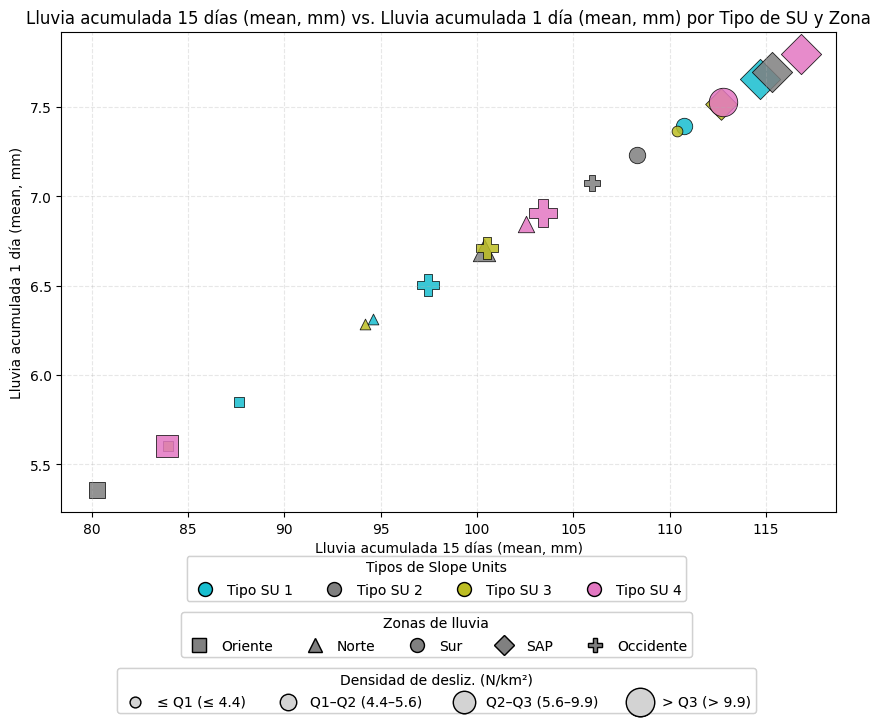

In [29]:

# Graficar largo plazo vs “corto” (1d vs 90d)
ax = graficar_dispersion_su(
    df=df_lp,
    x_col='acum15d_mean_prom',   # eje X: 15 días
    y_col='acum1d_mean_prom',    # eje Y: 1 día
    title=f"{col_pretty['acum15d_mean_prom']} vs. {col_pretty['acum1d_mean_prom']} por Tipo de SU y Zona",
    savepath=False,
    size_metric='dens_mm_km2',   # si no la tienes, cambia a otra métrica o desactiva tamaños
    use_quantiles=True
)

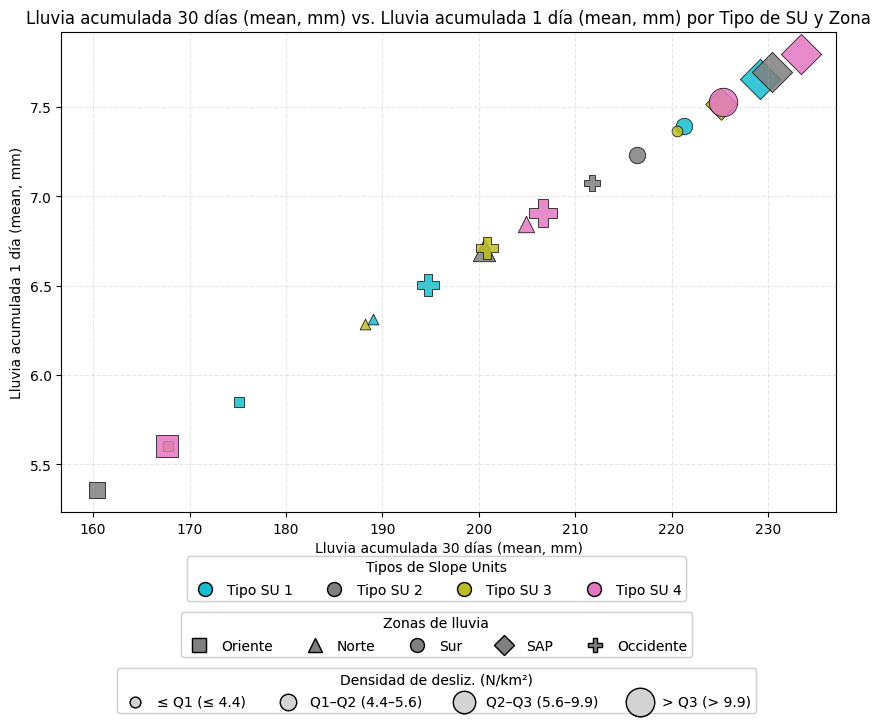

In [30]:

# Graficar largo plazo vs “corto” (1d vs 90d)
ax = graficar_dispersion_su(
    df=df_lp,
    x_col='acum30d_mean_prom',   # eje X: 30 días
    y_col='acum1d_mean_prom',    # eje Y: 1 día
    title=f"{col_pretty['acum30d_mean_prom']} vs. {col_pretty['acum1d_mean_prom']} por Tipo de SU y Zona",
    savepath=False,
    size_metric='dens_mm_km2',   # si no la tienes, cambia a otra métrica o desactiva tamaños
    use_quantiles=True
)

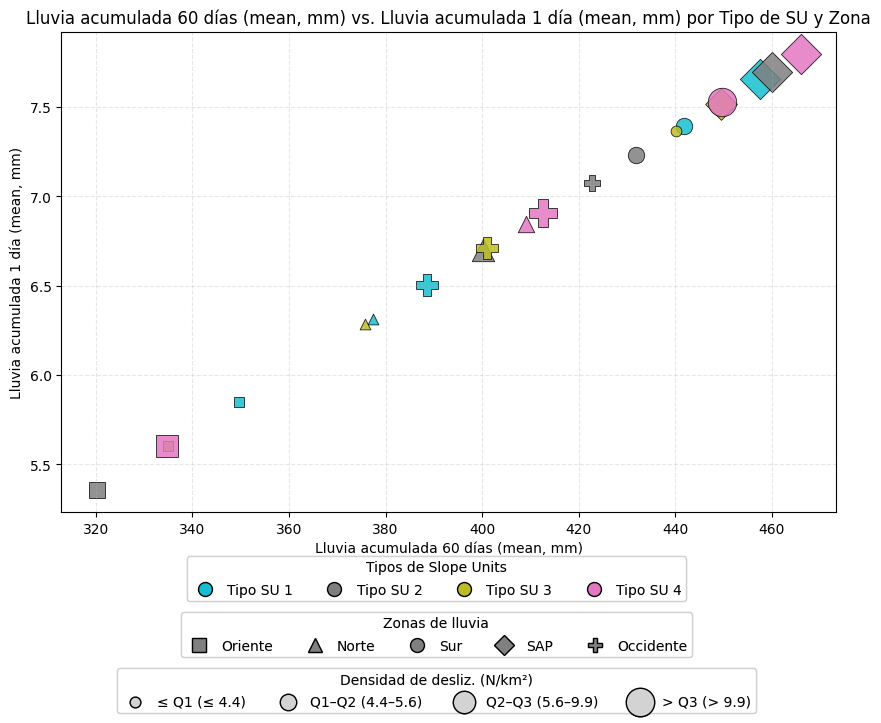

In [31]:
# Graficar largo plazo vs “corto” (1d vs 90d)
ax = graficar_dispersion_su(
    df=df_lp,
    x_col='acum60d_mean_prom',   # eje X: 60 días
    y_col='acum1d_mean_prom',    # eje Y: 1 día
    title=f"{col_pretty['acum60d_mean_prom']} vs. {col_pretty['acum1d_mean_prom']} por Tipo de SU y Zona",
    savepath=False,
    size_metric='dens_mm_km2',   # si no la tienes, cambia a otra métrica o desactiva tamaños
    use_quantiles=True
)

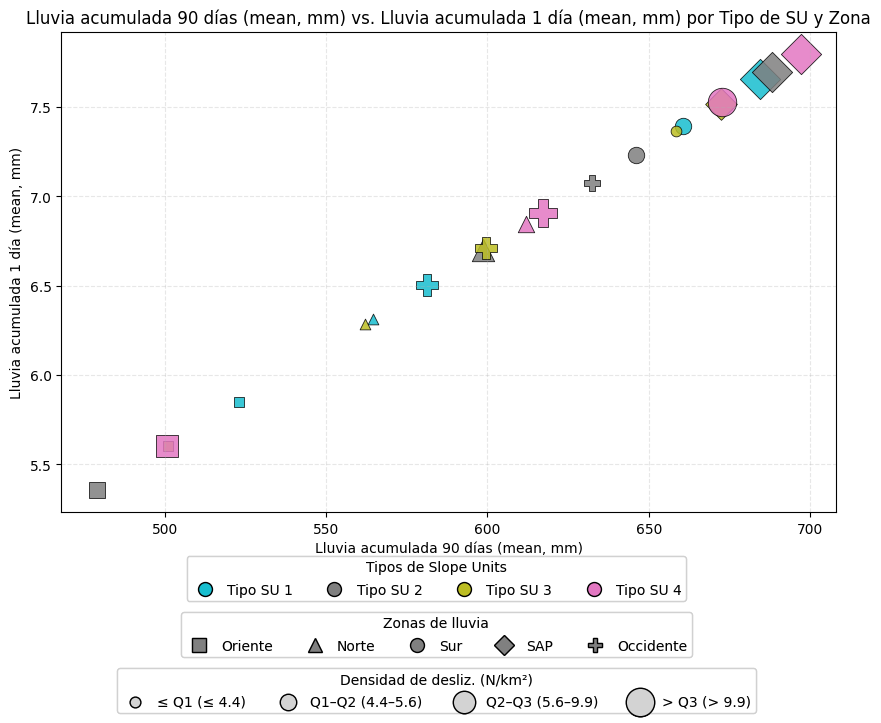

In [32]:
# Graficar largo plazo vs “corto” (1d vs 90d)
ax = graficar_dispersion_su(
    df=df_lp,
    x_col='acum90d_mean_prom',   # eje X: 90 días
    y_col='acum1d_mean_prom',    # eje Y: 1 día
    title=f"{col_pretty['acum90d_mean_prom']} vs. {col_pretty['acum1d_mean_prom']} por Tipo de SU y Zona",
    savepath=False,
    size_metric='dens_mm_km2',   # si no la tienes, cambia a otra métrica o desactiva tamaños
    use_quantiles=True
)

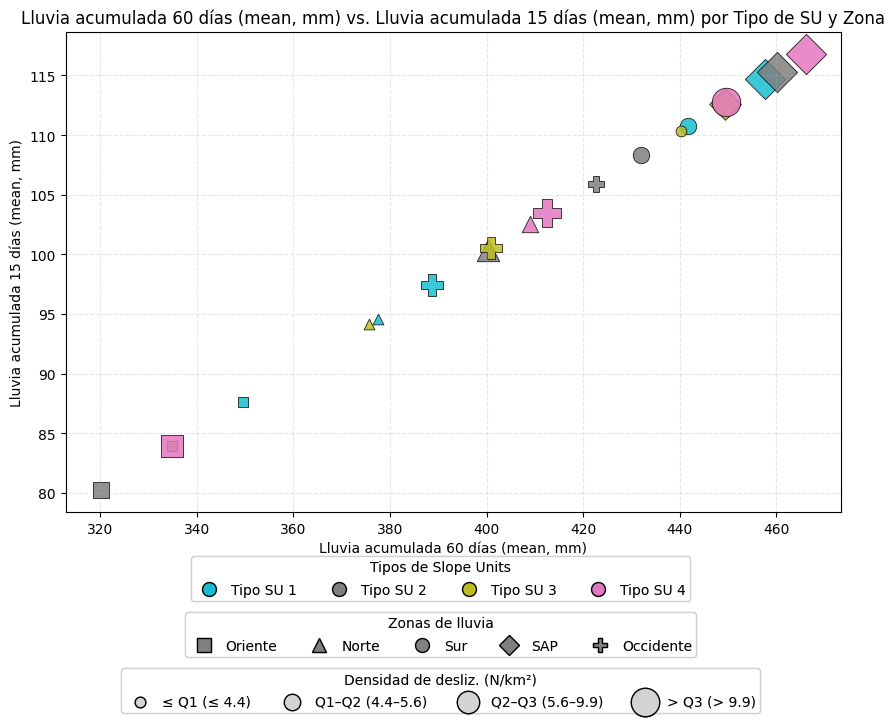

In [33]:
# Graficar largo plazo vs “corto” (1d vs 90d)
ax = graficar_dispersion_su(
    df=df_lp,
    x_col='acum60d_mean_prom',   # eje X: 60 días
    y_col='acum15d_mean_prom',    # eje Y: 15 días
    title=f"{col_pretty['acum60d_mean_prom']} vs. {col_pretty['acum15d_mean_prom']} por Tipo de SU y Zona",
    savepath=False,
    size_metric='dens_mm_km2',   # si no la tienes, cambia a otra métrica o desactiva tamaños
    use_quantiles=True
)

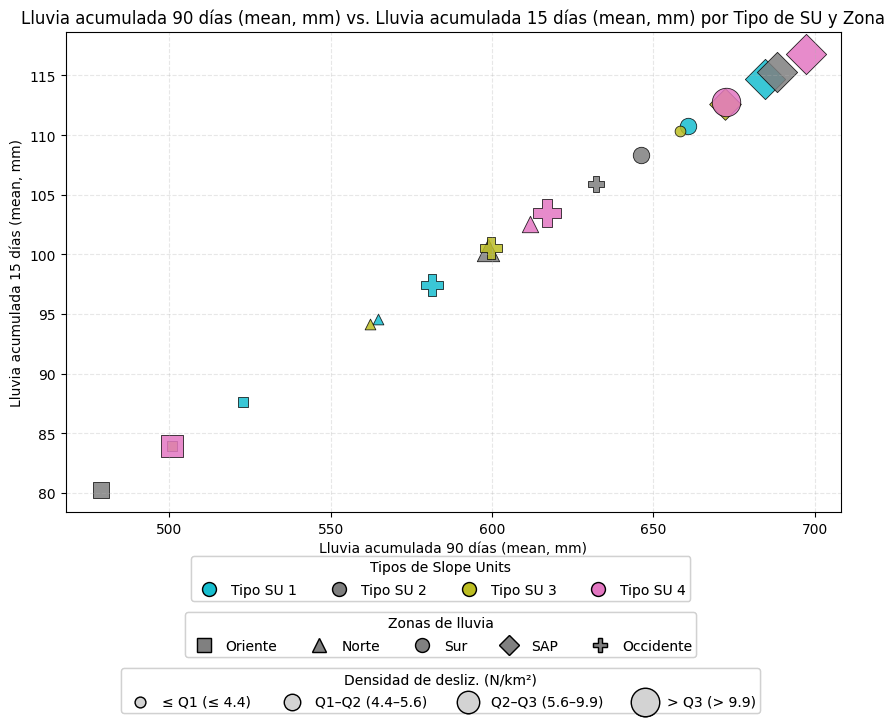

In [34]:
# Graficar largo plazo vs “corto” (1d vs 90d)
ax = graficar_dispersion_su(
    df=df_lp,
    x_col='acum90d_mean_prom',   # eje X: 90 días
    y_col='acum15d_mean_prom',    # eje Y: 15 días
    title=f"{col_pretty['acum90d_mean_prom']} vs. {col_pretty['acum15d_mean_prom']} por Tipo de SU y Zona",
    savepath=False,
    size_metric='dens_mm_km2',   # si no la tienes, cambia a otra métrica o desactiva tamaños
    use_quantiles=True
)

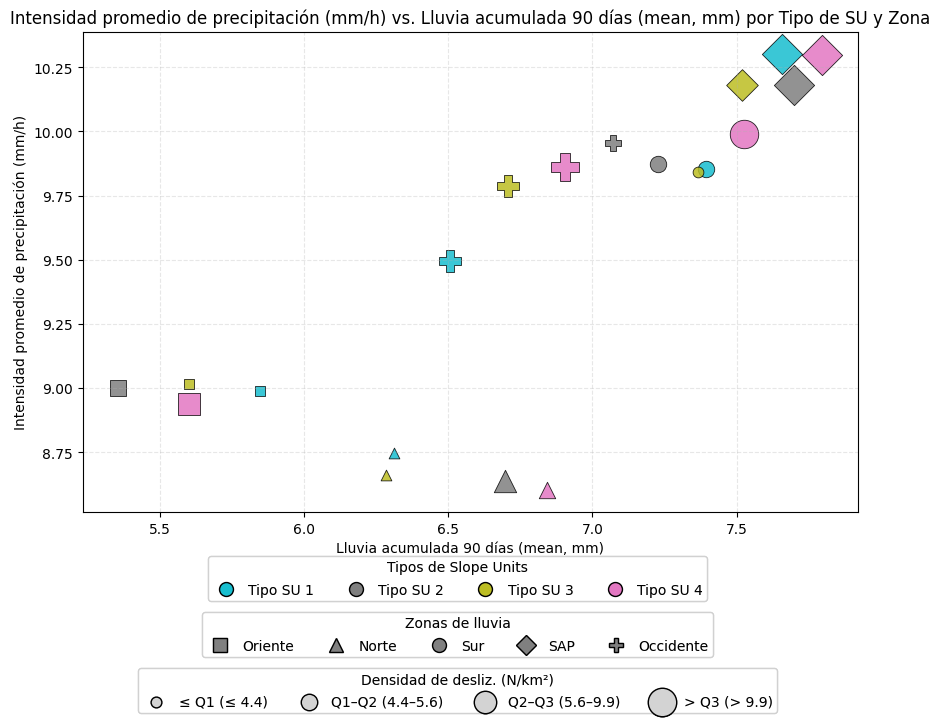

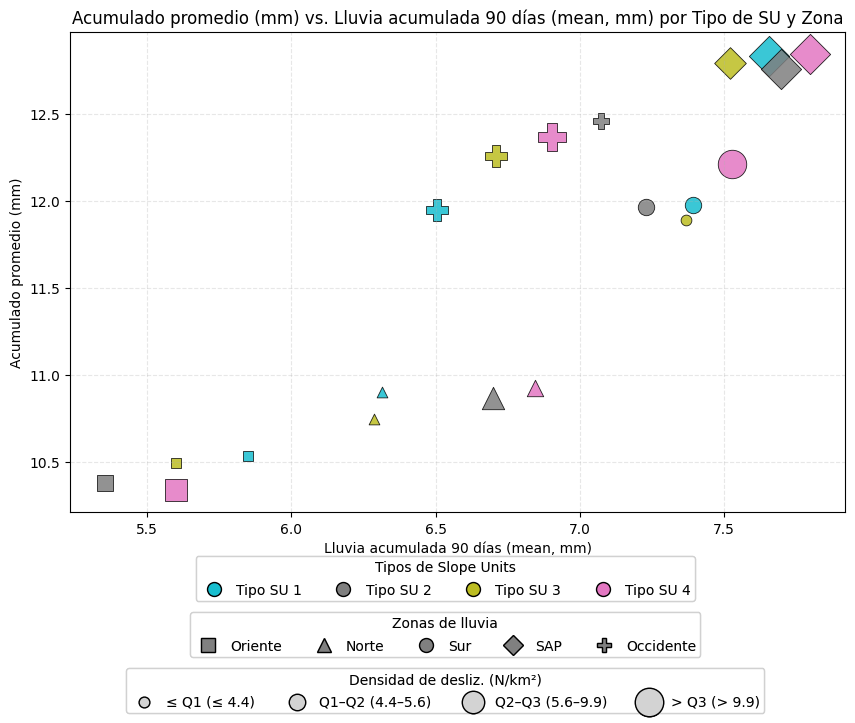

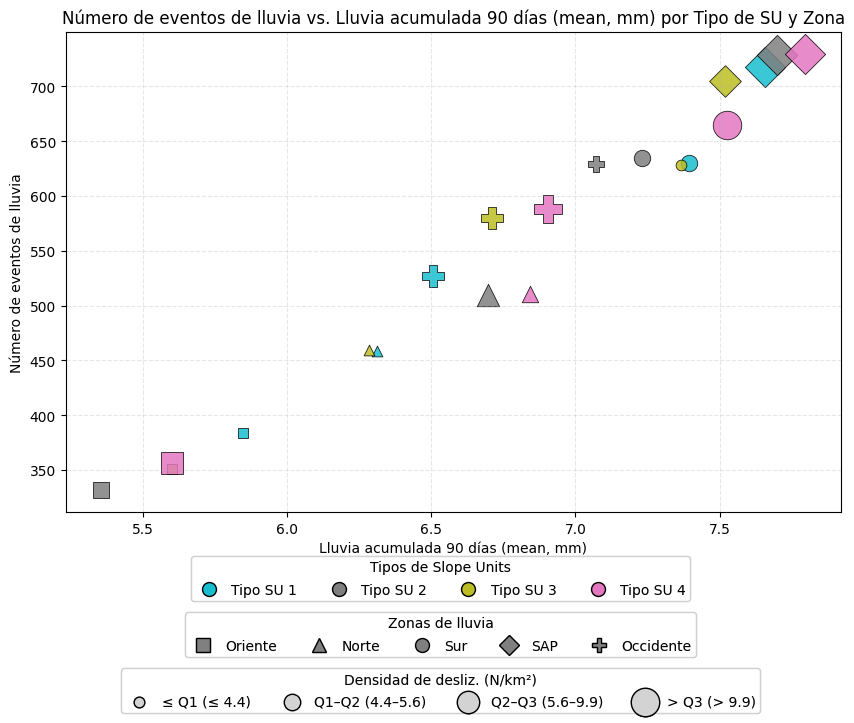

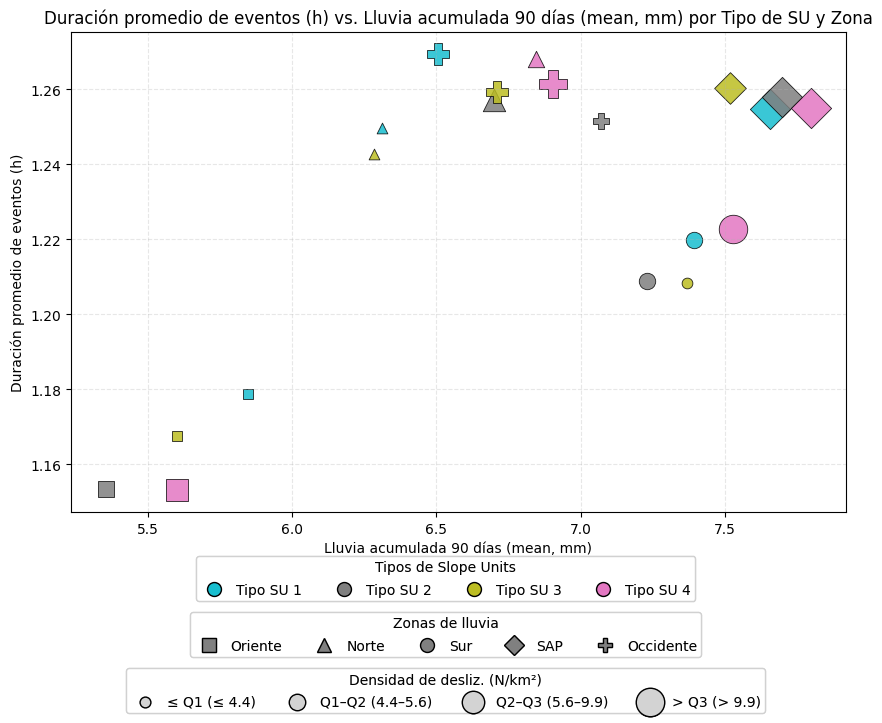

In [36]:
# ========= 5) Pares de comparación y gráficas =========
# Añadir etiqueta legible para el nuevo indicador
col_pretty.update({
    'acum1d_mean_prom': 'Lluvia acumulada 90 días (mean, mm)'  # <-- deja tu etiqueta tal como la quieres mostrar
})

pares_1d = [
    ('acum1d_mean_prom', 'intensidad_promedio'),
    ('acum1d_mean_prom', 'acumulado_promedio'),
    ('acum1d_mean_prom', 'num_eventos'),
    ('acum1d_mean_prom', 'duracion_promedio'),
]

for x_col, y_col in pares_1d:
    titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU y Zona"
    graficar_dispersion_su(
        df_lp,
        x_col=x_col,
        y_col=y_col,
        title=titulo,
        savepath=False,             # pon una ruta si quieres exportar
        size_metric='dens_mm_km2',  # seguimos usando la densidad de MM para tamaño
        use_quantiles=True          # bins automáticos por cuantiles
    )

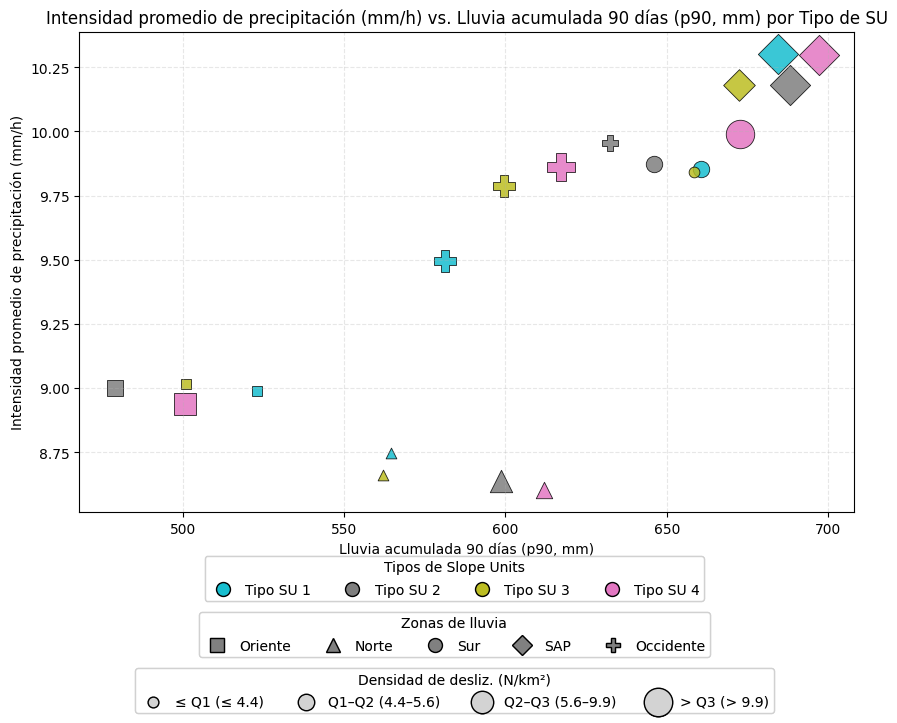

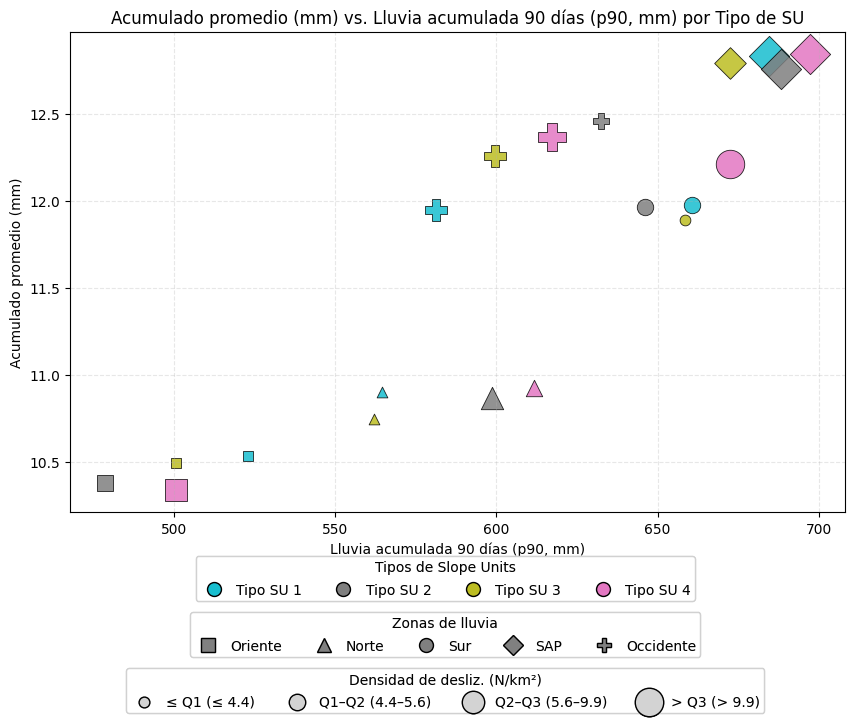

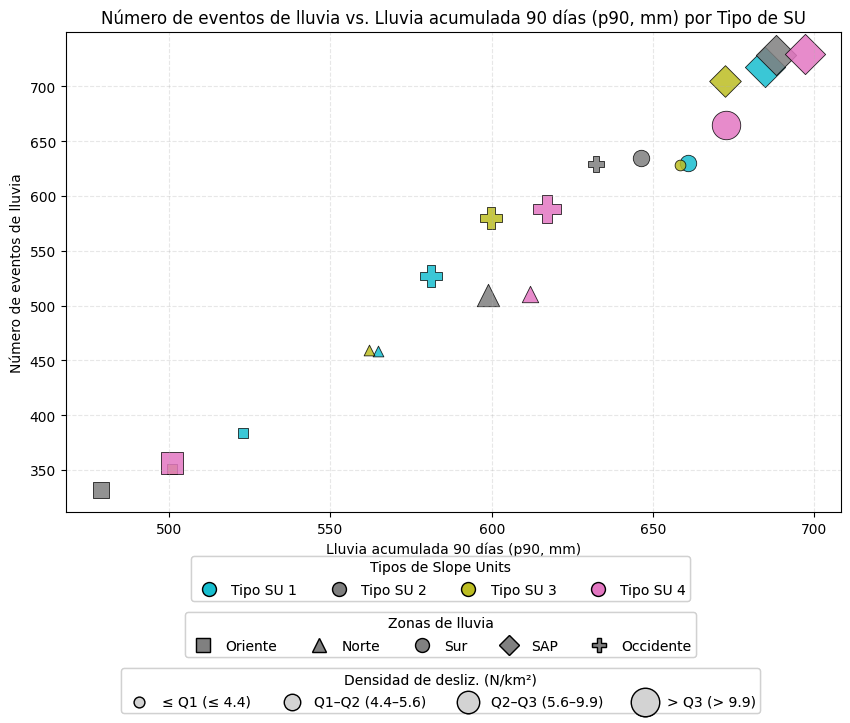

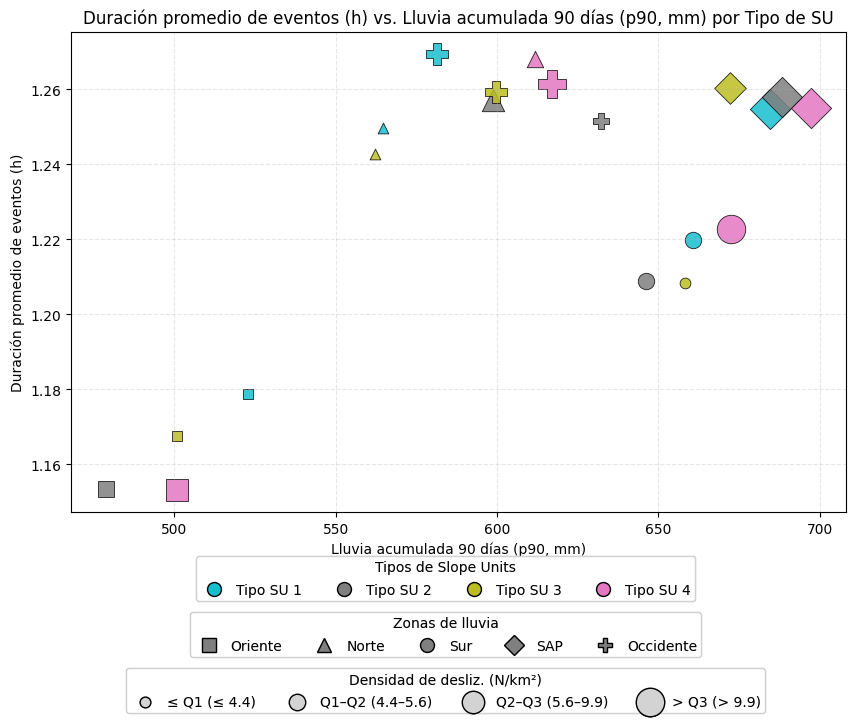

In [9]:
# ========= 5) Pares de comparación y gráficas =========
# Añadir etiqueta legible para el nuevo indicador
col_pretty.update({
    'acum1d_mean_prom': 'Lluvia acumulada 90 días (p90, mm)'
})

pares_1d = [
    ('acum1d_mean_prom', 'intensidad_promedio'),
    ('acum1d_mean_prom', 'acumulado_promedio'),
    ('acum1d_mean_prom', 'num_eventos'),
    ('acum1d_mean_prom', 'duracion_promedio'),
]

for x_col, y_col in pares_1d:
    titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU"
    graficar_dispersion_su(
        df_plot_1d,
        x_col=x_col,
        y_col=y_col,
        title=titulo,
        savepath=False,             # pon una ruta si quieres exportar
        size_metric='dens_mm_km2',  # seguimos usando la densidad de MM para tamaño
        use_quantiles=True
    )


### **GRAFICO DE DISPERSIÓN CON LA GEOLOGÍA**

#### **MAPA GEOLÓGICO**

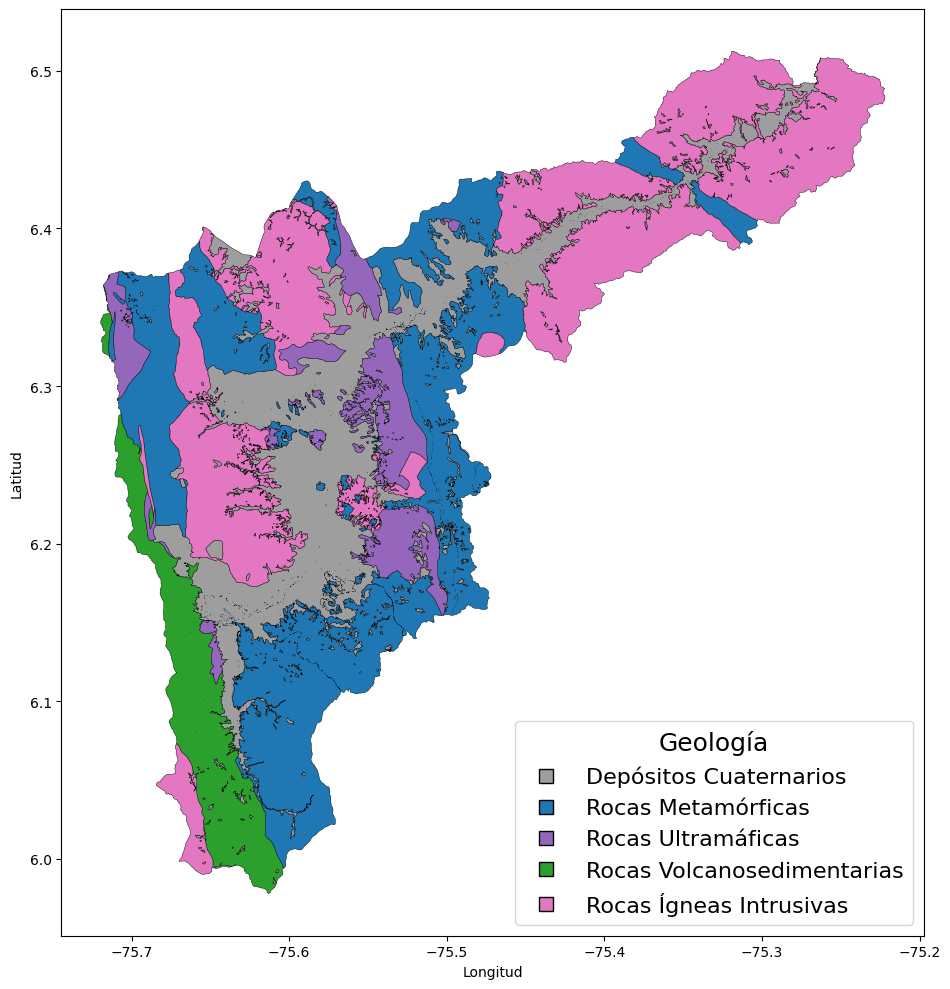

Puntos antes: 5759 | Puntos dentro de geología: 5744


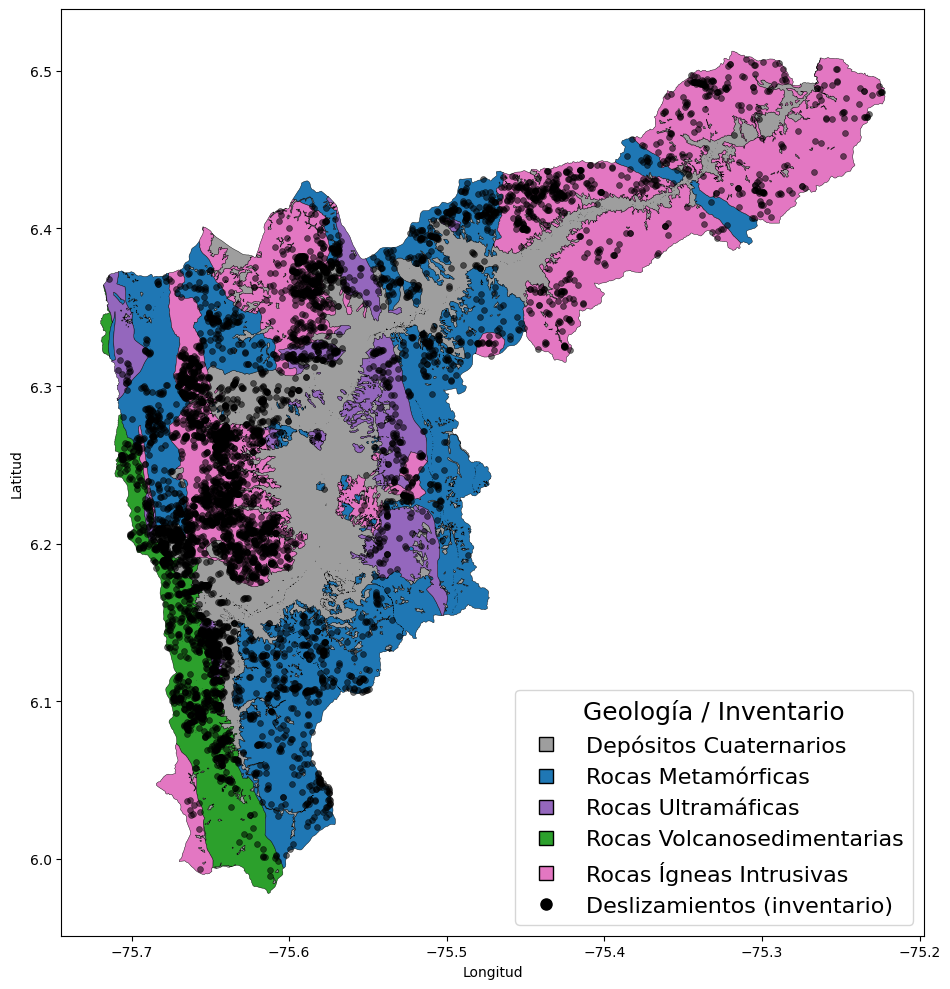

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Rutas ---
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"

# --- 1) Cargar geología ---
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia"] = geo["Geologia"].astype("category")

# (Opcional pero recomendado para escala/norte correctos)
# geo = geo.to_crs(32618)  # UTM 18N Valle de Aburrá

# --- 2) Cargar inventario de deslizamientos ---
inv = gpd.read_file(inv_path)

# Si el inventario no tiene CRS, asumimos el mismo que la geología (ajústalo si sabes el EPSG exacto del inventario)
if inv.crs is None and geo.crs is not None:
    inv.set_crs(geo.crs, inplace=True)

# Reproyectar al CRS de geología si difieren
if geo.crs is not None and inv.crs is not None and inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2.b) QUEDARSE SOLO CON LOS PUNTOS DENTRO DE GEOLOGÍA ---
inv_before = len(inv)

# Asegura geometrías válidas (evita topologías raras)
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # o usa shapely.make_valid si tienes Shapely 2.x

# Recortar (clip) los puntos del inventario al polígono de geología
inv = gpd.clip(inv, geo_valid)

print(f"Puntos antes: {inv_before} | Puntos dentro de geología: {len(inv)}")
# Si por alguna razón el inventario viene en polígonos/líneas y quieres puntos:
# inv = inv.copy()
# inv["geometry"] = inv.geometry.centroid

# --- 3) Graficar ---
import unicodedata
from matplotlib.lines import Line2D

# --- Normalizador (sin tildes, minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Mapa de colores por categoría (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}


# Mejor: que 'Geologia' NO sea categoría durante el mapeo
geo["Geologia"] = geo["Geologia"].astype(str)

geo["Geologia_norm"] = geo["Geologia"].apply(_norm)
s = geo["Geologia_norm"].map(color_map_norm)

geo["fillcolor"] = s.astype("object").fillna("#cccccc")
# --- Graficar con colores fijos ---
fig, ax = plt.subplots(figsize=(10, 10))

# Geología
geo.plot(ax=ax, facecolor=geo["fillcolor"], edgecolor="black", linewidth=0.3)

# Inventario (como ya lo tienes)
inv.plot(ax=ax, marker="o", color="black",
         edgecolor="black", linewidth=0.5,
         markersize=18, alpha=0.55, zorder=5)

#ax.set_title("Mapa de Unidades Geológicas + Inventario de Deslizamientos", fontsize=14)
ax.set_xlabel("Longitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "X (m)")
ax.set_ylabel("Latitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "Y (m)")
ax.set_aspect("equal")

# --- Leyenda manual en orden deseado + deslizamientos ---
orden_legenda = [
    ("Depósitos Cuaternarios",      "#9e9e9e"),
    ("Rocas Metamórficas",          "#1f77b4"),
    ("Rocas Ultramáficas",          "#9467bd"),
    ("Rocas Volcanosedimentarias",  "#2ca02c"),
    ("Rocas Ígneas Intrusivas",     "#e377c2"),
]

handles_geo = [Line2D([0], [0], marker='s', linestyle='',
                      markerfacecolor=c, markeredgecolor='black',
                      markersize=10, label=lab) for lab, c in orden_legenda]

handle_inv = Line2D([0], [0], marker='o', linestyle='', markerfacecolor='black',
                    markeredgecolor='black', markersize=8, label='Deslizamientos (inventario)')

labels_geo = [lab for lab, _ in orden_legenda]
labels = labels_geo + ["Deslizamientos (inventario)"]

ax.legend(handles=handles_geo + [handle_inv],
          labels=labels,
          title="Geología / Inventario",
          loc="lower right", frameon=True, fontsize=16, title_fontsize=18)



plt.tight_layout()
plt.show()

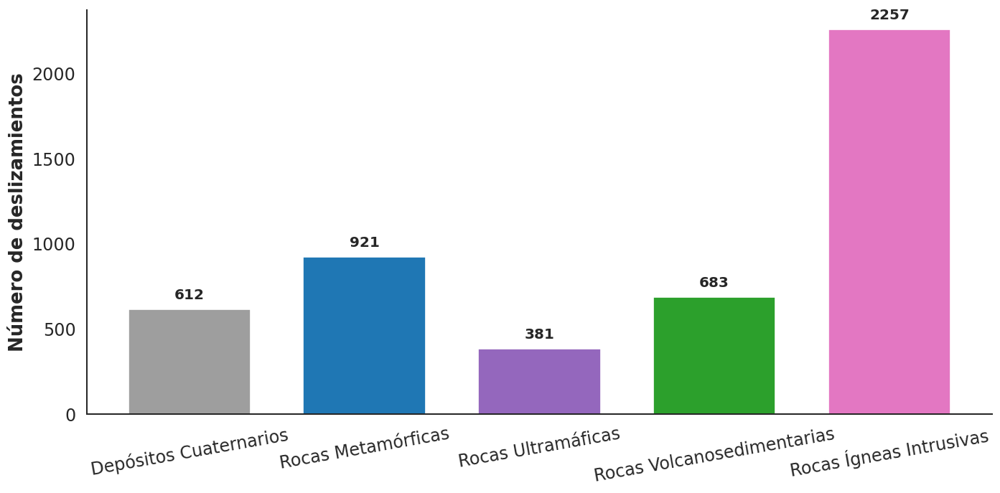

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# --- Normalizador (quita tildes y pasa a minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Colores fijos por unidad (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}

# --- Etiquetas “bonitas” y orden deseado en la gráfica ---
orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]
# Mapa etiqueta bonita -> color
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# ---------- Asegurar CRS (si hiciera falta) ----------
# geo = geo.to_crs(32618)                   # recomendado para V. de Aburrá (m)
# inv = inv.to_crs(geo.crs)                 # igualar CRS

# ---------- Clip/sjoin: quedarnos con puntos dentro de geología ----------
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # “make valid” simple

# Une puntos con polígonos contenedores
inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# ---------- Agregar conteos por unidad ----------
# Normalizamos para empatar con el dict de colores
inv_in["Geologia_norm"] = inv_in["Geologia"].apply(_norm)

# Creamos etiqueta bonita a partir de la normalizada
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

# Conteos (incluimos todas las clases del orden, aunque tengan 0)
counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0)
df_counts = counts.reset_index()
df_counts.columns = ["Unidad", "Conteo"]
df_counts["Color"] = df_counts["Unidad"].map(label_to_color)

# ---------- Graficar (formato similar a tu ejemplo) ----------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_counts["Unidad"],
    df_counts["Conteo"],
    color=df_counts["Color"],
    width=0.7
)

# Etiquetas encima de cada barra (conteo entero)
for bar, n in zip(bars, df_counts["Conteo"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(df_counts["Conteo"])*0.02 if df_counts["Conteo"].max() > 0 else 0.2,
        f'{int(n)}',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Ejes y estilo
ax.set_ylabel('Número de deslizamientos', weight='bold')
ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.grid(False)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()


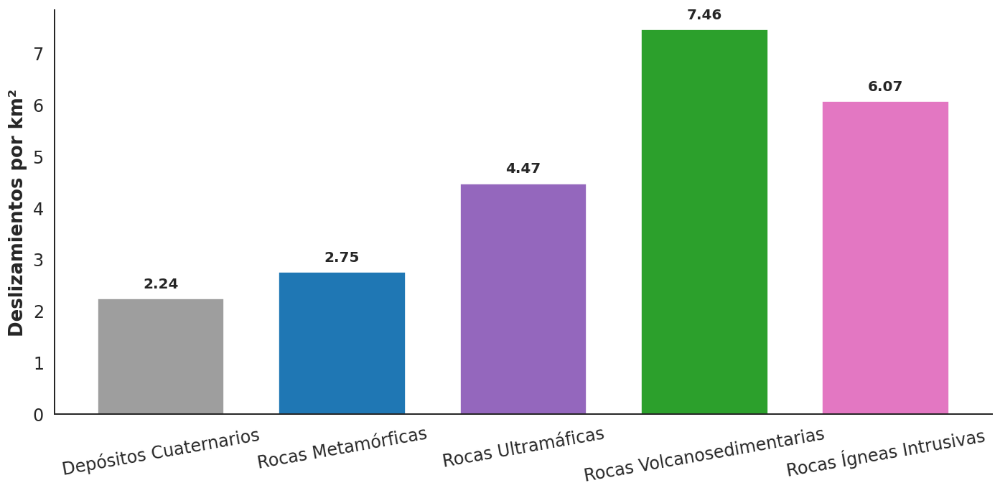

In [4]:
from shapely.ops import unary_union
from matplotlib.ticker import ScalarFormatter

# --- 0) parámetros y utilidades (mismos del bloque previo) ---
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, unicodedata
from matplotlib.ticker import ScalarFormatter
import geopandas as gpd

def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- 1) Asegurar CRS en metros (¡clave para el área!) ---
# Si estás en grados, proyecta a UTM 18N (o a 3116 si usas MAGNA-SIRGAS oficial)
if geo.crs is None or geo.crs.is_geographic:
    geo = geo.to_crs(32618)   # <-- cámbialo a 3116 si corresponde
if inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2) Puntos dentro de geología (para que el conteo y la densidad coincidan) ---
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # fix geometrías simples

inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# Etiquetas normalizadas y “bonitas”
inv_in["Geologia_norm"]  = inv_in["Geologia"].apply(_norm)
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

# Conteos por unidad (incluye las que no aparezcan → 0)
df_counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0).reset_index()
df_counts.columns = ["Unidad", "Conteo"]
df_counts["Color"] = df_counts["Unidad"].map(label_to_color)

# --- 3) Área por unidad (disolver por etiqueta bonita y medir km²) ---
geo_valid["Geologia_norm"]  = geo_valid["Geologia"].apply(_norm)
geo_valid["Geologia_label"] = geo_valid["Geologia_norm"].map(norm_to_label)

geo_diss = geo_valid.dissolve(by="Geologia_label", as_index=True, aggfunc="sum", dropna=False)
geo_diss["area_km2"] = geo_diss.geometry.area / 1e6  # m² → km²

df_area = geo_diss[["area_km2"]].reindex(orden_labels)

# --- 4) Densidad = Conteo / Área_km² ---
df_den = df_counts.set_index("Unidad").join(df_area, how="left")
df_den["area_km2"] = df_den["area_km2"].replace(0, np.nan)  # evitar división por 0
df_den["Densidad"]  = df_den["Conteo"] / df_den["area_km2"]

# --- 5) Graficar barras de densidad con los mismos colores ---
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(df_den.index, df_den["Densidad"], color=df_den["Color"], width=0.7)

# Etiquetas encima (ajusta offset)
ymax = (df_den["Densidad"].max() or 0) * 0.02
for bar, d in zip(bars, df_den["Densidad"]):
    if pd.notna(d):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (ymax if ymax>0 else 0.05),
                f'{d:.2f}', ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_ylabel('Deslizamientos por km²', weight='bold'); ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white'); ax.grid(False); ax.tick_params(axis='x', rotation=10)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='plain', useMathText=True)

plt.tight_layout(); plt.show()

# (Opcional) inspección rápida:
# print(df_den[["Conteo","area_km2","Densidad"]])



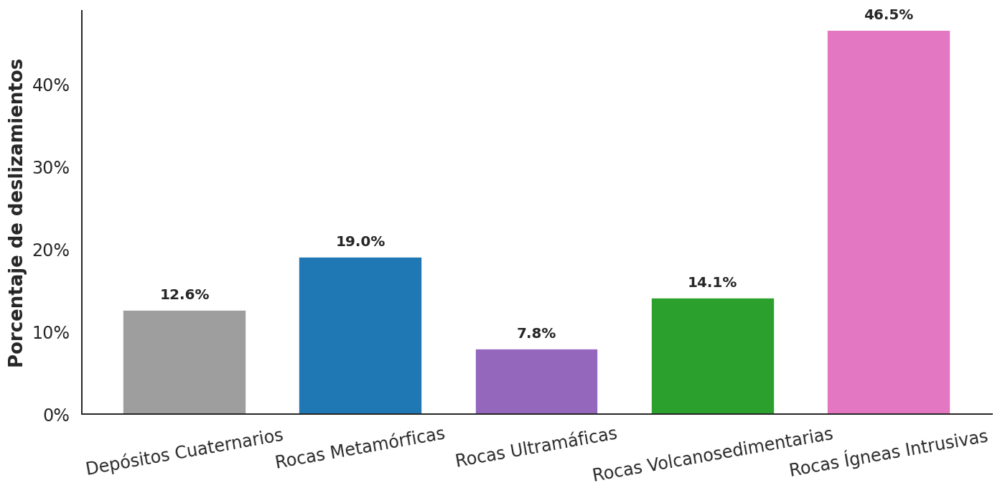

In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
from matplotlib.ticker import PercentFormatter

# --- Utilidades (usa las que ya tengas) ---
def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",  # gris
    "Rocas Metamórficas":         "#1f77b4",  # azul
    "Rocas Ultramáficas":         "#9467bd",  # morado
    "Rocas Volcanosedimentarias": "#2ca02c",  # verde
    "Rocas Ígneas Intrusivas":    "#e377c2",  # rosado
}

# --- 1) Asegurar CRS compatible para el join espacial (no hace falta metros para porcentajes) ---
if (geo.crs is not None) and (inv.crs != geo.crs):
    inv = inv.to_crs(geo.crs)

# --- 2) Puntos dentro del área de estudio (geología) ---
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)

inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# --- 3) Conteo por unidad y porcentaje sobre el total (dentro del área de estudio) ---
inv_in["Geologia_norm"]  = inv_in["Geologia"].apply(_norm)
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0)
total  = counts.sum()

# Evitar división por cero si no hay puntos dentro
pct = (counts / total) if total > 0 else counts.astype(float)

df_pct = pd.DataFrame({
    "Unidad": orden_labels,
    "Porcentaje": pct.values,
    "Color": [label_to_color[u] for u in orden_labels]
})

# --- 4) Gráfico de barras (mismo estilo que tu ejemplo) ---
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_pct["Unidad"],
    df_pct["Porcentaje"],
    color=df_pct["Color"],
    width=0.7
)

# Etiquetas encima de cada barra (en %)
for bar, p in zip(bars, df_pct["Porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        (bar.get_height() if total>0 else 0) + 0.01,
        f'{(p*100 if total>0 else 0):.1f}%',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Eje Y como porcentaje
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Etiquetas y estilo
ax.set_ylabel('Porcentaje de deslizamientos', weight='bold')
ax.set_xlabel('')
ax.spines[['right','top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.grid(False)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

# (Opcional) Verificación rápida en consola
# print(pd.DataFrame({"Conteo": counts, "Porcentaje (%)": (pct*100 if total>0 else 0)}))


In [13]:
geo["Geologia"].unique()

['DepÃ³sitos Cuaternarios', 'Rocas Volcanosedimentarias', 'Rocas MetamÃ³rficas', 'Rocas UltramÃ¡ficas', 'Rocas Ãgneas Intrusivas']
Categories (5, object): ['DepÃ³sitos Cuaternarios', 'Rocas MetamÃ³rficas', 'Rocas UltramÃ¡ficas', 'Rocas Volcanosedimentarias', 'Rocas Ãgneas Intrusivas']

In [7]:
su_enriquecida

,index,slope_mean,aspect_maj,flowacum_m,tpi_mean,ugs_majo,twi_mean,mm,area,curvatura,...,su_idx,zona,n_mm,si_no,geometry,num_eventos,intensidad_promedio,duracion_promedio,acumulado_promedio,intensidad_maxima_promedio
0,0,22.804145,2,49.325243,5.749512,6,4.716041,0.0,0.527013,4,...,0,2.0,0,0,"POLYGON ((471039.012 716696.479, 471051.752 71...",718.0,8.482752,1.373259,11.833970,9.223467
1,1,36.675028,7,30.864297,-0.155518,6,4.217924,0.0,1.543644,4,...,1,4.0,0,0,"POLYGON ((426909.789 684773.913, 426912.606 68...",717.0,10.011607,1.271967,12.634850,10.677420
2,2,30.573870,6,22.739464,1.015308,6,4.032604,0.0,0.655683,4,...,2,2.0,0,0,"POLYGON ((448641.643 706432.470, 448635.001 70...",392.0,8.218615,1.211735,10.054645,8.599607
3,3,17.069585,4,678.638710,-3.777324,2,5.146215,0.0,1.168754,2,...,3,2.0,0,0,"POLYGON ((468779.019 717441.915, 468764.028 71...",706.0,8.912487,1.400850,12.464027,9.694011
4,4,21.984775,6,22.326754,-2.051514,6,4.308762,0.0,1.136601,2,...,4,2.0,0,0,"POLYGON ((461882.409 715160.776, 461877.412 71...",624.0,8.890285,1.314103,11.734026,9.555319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57519,57519,12.720728,8,18.038991,0.000000,3,4.830714,0.0,1.076583,4,...,57519,1.0,0,0,"POLYGON ((445853.947 686380.793, 446000.845 68...",437.0,8.522143,1.192220,10.249857,8.965652
57520,57520,28.823678,8,1004.843750,0.000000,6,4.582747,0.0,1.113334,2,...,57520,2.0,0,0,"POLYGON ((454075.849 704903.202, 454028.852 70...",413.0,8.091298,1.215496,9.749623,8.354326
57521,57521,25.816091,7,988.331959,0.000000,6,4.673232,0.0,1.182252,2,...,57521,5.0,0,0,"POLYGON ((425668.356 700305.639, 425608.399 70...",630.0,9.638761,1.244444,11.858598,10.118825
57522,57522,39.192384,7,37.351421,0.000000,6,4.629470,0.0,1.922818,4,...,57522,5.0,0,0,"POLYGON ((426839.945 701751.693, 426834.948 70...",481.0,8.615664,1.197505,10.414240,9.028164


In [3]:
# ==============================================================
# Agregar por (Geología, Zona) usando SU ya enriquecidas
# ==============================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import unicodedata

# --- Utilidad: normalizar nombres de geología (sin tildes, minúsculas) ---
def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Diccionario de etiquetas "bonitas" y orden opcional ---
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}
orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

# --- Colores fijos (los mismos del mapa) ---
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- Variables de lluvia que ya tienes en su_enriquecida ---
var_names = [
    'num_eventos',
    'intensidad_promedio',
    'duracion_promedio',
    'acumulado_promedio',
    'intensidad_maxima_promedio'
]

# --- Rutas ---
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Landslides_VdeA_13jun2025/Landslides_VdeA_13jun2025.shp"

# --- 1) Cargar geología ---
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
# 1) Asegurar CRS proyectado (metros) para áreas
su_proj, crs_orig = _ensure_projected(su_enriquecida)
geo_proj = geo.to_crs(su_proj.crs)

# 2) Preparar columnas en SU
su = su_proj.copy()
if 'su_idx' not in su.columns:
    su['su_idx'] = su.index

# n_mm a número
su['n_mm'] = pd.to_numeric(su['n_mm'], errors='coerce').fillna(0)

# zona robusta a entero
su['zona_num'] = pd.to_numeric(su['zona'], errors='coerce')
su = su.dropna(subset=['zona_num']).copy()
su['zona'] = su['zona_num'].round().astype(int)

# área de SU (para repartir n_mm por fracción de área)
su['area_su'] = su.geometry.area

# 3) Geología: normalizar nombres y “arreglar” geometrías
geo_fix = geo_proj.copy()
geo_fix['Geologia_norm']  = geo_fix['Geologia'].apply(_norm)
geo_fix['Geologia_label'] = geo_fix['Geologia_norm'].map(norm_to_label).fillna(geo_fix['Geologia'].astype(str))
geo_fix['geometry'] = geo_fix['geometry'].buffer(0)

# 4) Intersección SU ∩ Geología
cols_keep_su  = ['su_idx', 'zona', 'n_mm', 'area_su'] + var_names + ['geometry']
cols_keep_geo = ['Geologia_label', 'geometry']
inter = gpd.overlay(su[cols_keep_su], geo_fix[cols_keep_geo], how='intersection')

if inter.empty:
    raise RuntimeError("La intersección SU∩Geología salió vacía. Revisa CRS y coberturas.")

# Pesos de área (m²) y fracción respecto al SU original
inter['area_w']  = inter.geometry.area
inter['frac_su'] = inter['area_w'] / inter['area_su'].replace({0: np.nan})

# 1) columnas auxiliares
inter['nmm_part'] = inter['n_mm'] * inter['frac_su']  # reparto proporcional por área

for v in var_names:
    inter[f'{v}_w'] = inter[v] * inter['area_w']      # peso areal para promedios

# 2) agregación por (Geología, Zona)
agg_dict = {
    'area_m2':   ('area_w', 'sum'),
    'n_mm_total':('nmm_part', 'sum'),
}

# añadimos las sumas ponderadas de cada variable
for v in var_names:
    agg_dict[f'{v}_w_sum'] = (f'{v}_w', 'sum')

df_geo_zone = (inter
               .groupby(['Geologia_label','zona'], as_index=False)
               .agg(**agg_dict))

# 3) promedios ponderados por área
df_geo_zone['area_km2'] = df_geo_zone['area_m2'] / 1e6
for v in var_names:
    df_geo_zone[v] = df_geo_zone[f'{v}_w_sum'] / df_geo_zone['area_m2'].replace({0: np.nan})

# 4) limpiar columnas auxiliares si no las quieres
drop_aux = [f'{v}_w_sum' for v in var_names]
df_geo_zone = df_geo_zone.drop(columns=drop_aux)

# 5) densidad y proporción global (si las usas)
df_geo_zone['dens_mm_km2'] = df_geo_zone['n_mm_total'] / df_geo_zone['area_km2'].replace({0: np.nan})
total_mm = df_geo_zone['n_mm_total'].sum()
df_geo_zone['p_global'] = np.where(total_mm>0, df_geo_zone['n_mm_total']/total_mm, np.nan)

# Ordenar por etiqueta y zona
if len(orden_labels):
    df_geo_zone['Geologia_label'] = pd.Categorical(df_geo_zone['Geologia_label'],
                                                   categories=orden_labels, ordered=True)
    df_geo_zone = df_geo_zone.sort_values(['Geologia_label', 'zona']).reset_index(drop=True)

# Añadir color para gráficas
df_geo_zone['color'] = df_geo_zone['Geologia_label'].map(label_to_color).fillna('#cccccc')

print(df_geo_zone.head())


TypeError: Cannot setitem on a Categorical with a new category (#cccccc), set the categories first

In [4]:
df_geo_zone

,Geologia_label,zona,area_m2,n_mm_total,area_km2,num_eventos,intensidad_promedio,duracion_promedio,acumulado_promedio,intensidad_maxima_promedio,dens_mm_km2,p_global
0,Depósitos Cuaternarios,1,1.344792e+07,13.443053,13.447915,388.121411,9.101595,1.190264,10.769418,9.456464,0.999638,0.002375
1,Depósitos Cuaternarios,2,7.089436e+07,218.855692,70.894357,441.253347,8.812821,1.248318,10.981660,9.300055,3.087068,0.038669
2,Depósitos Cuaternarios,3,2.968200e+07,235.090707,29.682004,626.831994,9.876532,1.230806,12.089995,10.423909,7.920311,0.041538
3,Depósitos Cuaternarios,4,4.590551e+06,185.007154,4.590551,729.439910,10.328022,1.252914,12.764597,10.957785,40.301728,0.032689
4,Depósitos Cuaternarios,5,1.754699e+07,106.559854,17.546995,508.996119,9.381101,1.277013,11.865094,9.943584,6.072826,0.018828
5,Rocas Metamórficas,1,3.727067e+07,29.965283,37.270674,389.726888,8.965450,1.170138,10.441720,9.279755,0.803991,0.005295
6,Rocas Metamórficas,2,1.079503e+08,463.683782,107.950257,428.860114,8.679807,1.221093,10.586245,9.089952,4.295347,0.081927
7,Rocas Metamórficas,3,1.059748e+08,403.470740,105.974829,569.922578,9.651542,1.197321,11.544830,10.119224,3.807232,0.071288
8,Rocas Metamórficas,4,1.606251e+07,126.636627,16.062505,691.570206,10.039599,1.258784,12.623118,10.700846,7.883990,0.022375
9,Rocas Metamórficas,5,4.233907e+07,101.310651,42.339073,616.458259,9.837165,1.250089,12.300465,10.455492,2.392841,0.017900


KeyError: 'color'

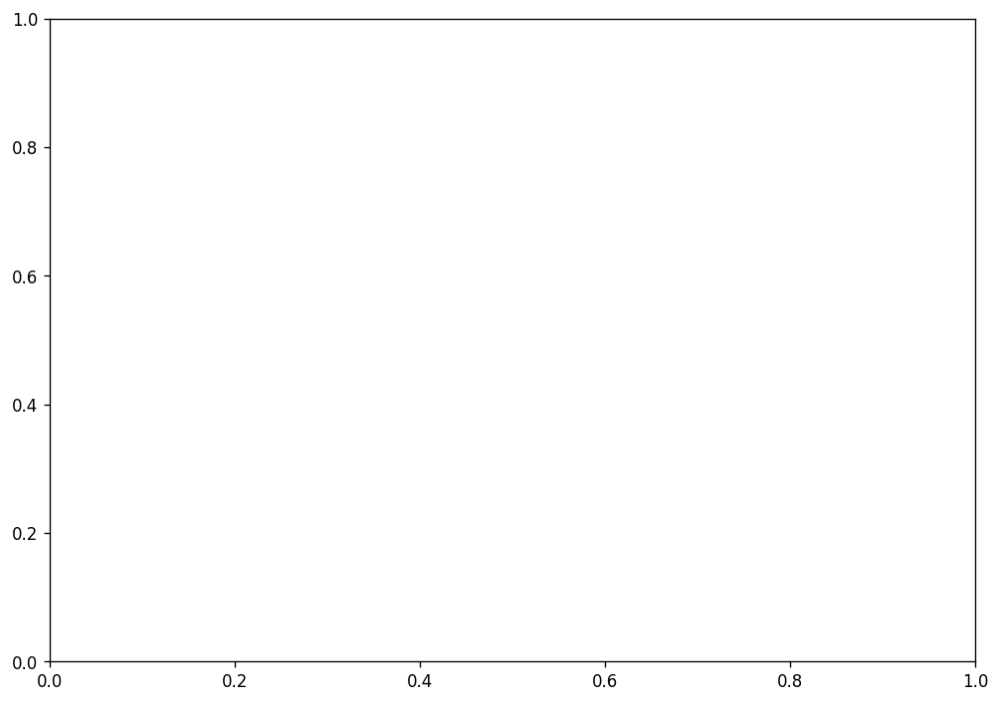

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Elegir ejes (cámbialos por los que quieras comparar)
x_col = 'acumulado_promedio'
y_col = 'intensidad_promedio'

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)

# Escalado simple de tamaños con densidad (ajusta factores a tu gusto)
size = 50 + 250 * (df_geo_zone['dens_mm_km2'] / (df_geo_zone['dens_mm_km2'].max() or 1))

sc = ax.scatter(
    df_geo_zone[x_col],
    df_geo_zone[y_col],
    s=size,
    c=df_geo_zone['color'],
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

ax.set_xlabel(x_col.replace('_',' ').title(), weight='bold')
ax.set_ylabel(y_col.replace('_',' ').title(), weight='bold')
ax.set_title('Geología vs Lluvia por Zona (tamaño = dens_mm_km2)', weight='bold')

# Leyenda de colores por geología
handles_geo = [
    mlines.Line2D([0],[0], marker='o', linestyle='', color='black',
                  markerfacecolor=label_to_color[g], markeredgecolor='black',
                  markersize=10, label=g)
    for g in orden_labels if g in df_geo_zone['Geologia_label'].unique()
]
ax.legend(handles=handles_geo, title='Geología', loc='best', frameon=True)

ax.spines[['right','top']].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()


In [7]:
# %% ================================================================
# 0) Importaciones
# ================================================================
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=UserWarning)


# %% ================================================================
# 1) Utilidad: asegurar CRS proyectado (metros) para áreas/distancias
# ================================================================
def _ensure_projected(gdf):
    """
    Si el CRS es geográfico (grados) proyecta a un CRS UTM aproximado según el cent
    roide.
    Devuelve una copia proyectada y el CRS original.
    """
    if gdf.crs is None:
        raise ValueError("El GeoDataFrame no tiene CRS definido.")

    if not gdf.crs.is_geographic:
        return gdf.copy(), gdf.crs  # ya está proyectado (metros)

    # Estimar zona UTM a partir del centroide (asume WGS84)
    centroid = gdf.to_crs(4326).geometry.unary_union.centroid
    lon = centroid.x
    lat = centroid.y
    utm_zone = int((lon + 180) // 6) + 1
    is_north = lat >= 0
    epsg = 32600 + utm_zone if is_north else 32700 + utm_zone
    return gdf.to_crs(epsg), gdf.crs


# %% ================================================================
# 2) Tu función: filtrar e interpolar NetCDF (tal cual)
# ================================================================
def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas
    en un archivo CSV y luego interpola los valores faltantes.
    """
    coords_df = pd.read_csv(coord_file)
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values

    data = xr.open_dataset(radar_file)

    mask = xr.DataArray(
        np.ones((len(data.lon), len(data.lat)), dtype=bool),
        coords=[data.lon, data.lat],
        dims=["lon", "lat"]
    )

    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False

    data_filtrado = data.where(mask, drop=True)

    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    return interpolated_ds


# %% ================================================================
# 3) Utilidades geoespaciales y de agregación
# ================================================================
def detectar_lat_lon(ds):
    """Detecta nombres de coords lat/lon y si son 1D."""
    cand_lat = ['lat', 'latitude', 'y', 'Norte']
    cand_lon = ['lon', 'longitude', 'x', 'Este']
    lat_name = next((c for c in cand_lat if c in ds.coords or c in ds.variables), None)
    lon_name = next((c for c in cand_lon if c in ds.coords or c in ds.variables), None)
    if lat_name is None or lon_name is None:
        raise ValueError("No pude detectar coordenadas de lat/lon en el NetCDF.")
    is_1d = (ds[lat_name].ndim == 1 and ds[lon_name].ndim == 1)
    return lat_name, lon_name, is_1d


def ds_a_puntos_gdf(ds, var_names, su_crs):
    """
    Convierte un Dataset (ya filtrado/interpolado) en un GeoDataFrame de puntos con
    variables var_names. Se adapta al orden de ejes (lat,lon)/(lon,lat) y a coords 1D/2D.
    """
    lat_name, lon_name, is_1d = detectar_lat_lon(ds)

    ref_var = var_names[0]
    ref_arr = np.squeeze(ds[ref_var].values)
    ref_shape = ref_arr.shape

    if is_1d:
        x = ds[lon_name].values  # lon
        y = ds[lat_name].values  # lat
        Nx, Ny = len(x), len(y)
        # Construimos SIEMPRE malla (Ny, Nx) = (lat,lon)
        LON, LAT = np.meshgrid(x, y, indexing='xy')  # -> (Ny, Nx)
        shape_yx = (Nx, Ny)  # (lon, lat)
        need_T = (ref_shape == shape_yx)
    else:
        LON = ds[lon_name].values
        LAT = ds[lat_name].values
        if ref_shape == LON.shape:
            need_T = False
        elif ref_shape == LON.T.shape:
            LON, LAT = LON.T, LAT.T
            need_T = False
        else:
            raise ValueError(
                f"No puedo alinear lon/lat 2D con la variable de referencia. "
                f"ref_shape={ref_shape}, LON.shape={LON.shape}, LAT.shape={LAT.shape}"
            )

    data_cols = {}
    for v in var_names:
        arr = np.squeeze(ds[v].values)
        if is_1d and need_T and arr.ndim == 2 and arr.shape == (Nx, Ny):
            arr = arr.T
        if arr.ndim == 2 and arr.shape != LON.shape and arr.T.shape == LON.shape:
            arr = arr.T
        if arr.shape != LON.shape:
            raise ValueError(
                f"'{v}' no calza con la malla: {arr.shape} vs {LON.shape}. "
                f"dims de '{v}': {getattr(ds[v], 'dims', None)}"
            )
        data_cols[v] = arr.ravel()

    df = pd.DataFrame({'lon': LON.ravel(), 'lat': LAT.ravel(), **data_cols})
    df = df.dropna(subset=var_names, how='all')

    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs='EPSG:4326')
    if su_crs is not None and gdf.crs != su_crs:
        gdf = gdf.to_crs(su_crs)
    return gdf


def _estimar_tamano_celda_xy(pts_gdf):
    """Estima tamaño de celda (pasos) en X e Y (metros)."""
    xs = np.asarray(pts_gdf.geometry.x)
    ys = np.asarray(pts_gdf.geometry.y)
    dx = np.diff(np.sort(xs))
    dy = np.diff(np.sort(ys))
    dx = dx[dx > 0]
    dy = dy[dy > 0]
    step_x = np.nanmedian(dx) if dx.size else np.nanmedian(dy)
    step_y = np.nanmedian(dy) if dy.size else np.nanmedian(dx)
    return float(step_x), float(step_y)


def _puntos_a_celdas(pts_gdf, half_x, half_y):
    """Convierte cada punto centroide en un polígono-celda rectangular."""
    polys = []
    for p in pts_gdf.geometry:
        x, y = p.x, p.y
        poly = Polygon([(x-half_x, y-half_y),
                        (x+half_x, y-half_y),
                        (x+half_x, y+half_y),
                        (x-half_x, y+half_y)])
        polys.append(poly)
    gdf_cells = pts_gdf.copy()
    gdf_cells.geometry = polys
    return gdf_cells


def agregar_lluvia_a_su_area_ponderada(su_gdf, puntos_gdf, var_names, fallback_radio_m=600):
    """
    Promedia variables de lluvia por SU usando ponderación areal:
      1) Convierte puntos (centros de píxel) en celdas-polígono.
      2) Interseca SU∩celdas, promedia con pesos=área de intersección.
      3) Fallback con sjoin_nearest para SU sin datos (radio en metros).
    """
    # Asegurar CRS proyectado (metros) en ambos
    su_proj, su_crs_original = _ensure_projected(su_gdf)
    pts_proj = puntos_gdf.to_crs(su_proj.crs)

    su = su_proj.copy()
    if 'su_idx' not in su.columns:
        su['su_idx'] = su.index

    # 1) Celdas-polígono
    step_x, step_y = _estimar_tamano_celda_xy(pts_proj)
    half_x, half_y = 0.5*step_x, 0.5*step_y
    cells = _puntos_a_celdas(pts_proj[['geometry'] + var_names].copy(), half_x, half_y)
    cells = cells.set_geometry('geometry')
    cells.crs = su.crs

    # 2) Intersección SU ∩ celdas
    su = su.copy()
    su['geometry'] = su['geometry'].buffer(0)  # arreglos topológicos pequeños
    inter = gpd.overlay(cells, su[['su_idx', 'geometry']], how='intersection')
    if inter.empty:
        print("[WARN] No hubo intersecciones SU∩celdas. Verifica CRS y cobertura.")
        inter['area_w'] = np.nan
    else:
        inter['area_w'] = inter.area

    # 3) Promedio ponderado
    su_vals = []
    for suidx, grp in inter.groupby('su_idx'):
        w = grp['area_w'].to_numpy()
        W = np.nansum(w)
        rec = {'su_idx': suidx}
        for v in var_names:
            vals = grp[v].to_numpy()
            rec[v] = (np.nansum(vals * w) / W) if (np.isfinite(W) and W > 0) else np.nan
        su_vals.append(rec)
    su_stats = (pd.DataFrame(su_vals).set_index('su_idx')
                if su_vals else pd.DataFrame(columns=['su_idx']+var_names).set_index('su_idx'))

    # Volcar a SU
    for v in var_names:
        su.loc[su_stats.index, v] = su_stats[v]

    # 4) Fallback: vecino más cercano para SU sin datos
 # 4) Fallback: vecino más cercano para SU sin datos
    faltan = su[su[var_names].isna().all(axis=1)].copy()
    if not faltan.empty:
        # centroide de SU
        faltan_cent = faltan.set_geometry(faltan.centroid)

        nearest = gpd.sjoin_nearest(
            faltan_cent[['su_idx', 'geometry']],
            cells[['geometry'] + var_names],
            how='left',
            max_distance=fallback_radio_m,
            distance_col='dist'
        )

        # Si por alguna razón hay duplicados por su_idx (empates), nos quedamos con la primera (o la más cercana)
        # Aquí tomamos la fila con menor distancia por su_idx:
        nearest = (nearest.sort_values('dist')
                          .groupby('su_idx', as_index=True)
                          .first())

        # Construimos una tabla de valores por su_idx para mapear
        vals_df = nearest[var_names]  # index = su_idx

        for v in var_names:
            # Serie alineada al índice de 'su' (su_idx) usando map
            mapped = su.index.to_series().map(vals_df[v])  # devuelve Serie indexada como su.index
            # Rellenamos solo donde su[v] es NaN
            su[v] = su[v].fillna(mapped)

    # Regresar al CRS original de las SU si venía geográfico
    su_out = su.to_crs(su_crs_original)
    return su_out, su_stats


def agrupar_por_tipo_y_zona(su_enriquecida, var_names):
    """
    Agrega por (tipo de SU=cluster4, zona ENTERA).
    - Lluvia: promedio entre SUs del grupo (usando datos disponibles).
    - n_mm_total: suma de deslizamientos (para tamaño de símbolo).
    Supone que 'zona' ya viene numérica (float) codificada 1..5.
    """
    # Tomamos columnas necesarias
    df = su_enriquecida[['cluster4', 'zona', 'n_mm'] + var_names].copy()

    # n_mm seguro (suma no falle)
    df['n_mm'] = pd.to_numeric(df['n_mm'], errors='coerce').fillna(0)

    # cluster4 numérico
    df['cluster4'] = pd.to_numeric(df['cluster4'], errors='coerce')

    # tipo_su: si viene 0..3 -> 1..4; si ya viene 1..4, lo dejamos
    min_c4 = df['cluster4'].min(skipna=True)
    df['tipo_su'] = np.where(pd.notnull(min_c4) & (min_c4 == 0),
                             df['cluster4'] + 1, df['cluster4'])

    # zona numérica (float -> entero). Si hay decimales por redondeo, usamos round antes del cast
    df['zona_num'] = pd.to_numeric(df['zona'], errors='coerce')
    # Requerimos zona y tipo válidos
    before = len(df)
    df = df.dropna(subset=['tipo_su', 'zona_num'], how='any').copy()
    print(f"[INFO] Filas descartadas por zona/tipo NaN: {before - len(df)}")

    # Al menos UNA variable de lluvia válida (no tiramos filas por tener alguna NaN)
    mask_lluvia = df[var_names].notna().any(axis=1)
    print(f"[INFO] SU sin ninguna variable de lluvia válida: {(~mask_lluvia).sum()}")
    df = df[mask_lluvia].copy()

    # Casteos seguros
    df['tipo_su'] = df['tipo_su'].astype(int)
    # Si vienen como 1.0, 2.0... esto los vuelve 1, 2...
    # Usar .round() por si hay floats tipo 2.0000001
    df['zona'] = df['zona_num'].round().astype(int)

    # Agregación por (tipo_su, zona)
    gp = df.groupby(['tipo_su', 'zona'], as_index=False).agg({
        var_names[0]: 'mean',   # num_eventos
        var_names[1]: 'mean',   # intensidad_promedio
        var_names[2]: 'mean',   # duracion_promedio
        var_names[3]: 'mean',   # acumulado_promedio
        var_names[4]: 'mean',   # intensidad_maxima_promedio
        'n_mm': 'sum'           # total deslizamientos
    }).rename(columns={'n_mm': 'n_mm_total'})

    return gp

# %% ================================================================
# 4) Rutas y archivos
# ================================================================
radar_events_dir = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'              # (no usado directo aquí)
output_figures   = '../../FIGURES/spatial_analysis/radar/'
os.makedirs(output_figures, exist_ok=True)

ruta_slope_units = '../../DATA/shape_files/slope_units_analisis.shp'
file_nc          = 'eventos_lluvia_5mm_1horas_2.nc'
coord_file       = f'{radar_events_dir}coordenadas_que_no.csv'

# %% ================================================================
# 5) Flujo principal
# ================================================================
# 5.1 Leer Slope Units
su_gdf = gpd.read_file(ruta_slope_units)
if su_gdf.crs is None:
    raise ValueError("El shapefile de Slope Units no tiene CRS. Asígnalo antes de continuar.")
su_crs = su_gdf.crs

for col in ['cluster4', 'zona', 'n_mm', 'si_no']:
    if col not in su_gdf.columns:
        raise ValueError(f"Falta la columna '{col}' en {ruta_slope_units}")

# 5.2 Filtrar + interpolar NetCDF
ds_filtrado = filter_and_interpolate_data(
    radar_file=os.path.join(radar_events_dir, file_nc),
    coord_file=coord_file
)

# 5.3 Dataset -> puntos (en CRS de las SU)
var_names = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio', 'intensidad_maxima_promedio']
gdf_pts = ds_a_puntos_gdf(ds_filtrado, var_names=var_names, su_crs=su_crs)
print(f"Puntos de radar tras filtrado/interpolación: {len(gdf_pts):,}")

# 5.4 Enriquecer SU con promedio ponderado por área (+fallback vecino)
su_enriquecida, su_stats = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf,
    puntos_gdf=gdf_pts,
    var_names=var_names,
    fallback_radio_m=600
)



# Debug rápido
print("Total SU:", len(su_enriquecida))
print("\nValores únicos de 'zona' (muestra 15):")
print(su_enriquecida['zona'].drop_duplicates().astype(str).head(15).to_list())
print("\n¿Cuántas SU tienen cada variable de lluvia NaN?")
for v in var_names:
    nmiss = su_enriquecida[v].isna().sum()
    print(f"  {v}: NaN en {nmiss} SU ({nmiss/len(su_enriquecida):.1%})")
print("\nFaltantes en cluster4 y zona:")
print("  cluster4 NaN:", su_enriquecida['cluster4'].isna().sum())
print("  zona NaN:", su_enriquecida['zona'].isna().sum())

# 5.5 Agregar por (tipo de SU, zona)
df_plot = agrupar_por_tipo_y_zona(su_enriquecida, var_names)


# %% ================================================================
# 5.6 Área por grupo (tipo_su, zona) y métricas normalizadas
# ================================================================
# A) Proyectar SU para calcular áreas en metros y preparar columnas
su_proj, _crs_orig = _ensure_projected(su_enriquecida)


area_tbl = su_proj[['cluster4', 'zona', 'geometry']].copy()
area_tbl['area_km2'] = area_tbl.geometry.area / 1e6  # m² -> km²


# cluster4 y zona a numéricos seguros
area_tbl['cluster4_num'] = pd.to_numeric(area_tbl['cluster4'], errors='coerce')
area_tbl['zona_num']     = pd.to_numeric(area_tbl['zona'], errors='coerce')

# descartar filas sin zona o cluster válidos
before = len(area_tbl)
area_tbl = area_tbl.dropna(subset=['cluster4_num', 'zona_num']).copy()
print(f"[INFO] SU sin zona/cluster válidos para área: {before - len(area_tbl)}")

# Mapear cluster4 -> tipo_su (si venía 0..3 => 1..4; si ya era 1..4, se mantiene)
min_c4 = area_tbl['cluster4_num'].min(skipna=True)
area_tbl['tipo_su'] = np.where(pd.notnull(min_c4) & (min_c4 == 0),
                               area_tbl['cluster4_num'] + 1,
                               area_tbl['cluster4_num']).astype(int)

# zona como entero robusto
area_tbl['zona'] = area_tbl['zona_num'].round().astype(int)

# B) Agregar área por grupo (tipo_su, zona)
area_group = (area_tbl
              .groupby(['tipo_su', 'zona'], as_index=False)['area_km2']
              .sum())

# C) Unir al df_plot y calcular densidad y proporción global
df_plot = df_plot.merge(area_group, on=['tipo_su', 'zona'], how='left')

# Densidad areal (inventario): deslizamientos por km²
df_plot['dens_mm_km2'] = df_plot['n_mm_total'] / df_plot['area_km2'].replace({0: np.nan})

# Proporción global (participación del total del inventario)
total_mm = df_plot['n_mm_total'].sum()
df_plot['p_global'] = np.where(total_mm > 0, df_plot['n_mm_total'] / total_mm, np.nan)

# (Opcional) Mensajes de control
n_area_nan = df_plot['area_km2'].isna().sum()
if n_area_nan:
    print(f"[WARN] Grupos sin área_km2 (posibles SU sin geometría válida o fuera de zona): {n_area_nan}")

print(df_plot[['tipo_su','zona','area_km2','n_mm_total','dens_mm_km2','p_global']].head())


Puntos de radar tras filtrado/interpolación: 13,209
Total SU: 57524

Valores únicos de 'zona' (muestra 15):
['2.0', '4.0', '5.0', '3.0', '1.0', 'nan']

¿Cuántas SU tienen cada variable de lluvia NaN?
  num_eventos: NaN en 0 SU (0.0%)
  intensidad_promedio: NaN en 0 SU (0.0%)
  duracion_promedio: NaN en 0 SU (0.0%)
  acumulado_promedio: NaN en 0 SU (0.0%)
  intensidad_maxima_promedio: NaN en 0 SU (0.0%)

Faltantes en cluster4 y zona:
  cluster4 NaN: 0
  zona NaN: 146
[INFO] Filas descartadas por zona/tipo NaN: 146
[INFO] SU sin ninguna variable de lluvia válida: 0
[INFO] SU sin zona/cluster válidos para área: 146
   tipo_su  zona    area_km2  n_mm_total  dens_mm_km2  p_global
0        1     1   48.713752          30     0.615843  0.005300
1        1     2  161.522940         320     1.981143  0.056537
2        1     3   47.234392         243     5.144557  0.042933
3        1     4    2.787007          45    16.146354  0.007951
4        1     5   29.089672         171     5.878375  0.030

In [8]:
# %% =========================
# Geología dominante por SU
# =========================
def agregar_geologia_a_su(su_gdf, geo_path, col_geo='Geologia'):
    """
    Asigna a cada SU la unidad geológica dominante (por área de intersección).
    Crea/retorna una copia de su_gdf con la columna 'geo'.
    """
    # 1) Cargar geología y homogeneizar CRS
    geo = gpd.read_file(geo_path)
    if col_geo not in geo.columns:
        raise ValueError(f"No encuentro la columna '{col_geo}' en {geo_path}")
    if su_gdf.crs is None:
        raise ValueError("El shapefile de Slope Units no tiene CRS. Asígnalo antes de continuar.")
    
    # Asegurar CRS proyectado (metros) para medir área con sentido
    su_proj, su_crs_original = _ensure_projected(su_gdf)
    geo_proj = geo.to_crs(su_proj.crs)

    # 2) Intersección SU ∩ Geología
    #    (si hay geometrías problemáticas, el buffer(0) ayuda)
    su_proj = su_proj.copy()
    su_proj['geometry'] = su_proj.geometry.buffer(0)
    geo_proj = geo_proj.copy()
    geo_proj['geometry'] = geo_proj.geometry.buffer(0)

    inter = gpd.overlay(su_proj[['geometry']].assign(su_idx=su_proj.index),
                        geo_proj[['geometry', col_geo]],
                        how='intersection')
    if inter.empty:
        print("[WARN] No hubo intersecciones SU∩Geología. Revisa el CRS y coberturas.")
        su_out = su_proj.copy()
        su_out['geo'] = np.nan
        return su_out.to_crs(su_crs_original)

    # 3) Área de intersección y geología dominante por SU
    inter['area_int'] = inter.area
    dom = (inter
           .sort_values(['su_idx', 'area_int'], ascending=[True, False])
           .groupby('su_idx', as_index=True)
           .first()[[col_geo]]
           .rename(columns={col_geo: 'geo'}))

    # 4) Volcar a SU y regresar a CRS original
    su_out = su_proj.copy()
    su_out['geo'] = su_out.index.to_series().map(dom['geo'])
    su_out = su_out.to_crs(su_crs_original)
    return su_out


# === Agregar columna 'geo' (geología dominante por SU) ===
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
su_enriquecida = agregar_geologia_a_su(su_enriquecida, geo_path, col_geo='Geologia')

print("[INFO] Muestra de geología por SU:", su_enriquecida[['geo']].head())
print("[INFO] SU sin geología asignada:", su_enriquecida['geo'].isna().sum())


# %% ======================================
# Geología dominante por (tipo_su, zona)
# ======================================
def geologia_dominante_por_grupo(su_gdf):
    """
    Devuelve un DataFrame con la geología dominante (por área) para cada (tipo_su, zona).
    Requiere que su_gdf ya tenga: 'cluster4', 'zona', 'geo' y geometría válida.
    """
    # Proyectamos para área
    su_proj, _ = _ensure_projected(su_gdf)
    aux = su_proj[['cluster4', 'zona', 'geo', 'geometry']].copy()

    # Preparar tipo_su y zona como enteros robustos
    aux['cluster4'] = pd.to_numeric(aux['cluster4'], errors='coerce')
    aux['zona']     = pd.to_numeric(aux['zona'], errors='coerce')
    aux = aux.dropna(subset=['cluster4', 'zona'])
    min_c4 = aux['cluster4'].min(skipna=True)
    aux['tipo_su'] = np.where(pd.notnull(min_c4) & (min_c4 == 0),
                              aux['cluster4'] + 1, aux['cluster4']).round().astype(int)
    aux['zona'] = aux['zona'].round().astype(int)

    # Área por SU (km²)
    aux['area_km2'] = aux.geometry.area / 1e6

    # Sumar área por (tipo_su, zona, geo)
    areax = (aux.dropna(subset=['geo'])
                .groupby(['tipo_su', 'zona', 'geo'], as_index=False)['area_km2']
                .sum())

    # Elegir 'geo' de mayor área por (tipo_su, zona)
    idx = areax.groupby(['tipo_su', 'zona'])['area_km2'].idxmax()
    dom_geo = (areax.loc[idx, ['tipo_su', 'zona', 'geo']]
                     .rename(columns={'geo': 'geo_dom'})
                     .reset_index(drop=True))
    return dom_geo

# Construir tabla de geología dominante por grupo y unir a df_plot
dom_geo = geologia_dominante_por_grupo(su_enriquecida)
df_plot = df_plot.merge(dom_geo, on=['tipo_su','zona'], how='left')
print(df_plot[['tipo_su','zona','geo_dom']].head())





[INFO] Muestra de geología por SU:                         geo
0  Rocas Ãgneas Intrusivas
1  Rocas Ãgneas Intrusivas
2  Rocas Ãgneas Intrusivas
3   DepÃ³sitos Cuaternarios
4  Rocas Ãgneas Intrusivas
[INFO] SU sin geología asignada: 0
   tipo_su  zona                   geo_dom
0        1     1       Rocas MetamÃ³rficas
1        1     2  Rocas Ãgneas Intrusivas
2        1     3   DepÃ³sitos Cuaternarios
3        1     4   DepÃ³sitos Cuaternarios
4        1     5   DepÃ³sitos Cuaternarios


In [9]:
# %% ======================================
# Marcadores por categoría (geología)
# ======================================
from matplotlib.markers import MarkerStyle

# Lista de marcadores legibles y distintos (no repetimos el círculo 'o' muchas veces)
_MARKERS_POOL = ['s', '^', 'D', 'P', 'X']  # puedes ajustar

def build_marker_map_for_category(series, top_k=8, otros_label='Otros'):
    """
    Asigna un marcador a las categorías más frecuentes y agrupa el resto en 'Otros'.
    Devuelve:
      - marker_map: dict cat->marker
      - cat_series: Serie original mapeada (categorías raras -> 'Otros')
      - legend_order: lista con el orden de categorías para la leyenda
    """
    ser = series.fillna(otros_label).astype(str)
    frec = ser.value_counts(dropna=False)
    top = list(frec.index[:top_k])
    legend_order = top.copy()

    # Mapear categorías fuera del top a 'Otros'
    ser_mapped = ser.where(ser.isin(top), other=otros_label)
    if otros_label not in legend_order:
        legend_order.append(otros_label)

    # Construir mapa de marcadores
    markers = (_MARKERS_POOL[:len(top)] if len(top) <= len(_MARKERS_POOL)
               else (_MARKERS_POOL * ((len(top)//len(_MARKERS_POOL))+1))[:len(top)])
    marker_map = dict(zip(top, markers))
    if otros_label not in marker_map:
        marker_map[otros_label] = 'o'  # círculo para "Otros"
    return marker_map, ser_mapped, legend_order

def _add_geo_legend(fig, ax, legend_order, marker_map, title='Unidad geológica'):
    handles_geo = [
        plt.Line2D([], [], marker=marker_map[g], linestyle='None',
                   markerfacecolor='lightgray', markeredgecolor='k', markersize=9, label=g)
        for g in legend_order
    ]
    leg = fig.legend(handles=handles_geo, title=title,
                     loc='lower center', bbox_to_anchor=(0.5, 0.17),
                     ncol=min(len(legend_order), 4), frameon=True,
                     labelspacing=0.6, handletextpad=0.6, borderpad=0.3)
    fig.add_artist(leg)


def graficar_dispersion_su(
    df, x_col, y_col,
    title=None, savepath=None,
    figsize=(10, 8), alpha=0.85,
    size_metric='dens_mm_km2',
    use_quantiles=True,
    marker_col='geo_dom'          # <<< NUEVO: columna categórica para la forma
):
    """
    - color por tipo_su
    - tamaño por 'size_metric'
    - forma por 'marker_col' (p.ej., geo_dom)
    """
    # Validaciones
    req_cols = {'tipo_su', x_col, y_col, size_metric}
    if marker_col is not None:
        req_cols.add(marker_col)
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    # Tamaños por densidad
    sizes, size_labels, size_map_local, display_labels = _build_size_by_density(
        df, metric=size_metric, use_quantiles=use_quantiles
    )

    # Marcadores por geología (si procede)
    if marker_col is not None:
        marker_map, marker_series, legend_order = build_marker_map_for_category(df[marker_col], top_k=8)
    else:
        marker_map, marker_series, legend_order = None, None, None

    fig, ax = plt.subplots(figsize=figsize)

    # Iteración por filas
    for i, row in df.iterrows():
        tipo = int(row['tipo_su'])
        x = row[x_col]
        y = row[y_col]
        s = sizes[i]
        if marker_col is not None:
            mkey = marker_series.iloc[i]
            marker = marker_map.get(mkey, 'o')
        else:
            marker = 'o'

        ax.scatter(
            x, y,
            s=s,
            c=color_por_tipo.get(tipo, 'gray'),
            marker=marker,
            edgecolor='k',
            linewidth=0.6,
            alpha=alpha
        )

    # Ejes y estilo
    xlabel = col_pretty.get(x_col, x_col)
    ylabel = col_pretty.get(y_col, y_col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title or f'{ylabel} vs. {xlabel} por Tipo de SU')

    ax.grid(True, linestyle='--', alpha=0.3)

    # Leyendas: tamaños, tipos y geología
    _add_legends(fig, ax, size_labels=size_labels, size_map=size_map_local, display_labels=display_labels)
    if marker_col is not None:
        _add_geo_legend(fig, ax, legend_order, marker_map, title='Unidad geológica')

    # Ajuste de márgenes (tres leyendas abajo)
    plt.subplots_adjust(bottom=0.28)

    # Guardado opcional
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return ax


# Pares de variables a graficar (como ya lo tenías)
pares = [
    ('duracion_promedio', 'intensidad_promedio'),
    ('duracion_promedio', 'intensidad_maxima_promedio'),
    ('duracion_promedio', 'acumulado_promedio'),
    ('duracion_promedio', 'num_eventos'),
    ('num_eventos', 'intensidad_promedio'),
    ('num_eventos', 'intensidad_maxima_promedio'),
    ('num_eventos', 'acumulado_promedio'),
    ('num_eventos', 'duracion_promedio')
]

for x_col, y_col in pares:
    titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU"
    graficar_dispersion_su(
        df_plot,
        x_col=x_col,
        y_col=y_col,
        title=titulo,
        savepath=False,
        size_metric='dens_mm_km2',
        use_quantiles=True,
        marker_col='geo_dom'   # <<<<< AQUI: formas por geología dominante
    )


NameError: name 'col_pretty' is not defined

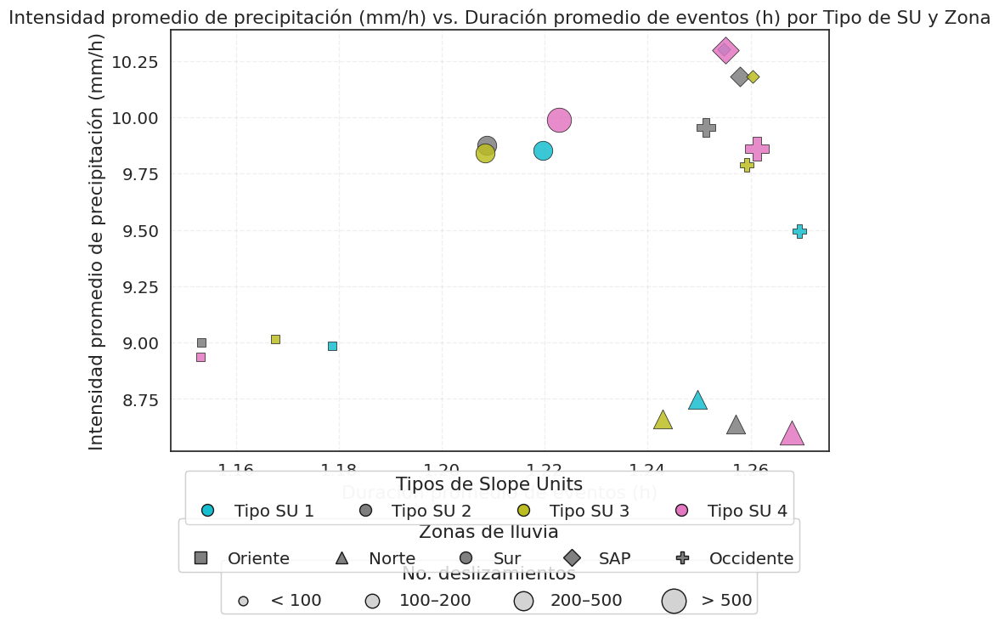

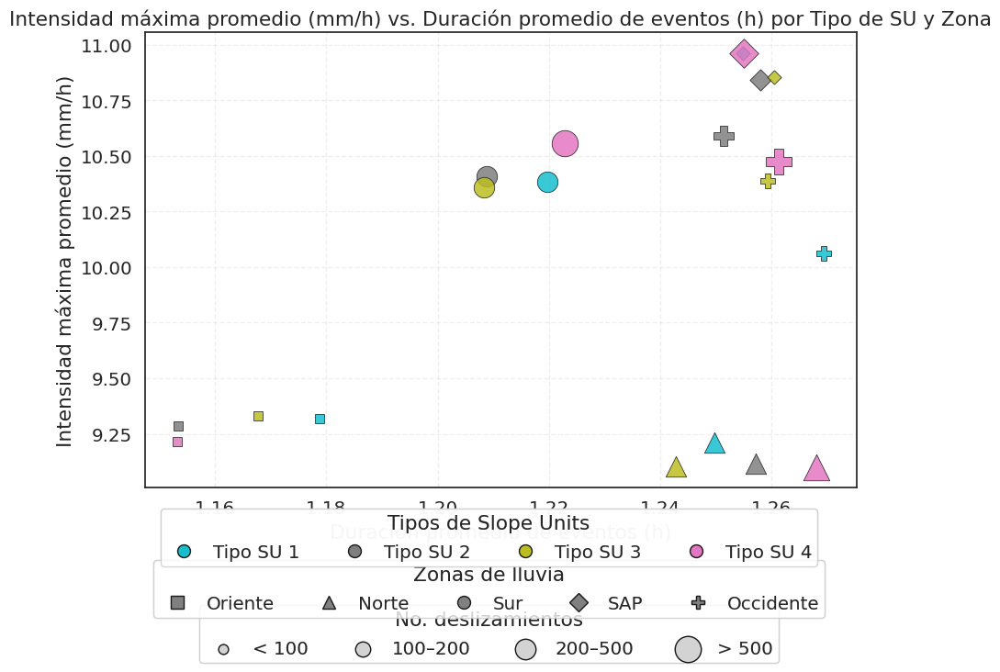

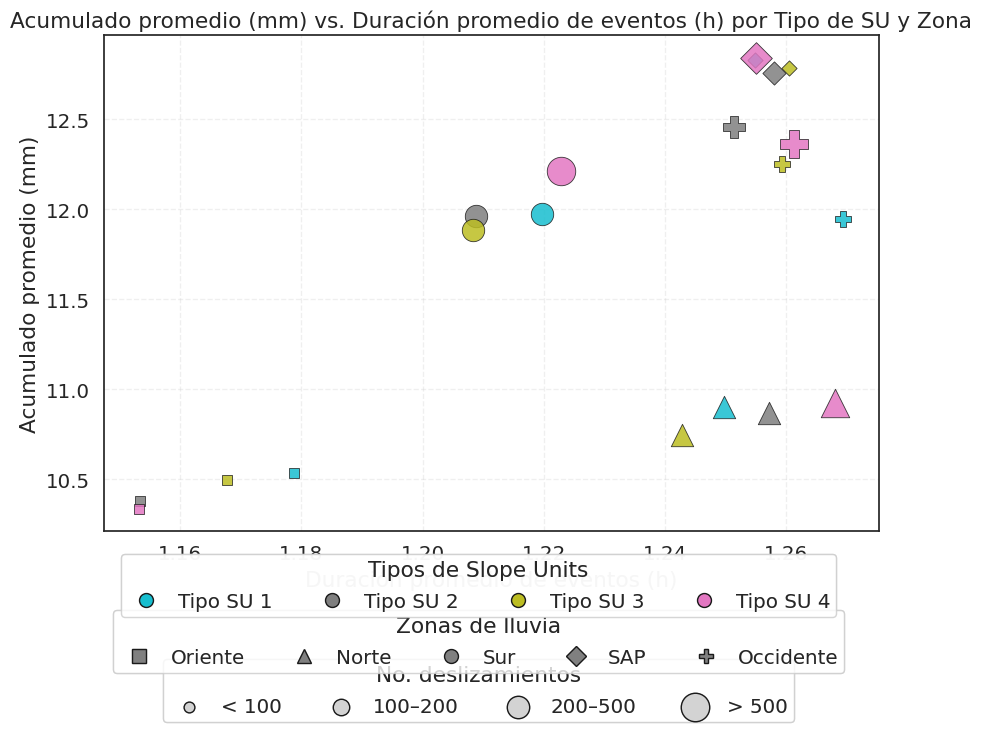

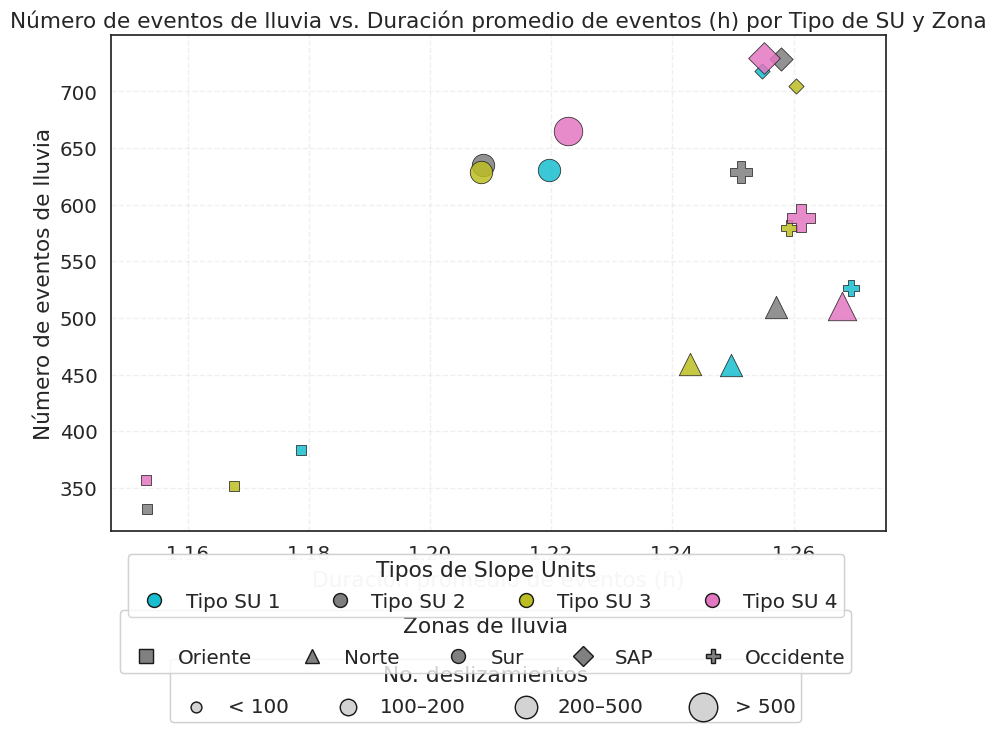

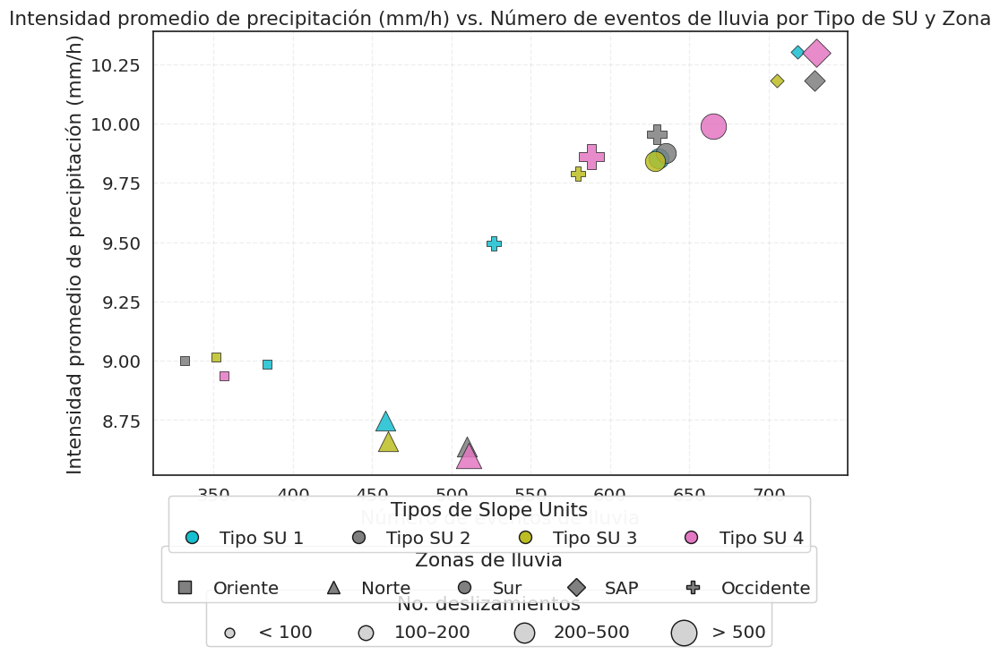

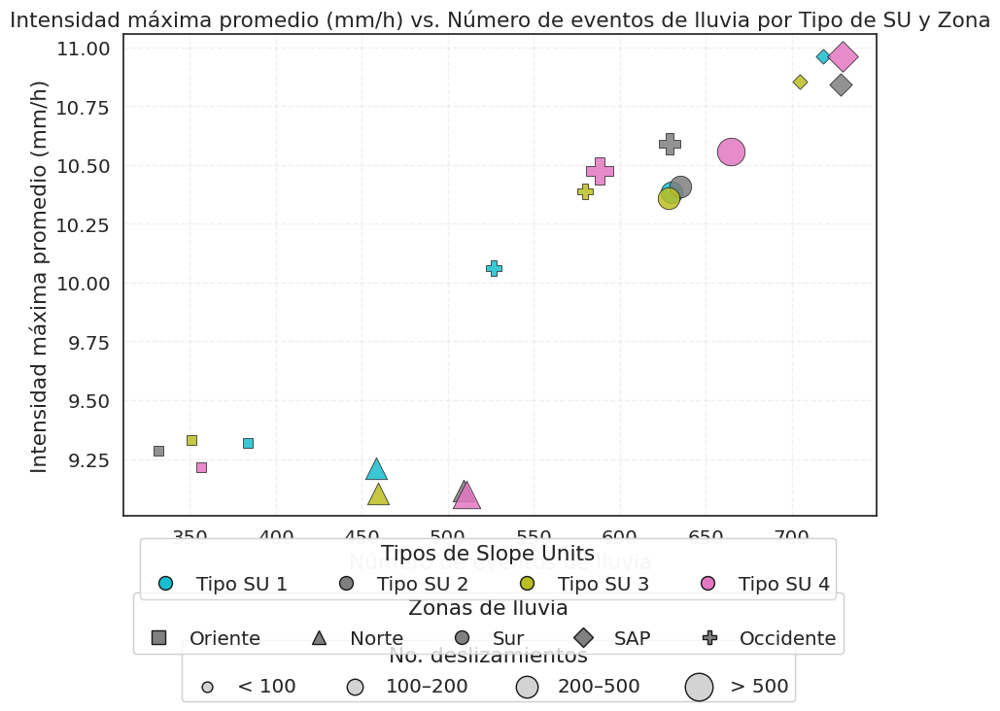

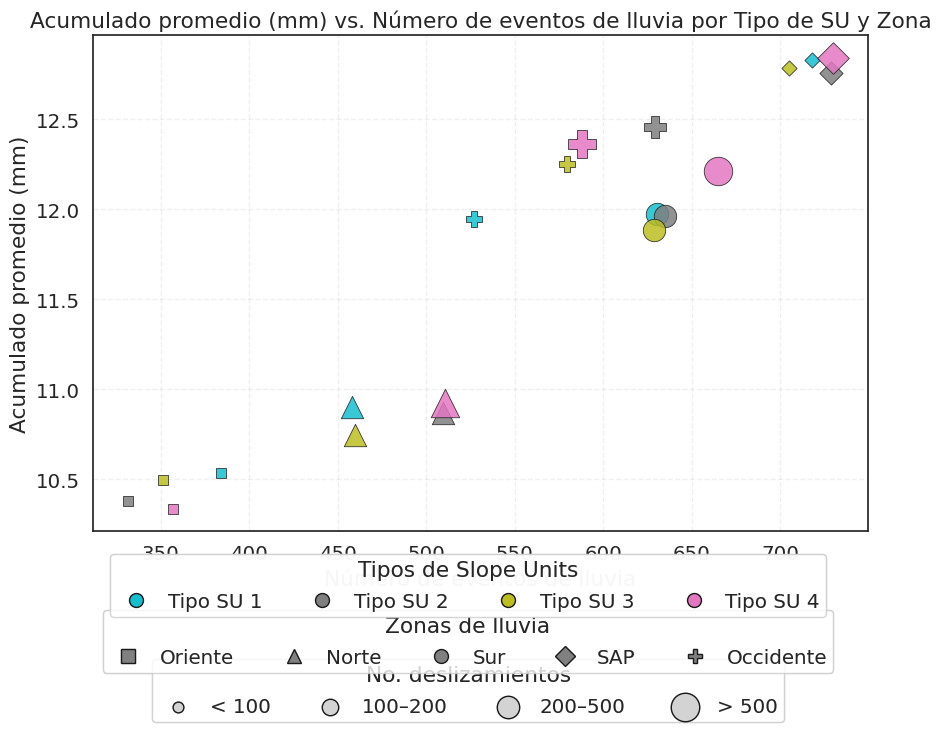

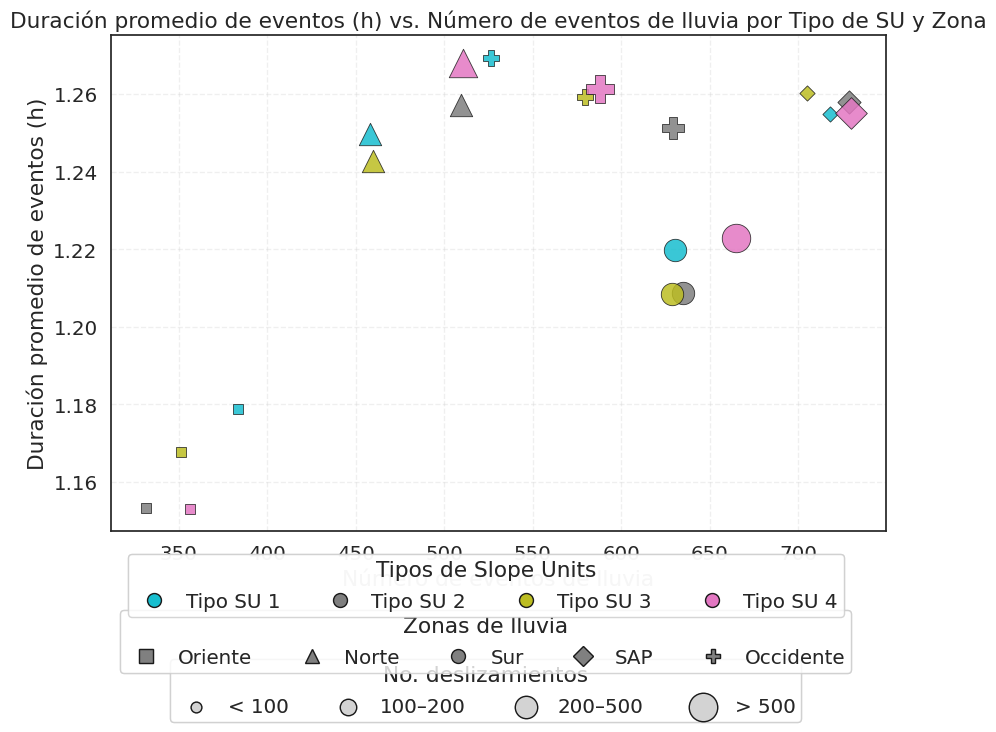

In [10]:
# ============================
# Configuración visual común
# ============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- 1) Colores por tipo de SU y marcadores por zona ---
color_por_tipo = {1: '#17becf', 2: '#7f7f7f', 3: '#bcbd22', 4: '#e377c2'}
marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}

# --- 2) Tamaños discretos por bins de deslizamientos ---
bins = [-np.inf, 100, 200, 500, np.inf]
bin_labels = ['< 100', '100–200', '200–500', '> 500']
size_map = {'< 100': 60, '100–200': 140, '200–500': 260, '> 500': 420}

# --- 2) Tamaños discretos por bins de deslizamientos ---
# Bins: (-inf,100), [100,200), [200,500), [500, inf)
# bins = [-np.inf, 5, 15, 20, np.inf]
# bin_labels = ['< 5', '5–15', '15–20', '> 20']
# # Escoge áreas (pt^2) con buena separabilidad visual
# size_map = {'< 5': 60, '5–15': 140, '15–20': 260, '> 20': 420}



def _build_size_series(df):
    """Devuelve un array de tamaños a partir de df['n_mm_total'] usando bins discretos."""
    cats = pd.cut(df['n_mm_total'], bins=bins, labels=bin_labels, right=False)
    return cats.map(size_map).astype(float).values

def _add_legends(fig, ax):
    """Crea y añade las 3 leyendas (tamaños, zonas, tipos) a nivel de figura."""
    # 1) Tamaños (bins de deslizamientos)
    handles_sizes = [
        ax.scatter([], [], s=size_map[label], c='lightgray', edgecolor='k', label=label)
        for label in bin_labels
    ]
    leg1 = fig.legend(handles=handles_sizes, title='No. deslizamientos',
                      loc='lower center', bbox_to_anchor=(0.5, 0.009),
                      ncol=len(bin_labels), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 2) Zonas (formas)
    handles_zonas = [
        mlines.Line2D([], [], color='gray', marker=marker_por_zona[z], linestyle='None',
                      label=zona_label[z], markersize=10, markeredgecolor='k')
        for z in sorted(marker_por_zona.keys())
    ]
    leg2 = fig.legend(handles=handles_zonas, title='Zonas de lluvia',
                      loc='lower center', bbox_to_anchor=(0.5, 0.07),
                      ncol=len(marker_por_zona), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 3) Tipos de SU (colores)
    handles_tipos = [
        mlines.Line2D([], [], color=color_por_tipo[t], marker='o', linestyle='None',
                      label=f'Tipo SU {t}', markersize=10, markeredgecolor='k')
        for t in sorted(color_por_tipo.keys())
    ]
    leg3 = fig.legend(handles=handles_tipos, title='Tipos de Slope Units',
                      loc='lower center', bbox_to_anchor=(0.5, 0.14),
                      ncol=len(color_por_tipo), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # Asegurar que se mantengan
    fig.add_artist(leg1); fig.add_artist(leg2); fig.add_artist(leg3)

def graficar_dispersion_su(
    df, x_col, y_col,
    title=None, savepath=None,
    figsize=(10, 8), alpha=0.85
):
    """
    Grafica un scatter reutilizable para df_plot con:
      - color por tipo_su
      - marcador por zona
      - tamaño por bins de n_mm_total
    """
    # Validaciones mínimas
    req_cols = {'tipo_su', 'zona', 'n_mm_total', x_col, y_col}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    sizes = _build_size_series(df)

    fig, ax = plt.subplots(figsize=figsize)

    # Iteración por filas (mantiene la lógica exacta del original)
    for i, row in df.iterrows():
        tipo = int(row['tipo_su'])
        zona = int(row['zona'])
        x = row[x_col]
        y = row[y_col]
        s = sizes[i]  # usa el mismo índice que df
        ax.scatter(
            x, y,
            s=s,
            c=color_por_tipo.get(tipo, 'gray'),
            marker=marker_por_zona.get(zona, 'o'),
            edgecolor='k',
            linewidth=0.6,
            alpha=alpha
        )

    # Ejes y estilo
    xlabel = col_pretty.get(x_col, x_col)
    ylabel = col_pretty.get(y_col, y_col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title is None:
        # Título genérico
        title = f'{ylabel} vs. {xlabel} por Tipo de SU y Zona'
    ax.set_title(title)

    ax.grid(True, linestyle='--', alpha=0.3)

    # Leyendas compartidas a nivel de figura
    _add_legends(fig, ax)

    # Ajuste de margenes para que quepan las leyendas inferiores
    plt.subplots_adjust(bottom=0.26)

    # Guardado opcional
    if savepath:
        # Crea carpeta si no existe
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return ax  # por si quieres seguir modificando fuera



# Etiquetas legibles por columna (para ejes y títulos)
col_pretty = {
    'duracion_promedio': 'Duración promedio de eventos (h)',
    'intensidad_promedio': 'Intensidad promedio de precipitación (mm/h)',
    'intensidad_maxima_promedio': 'Intensidad máxima promedio (mm/h)',
    'acumulado_promedio': 'Acumulado promedio (mm)',
    'num_eventos': 'Número de eventos de lluvia'
}


pares = [
    ('duracion_promedio', 'intensidad_promedio'),
    ('duracion_promedio', 'intensidad_maxima_promedio'),
    ('duracion_promedio', 'acumulado_promedio'),
    ('duracion_promedio', 'num_eventos'),
    ('num_eventos', 'intensidad_promedio'),
    ('num_eventos', 'intensidad_maxima_promedio'),
    ('num_eventos', 'acumulado_promedio'),
    ('num_eventos', 'duracion_promedio')
]

# for x_col, y_col in pares:
#     titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU y Zona"
#     nombre = f"scatter_{x_col}_vs_{y_col}.png"
#     graficar_dispersion_su(
#         df_plot,
#         x_col=x_col,
#         y_col=y_col,
#         title=titulo,
#         savepath=os.path.join(output_figures, nombre)
#     )


for x_col, y_col in pares:
    titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU y Zona"
    nombre = f"scatter_{x_col}_vs_{y_col}.png"
    graficar_dispersion_su(
        df_plot,
        x_col=x_col,
        y_col=y_col,
        title=titulo,
        savepath=False
    )

In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# --- rutas ---
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
zonas_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/clusters.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Landslides_VdeA_13jun2025/Landslides_VdeA_13jun2025.shp"
eventos_nc = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/eventos_lluvia_5mm_1horas_2.nc"

# --- colores y marcadores ---
color_map_norm = {
    "depositos cuaternarios": "#9e9e9e",
    "rocas metamorficas": "#1f77b4",
    "rocas ultramaficas": "#9467bd",
    "rocas volcanosedimentarias": "#2ca02c",
    "rocas igneas intrusivas": "#e377c2",
}
marker_por_zona = {1:'s', 2:'^', 3:'o', 4:'D', 5:'P'}
zona_label      = {1:'Oriente', 2:'Norte', 3:'Sur', 4:'SAP', 5:'Occidente'}


In [12]:
# 1. Cargar capas
geo = gpd.read_file(geo_path)
zonas = gpd.read_file(zonas_path)
inv = gpd.read_file(inv_path)

# 2. Unificar CRS
target_crs = zonas.crs
geo = geo.to_crs(target_crs)
inv = inv.to_crs(target_crs)

# 3. Normalizar nombres de geología
import unicodedata
def _norm(s):
    if s is None: return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s
geo["Geologia_norm"] = geo["Geologia"].apply(_norm)

# 4. Intersección Geología × Zona de lluvia
geo_zona = gpd.overlay(geo[["Geologia","Geologia_norm","geometry"]],
                       zonas[["NOMBRE","geometry"]],
                       how="intersection")
geo_zona["area_km2"] = geo_zona.geometry.area / 1e6
geo_zona.rename(columns={"NOMBRE":"zona"}, inplace=True)


def extraer_promedio_lluvia(nc_file, gdf, variables):
    ds = xr.open_dataset(nc_file)

    # Detectar nombres de coords (por si no son exactamente lon/lat)
    lon_name = next((k for k in ['lon','longitude','x','Este'] if k in ds), None)
    lat_name = next((k for k in ['lat','latitude','y','Norte'] if k in ds), None)
    if lon_name is None or lat_name is None:
        raise ValueError("No encontré coordenadas lon/lat en el NetCDF.")

    # Construir puntos en EPSG:4326 (o el CRS del dataset si aplica)
    lons, lats = np.meshgrid(ds[lon_name].values, ds[lat_name].values, indexing='xy')
    pts = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lons.ravel(), lats.ravel()),
        crs="EPSG:4326"
    )

    # Pasar al CRS de gdf (muy importante)
    if gdf.crs is None:
        raise ValueError("gdf no tiene CRS definido.")
    if pts.crs != gdf.crs:
        pts = pts.to_crs(gdf.crs)

    # Añadir variables (en el mismo aplanado ravel() y mismo orden de meshgrid)
    for v in variables:
        arr = np.squeeze(ds[v].values)
        if arr.ndim == 2 and arr.shape != lons.shape:
            # Si viene transpuesta, corrige
            if arr.T.shape == lons.shape:
                arr = arr.T
            else:
                raise ValueError(f"'{v}' no calza con la malla: {arr.shape} vs {lons.shape}")
        pts[v] = arr.ravel()

    # Quitar filas completamente NaN de las variables
    pts = pts.dropna(subset=variables, how='all')

    # Spatial join: puntos dentro de cada polígono de gdf
    joined = gpd.sjoin(pts, gdf, how="inner", predicate="within")

    # Agrupar por el índice de gdf que geopandas mete en 'index_right'
    resumen = (joined.groupby('index_right')[variables]
                      .mean()
                      .reindex(gdf.index))  # alinear a gdf

    return resumen

# variables en el NetCDF de eventos
var_names = ['num_eventos','intensidad_promedio','duracion_promedio',
             'acumulado_promedio','intensidad_maxima_promedio']

# Agregar promedio de lluvia de eventos
lluvia_eventos = extraer_promedio_lluvia(eventos_nc, geo_zona, var_names)
geo_zona = geo_zona.join(lluvia_eventos)


In [16]:
# Join: cada punto queda con la llave del polígono de geo_zona en 'index_right'
inv_in = gpd.sjoin(inv, geo_zona, how="inner", predicate="within")

# Agrupar por el índice de geo_zona que trae el sjoin
conteo = (inv_in
          .groupby('index_right')
          .size()
          .rename('n_mm_total')
          .reindex(geo_zona.index, fill_value=0))  # alinear 1:1 con geo_zona

# Anexar el conteo y calcular densidad
geo_zona = geo_zona.join(conteo)
geo_zona["dens_mm_km2"] = geo_zona["n_mm_total"] / geo_zona["area_km2"].replace(0, np.nan)




In [17]:
df = geo_zona.dropna(subset=["Geologia_norm","zona"]).copy()
df["color"] = df["Geologia_norm"].map(color_map_norm).fillna("#cccccc")

# convertir nombres de zona a números 1–5 si aplica
zona_map = {v:k for k,v in zona_label.items()}
df["zona_num"] = df["zona"].replace(zona_map)


In [18]:
def _build_size_by_density(df, metric='dens_mm_km2', use_quantiles=True):
    size_levels = [60, 140, 260, 420]
    x = df[metric].replace([np.inf, -np.inf], np.nan).fillna(0)
    if use_quantiles:
        q1, q2, q3 = x.quantile([0.25, 0.50, 0.75]).values
        bins = [-np.inf, q1, q2, q3, np.inf]
        labels = ['≤ Q1','Q1–Q2','Q2–Q3','> Q3']
    else:
        bins = [-np.inf,0.02,0.05,0.10,np.inf]; labels=['≤0.02','0.02–0.05','0.05–0.10','>0.10']
    cats = pd.cut(x, bins=bins, labels=labels)
    size_map = dict(zip(labels, size_levels))
    sizes = cats.map(size_map).astype(float).values
    return sizes, cats, size_map

sizes, size_bins, size_map = _build_size_by_density(df)
df["size_bin"] = size_bins
df["size_val"] = sizes


In [20]:
# 1) Si tu df tiene una columna 'zona' con nombres (Oriente, Norte, ...)
zona_label      = {1:'Oriente', 2:'Norte', 3:'Sur', 4:'SAP', 5:'Occidente'}
zona_map_inv    = {v:k for k,v in zona_label.items()}  # {'Oriente':1, ...}

# Crea/normaliza zona_num:
if 'zona_num' not in df.columns:
    df['zona_num'] = df['zona'].map(zona_map_inv)

# Fuerza a numérico seguro:
df['zona_num'] = pd.to_numeric(df['zona_num'], errors='coerce').round().astype('Int64')

In [25]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

def zonal_mean_from_nc(nc_file, gdf, var_names, crs_points="EPSG:4326"):
    """
    Calcula el promedio zonal (media simple) de variables en var_names sobre cada polígono de gdf.
    Retorna un DataFrame indexado como gdf.index con columnas de var_names.
    """
    ds = xr.open_dataset(nc_file)

    # Detectar lon/lat
    lon_name = next((k for k in ['lon','longitude','x','Este'] if k in ds), None)
    lat_name = next((k for k in ['lat','latitude','y','Norte'] if k in ds), None)
    if lon_name is None or lat_name is None:
        raise ValueError(f"[{nc_file}] No encontré coords lon/lat en el NetCDF.")

    # Malla de puntos
    LON, LAT = np.meshgrid(ds[lon_name].values, ds[lat_name].values, indexing='xy')
    pts = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(LON.ravel(), LAT.ravel()),
        crs=crs_points
    )
    if pts.crs != gdf.crs:
        pts = pts.to_crs(gdf.crs)

    # Añadir variables (cuidar orientación)
    keep = []
    for v in var_names:
        if v not in ds:
            continue
        arr = np.asarray(ds[v].values)
        arr = np.squeeze(arr)
        # Alinear con shape(LAT/LON)
        if arr.ndim == 2 and arr.shape != LON.shape:
            if arr.T.shape == LON.shape:
                arr = arr.T
            else:
                raise ValueError(f"[{nc_file}] '{v}' shape {arr.shape} no calza con grilla {LON.shape}")
        pts[v] = arr.ravel()
        keep.append(v)

    if not keep:
        # Ninguna variable encontrada; devolver columnas vacías
        return pd.DataFrame(index=gdf.index)

    # Opción: acotar por bbox para acelerar
    minx, miny, maxx, maxy = gdf.total_bounds
    pts = pts.cx[minx:maxx, miny:maxy]

    # Quitar filas sin datos
    pts = pts.dropna(subset=keep, how='all')
    if pts.empty:
        return pd.DataFrame(index=gdf.index, columns=keep)

    # Spatial join y promedio por polígono
    joined = gpd.sjoin(pts, gdf, how="inner", predicate="within")
    if joined.empty:
        return pd.DataFrame(index=gdf.index, columns=keep)

    resumen = (joined.groupby('index_right')[keep]
                     .mean()
                     .reindex(gdf.index))
    return resumen


In [26]:
# Archivos de largo plazo
nc_base_dir = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/"
nc_files = {
    "1d":  f"{nc_base_dir}estadisticos_acum_1d.nc",
    "15d": f"{nc_base_dir}estadisticos_acum_15d.nc",
    "30d": f"{nc_base_dir}estadisticos_acum_30d.nc",
    "60d": f"{nc_base_dir}estadisticos_acum_60d.nc",
    "90d": f"{nc_base_dir}estadisticos_acum_90d.nc",
}

# Estadísticos esperados; si alguno no existe en un archivo, se ignora silenciosamente
stats_vars = ["mean", "p90", "p95"]

# Para cada horizonte, agregamos columnas: mean_1d, p90_1d, p95_1d, etc.
for horizon, path in nc_files.items():
    df_stat = zonal_mean_from_nc(path, geo_zona, stats_vars)
    # Renombrar columnas con sufijo del horizonte
    df_stat = df_stat.rename(columns={c: f"{c}_{horizon}" for c in df_stat.columns})
    geo_zona = geo_zona.join(df_stat)


In [28]:
import unicodedata

# Colores de geología (normalizados)
def _norm(s):
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("ascii")
    return s.lower()

color_map_norm = {
    "depositos cuaternarios": "#9e9e9e",
    "rocas metamorficas": "#1f77b4",
    "rocas ultramaficas": "#9467bd",
    "rocas volcanosedimentarias": "#2ca02c",
    "rocas igneas intrusivas": "#e377c2",
}

# Mapa de formas y nombres de zona
marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label      = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}
zona_map_inv    = {v:k for k,v in zona_label.items()}

df = geo_zona.copy()
df["Geologia_norm"] = df["Geologia"].apply(_norm)
df["color"] = df["Geologia_norm"].map(color_map_norm).fillna("#cccccc")

# zona a código 1..5 (si tu 'zona' ya es texto)
if "zona_num" not in df.columns:
    df["zona_num"] = df["zona"].map(zona_map_inv)
df["zona_num"] = pd.to_numeric(df["zona_num"], errors="coerce").round().astype("Int64")

# Tamaños por densidad (tu helper)
def _build_size_by_density(df_, metric='dens_mm_km2', use_quantiles=True):
    size_levels = [60, 140, 260, 420]
    x = df_[metric].replace([np.inf, -np.inf], np.nan).fillna(0)
    if use_quantiles:
        q1, q2, q3 = x.quantile([0.25, 0.50, 0.75]).values
        bins = [-np.inf, q1, q2, q3, np.inf]
        labels = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']
    else:
        bins = [-np.inf, 0.02, 0.05, 0.10, np.inf]
        labels = ['≤ 0.02', '0.02–0.05', '0.05–0.10', '> 0.10']
    cats = pd.cut(x, bins=bins, labels=labels)
    size_map = dict(zip(labels, size_levels))
    sizes = cats.map(size_map).astype(float).values
    return sizes, labels, size_map, [labels[0], labels[1], labels[2], labels[3]]

sizes, bin_labels, size_map, display_labels = _build_size_by_density(df)
df["size_val"] = sizes
df["size_bin"] = pd.Categorical(pd.cut(df["dens_mm_km2"].fillna(0),
                                       bins=[-np.inf] + list(df["dens_mm_km2"].quantile([0.25,0.5,0.75])) + [np.inf],
                                       labels=['≤ Q1','Q1–Q2','Q2–Q3','> Q3']))


In [43]:
df["Geologia_norm"].unique()

array(['depa3sitos cuaternarios', 'rocas metama3rficas',
       'rocas ultramaficas', 'rocas agneas intrusivas',
       'rocas volcanosedimentarias'], dtype=object)

In [45]:
geos_presentes = df["Geologia_norm"].dropna().unique()
color_ley = {g: color_map_norm.get(g, "#cccccc") for g in geos_presentes}

In [46]:
color_ley

{'depa3sitos cuaternarios': '#cccccc',
 'rocas metama3rficas': '#cccccc',
 'rocas ultramaficas': '#9467bd',
 'rocas agneas intrusivas': '#cccccc',
 'rocas volcanosedimentarias': '#2ca02c'}

In [47]:
import re, unicodedata
import pandas as pd

def _norm_basic(s: str) -> str:
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("ascii")
    s = re.sub(r"[\-\(\)\[\],.;:/_]+", " ", s)     # quita signos
    s = re.sub(r"\s+", " ", s).strip()             # espacios dobles
    return s

df["Geologia_norm"] = df["Geologia"].apply(_norm_basic)

no_mapeadas = (df.loc[~df["Geologia_norm"].isin(color_map_norm.keys()),
                      "Geologia"]
               .value_counts())
print("Geologías que están quedando grises (top 20):")
print(no_mapeadas.head(20))

Geologías que están quedando grises (top 20):
Geologia
DepÃ³sitos Cuaternarios     5
Rocas MetamÃ³rficas         5
Rocas Ãgneas Intrusivas    5
Name: count, dtype: int64


In [49]:
def _norm_geol_to_5clases(s: str) -> str:
    t = _norm_basic(s)

    # Reglas por patrones (ajústalas si ves variantes)
    if re.search(r"\bdep(os(it)?)?itos?\b.*\bcuatern", t):
        return "depositos cuaternarios"

    if re.search(r"\brocas?\b.*\bmetamor", t):
        return "rocas metamorficas"

    if re.search(r"\brocas?\b.*\bultra\s*maf", t):
        return "rocas ultramaficas"

    if re.search(r"\brocas?\b.*\bvolcano?\s*sediment", t):
        return "rocas volcanosedimentarias"

    if re.search(r"\brocas?\b.*\bigneas?\b.*\bintrusiv", t):
        return "rocas igneas intrusivas"

    # Si nada calza, devuelve el básico (quedará gris para que lo detectes)
    return t

# aplica
df["Geologia_norm"] = df["Geologia"].apply(_norm_geol_to_5clases)

# asigna color (gris solo si de verdad no corresponde a ninguna de las 5)
df["color"] = df["Geologia_norm"].map(color_map_norm).fillna("#cccccc")


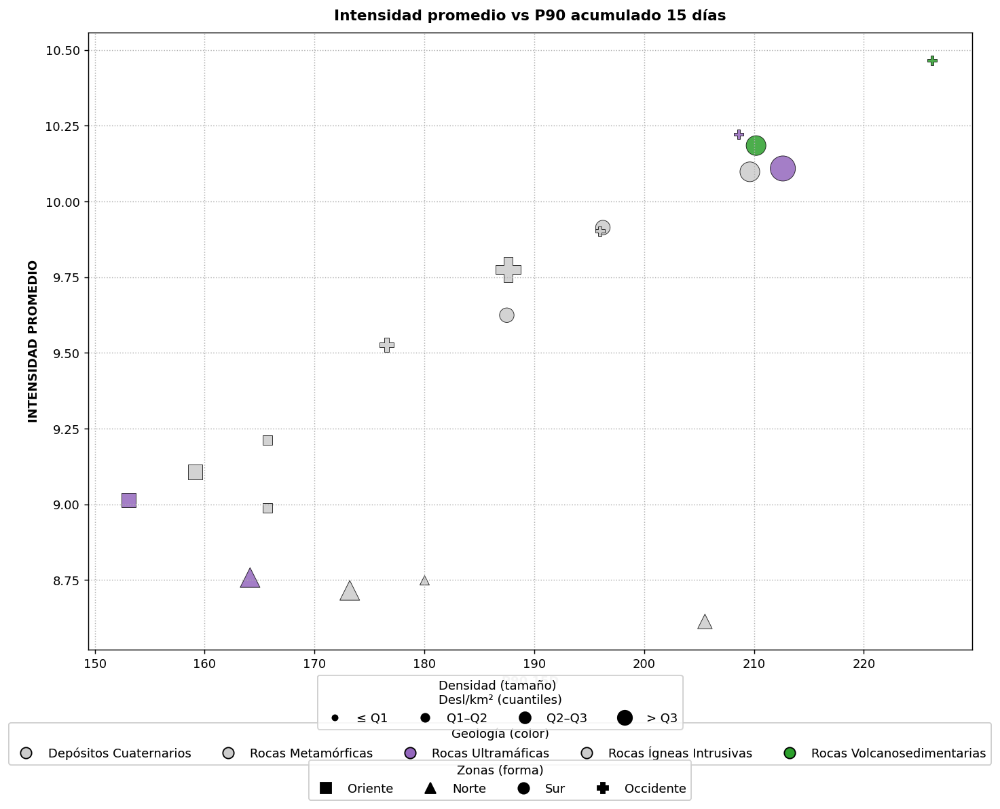

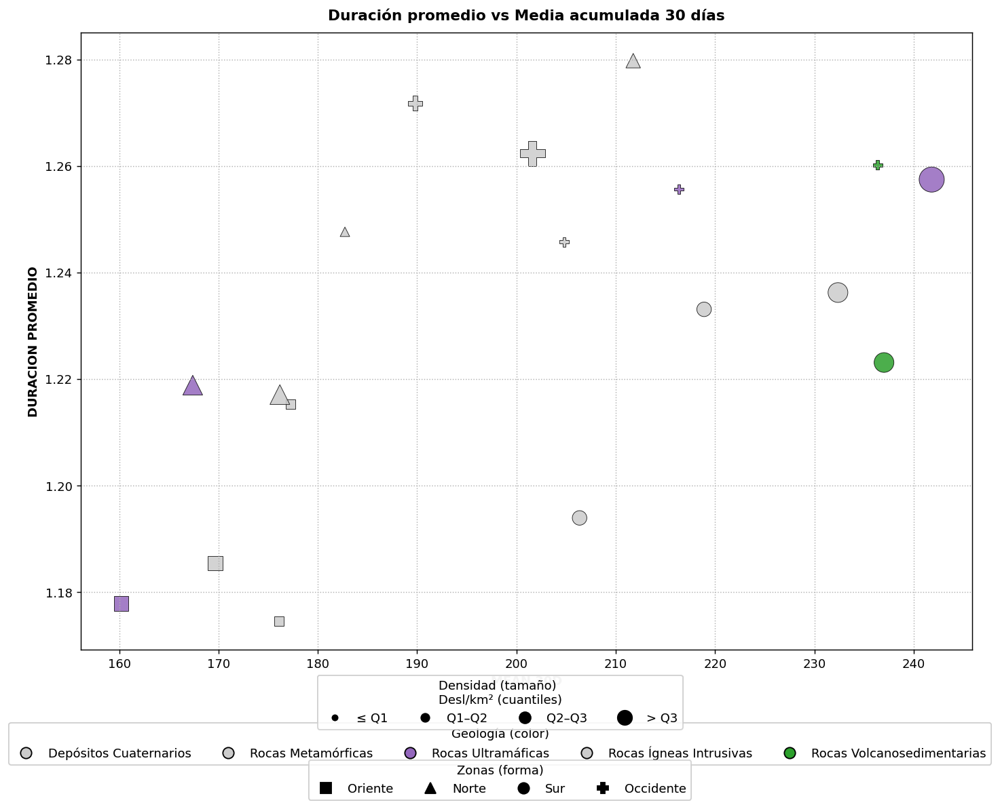

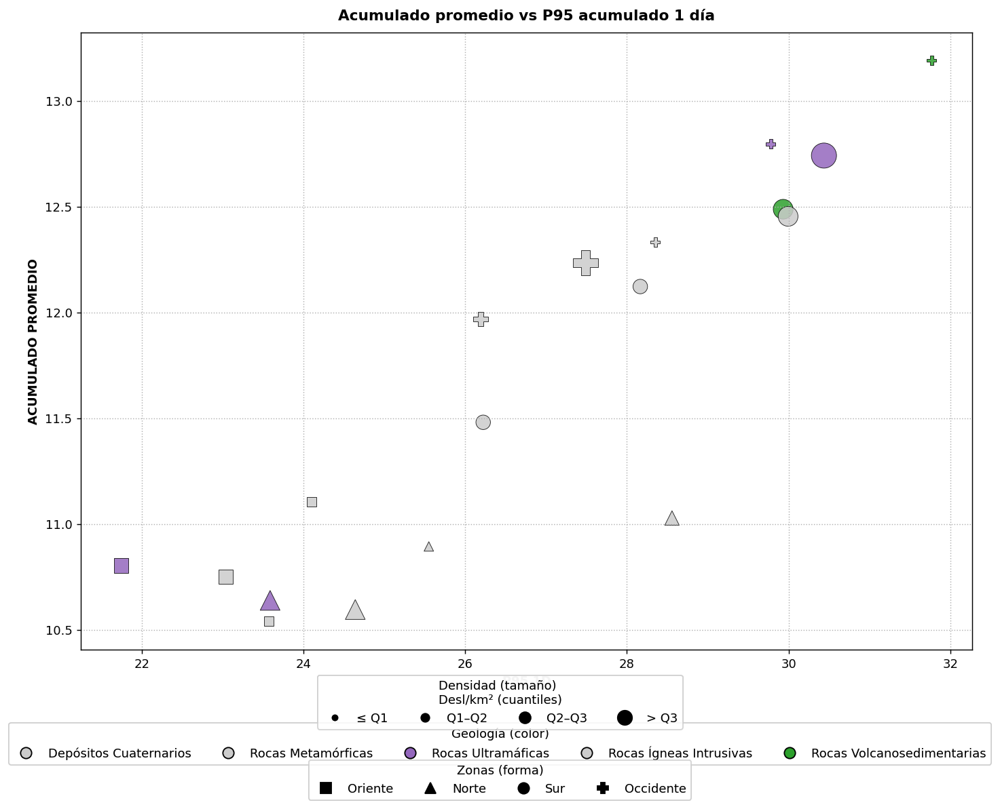

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def scatter_geo_zona(df, x_col, y_col, title):
    fig, ax = plt.subplots(figsize=(11, 8), dpi=130)

    # iterar por zona (forma)
    presentes = sorted(df["zona_num"].dropna().astype(int).unique())
    for zona in presentes:
        dfz = df[df["zona_num"] == zona]
        ax.scatter(
            dfz[x_col], dfz[y_col],
            s=dfz["size_val"], c=dfz["color"],
            alpha=0.85, edgecolor="k", linewidth=0.5,
            marker=marker_por_zona.get(zona, "o"),
            label=zona_label.get(zona, f"Zona {zona}")
        )

    ax.set_xlabel(x_col.replace("_", " ").upper(), weight="bold")
    ax.set_ylabel(y_col.replace("_", " ").upper(), weight="bold")
    ax.set_title(title, weight="bold", pad=10)

    # Leyenda de geología (colores)
    # Para no saturar, solo las que estén presentes:
    geos_presentes = df["Geologia_norm"].dropna().unique()
    color_ley = {g: color_map_norm.get(g, "#cccccc") for g in geos_presentes}
    handles_geo = [mlines.Line2D([], [], marker='o', linestyle='', color='k',
                                 markerfacecolor=c, markeredgecolor='k',
                                 markersize=9, label=lab.title())
                   for g,c in color_ley.items()
                   for lab in [ {"depa3sitos cuaternarios":"Depósitos Cuaternarios",
                                 "rocas metama3rficas":"Rocas Metamórficas",
                                 "rocas ultramaficas":"Rocas Ultramáficas",
                                 "rocas volcanosedimentarias":"Rocas Volcanosedimentarias",
                                 "rocas agneas intrusivas":"Rocas Ígneas Intrusivas"}.get(g, g) ]]

    # Leyenda de zonas (formas)
    handles_zona = [mlines.Line2D([], [], marker=marker_por_zona[z], linestyle='',
                                  color='k', markersize=9, label=zona_label[z])
                    for z in presentes]

    # Leyenda de tamaños (densidad por cuantiles)
    handles_size = [mlines.Line2D([], [], marker='o', linestyle='', color='k',
                                  markersize=np.sqrt(s/3),  # ajuste visual
                                  label=lab) for lab, s in size_map.items()]

    # 1) deja espacio abajo para 3 leyendas apiladas
    fig.subplots_adjust(bottom=0.32)   # aumenta si ves recortes (p.ej. 0.36)

    # 2) colócalas centradas y apiladas (ajusta alturas si hace falta)
    leg_geo  = fig.legend(handles=handles_geo,  title="Geología (color)",
                        loc="lower center", bbox_to_anchor=(0.5, -0.1),
                        ncol=min(5, max(1, len(handles_geo))), frameon=True)

    leg_zona = fig.legend(handles=handles_zona, title="Zonas (forma)",
                        loc="lower center", bbox_to_anchor=(0.5, -0.15),
                        ncol=len(handles_zona), frameon=True)

    leg_size = fig.legend(handles=handles_size, title="Densidad (tamaño)\nDesl/km² (cuantiles)",
                        loc="lower center", bbox_to_anchor=(0.5, -0.05),
                        ncol=len(handles_size), frameon=True)

    # 3) asegúralas sobre el eje
    ax.add_artist(leg_geo)
    ax.add_artist(leg_zona)
    ax.add_artist(leg_size)


    ax.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Ejemplos:
scatter_geo_zona(df, x_col="p90_90d",   y_col="intensidad_promedio",
                 title="Intensidad promedio vs P90 acumulado 90 días")
scatter_geo_zona(df, x_col="mean_30d",  y_col="duracion_promedio",
                 title="Duración promedio vs Media acumulada 30 días")
scatter_geo_zona(df, x_col="p95_1d",    y_col="acumulado_promedio",
                 title="Acumulado promedio vs P95 acumulado 1 día")


In [51]:
import re, unicodedata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

# Fuente con soporte latino (opcional)
mpl.rcParams['font.family'] = 'DejaVu Sans'

# --- Normalizadores y mapeos "bonitos" ---
def _norm_basic(s: str) -> str:
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("ascii")
    s = re.sub(r"[\-\(\)\[\],.;:/_]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _norm_geol_to_5clases(s: str) -> str:
    t = _norm_basic(s)
    if re.search(r"\bdep(os(it)?)?itos?\b.*\bcuatern", t):               return "depositos cuaternarios"
    if re.search(r"\brocas?\b.*\bmetamor", t):                           return "rocas metamorficas"
    if re.search(r"\brocas?\b.*\bultra\s*maf", t):                       return "rocas ultramaficas"
    if re.search(r"\brocas?\b.*\bvolcano?\s*sediment", t):               return "rocas volcanosedimentarias"
    if re.search(r"\brocas?\b.*\bigneas?\b.*\bintrusiv", t):             return "rocas igneas intrusivas"
    return t  # caerá en gris si no coincide

nice_name = {
    "depositos cuaternarios":"Depósitos Cuaternarios",
    "rocas metamorficas":"Rocas Metamórficas",
    "rocas ultramaficas":"Rocas Ultramáficas",
    "rocas volcanosedimentarias":"Rocas Volcanosedimentarias",
    "rocas igneas intrusivas":"Rocas Ígneas Intrusivas",
}

def scatter_geo_zona(df, x_col, y_col, title):
    fig, ax = plt.subplots(figsize=(11, 8), dpi=130)

    # --- asegurar geología normalizada y color correcto ---
    if "Geologia_norm" not in df.columns:
        df = df.copy()
        df["Geologia_norm"] = df["Geologia"].apply(_norm_geol_to_5clases)
    # color_map_norm y size_map deben existir en el entorno
    df["color"] = df["Geologia_norm"].map(color_map_norm).fillna("#cccccc")

    # --- iterar por zona (forma) ---
    presentes = sorted(df["zona_num"].dropna().astype(int).unique())
    for zona in presentes:
        dfz = df[df["zona_num"] == zona]
        ax.scatter(
            dfz[x_col], dfz[y_col],
            s=dfz["size_val"], c=dfz["color"],
            alpha=0.85, edgecolor="k", linewidth=0.5,
            marker=marker_por_zona.get(zona, "o"),
            label=zona_label.get(zona, f"Zona {zona}")
        )

    ax.set_xlabel(x_col.replace("_", " ").upper(), weight="bold")
    ax.set_ylabel(y_col.replace("_", " ").upper(), weight="bold")
    ax.set_title(title, weight="bold", pad=10)
    ax.grid(True, linestyle=":")

    # ----- Leyendas (solo clases presentes) -----
    # Geología (color)
    geos_presentes = df["Geologia_norm"].dropna().unique().tolist()
    handles_geo = [
        mlines.Line2D([], [], marker='o', linestyle='', color='k',
                      markerfacecolor=color_map_norm.get(g, "#cccccc"),
                      markeredgecolor='k', markersize=9,
                      label=nice_name.get(g, g.title()))
        for g in geos_presentes
    ]

    # Zonas (forma)
    handles_zona = [
        mlines.Line2D([], [], marker=marker_por_zona[z], linestyle='',
                      color='k', markersize=9, label=zona_label.get(z, f"Zona {z}"))
        for z in presentes
    ]

    # Tamaño (densidad, ordenado)
    order_size = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']
    handles_size = []
    for k in order_size:
        if k in size_map:
            s = size_map[k]
            handles_size.append(
                mlines.Line2D([], [], marker='o', linestyle='', color='k',
                              markersize=np.sqrt(s/3), label=k)
            )

    # --- Poner las 3 leyendas fuera, abajo ---
    fig.subplots_adjust(bottom=0.30)  # reserva espacio inferior
    leg_geo  = fig.legend(handles=handles_geo,  title="Geología (color)",
                          loc="lower center", bbox_to_anchor=(0.5, 0.19),
                          ncol=min(5, max(1, len(handles_geo))), frameon=True)
    leg_zona = fig.legend(handles=handles_zona, title="Zonas (forma)",
                          loc="lower center", bbox_to_anchor=(0.5, 0.10),
                          ncol=len(handles_zona), frameon=True)
    leg_size = fig.legend(handles=handles_size, title="Densidad (tamaño)\nDesl/km² (cuantiles)",
                          loc="lower center", bbox_to_anchor=(0.5, 0.03),
                          ncol=len(handles_size), frameon=True)

    ax.add_artist(leg_geo); ax.add_artist(leg_zona); ax.add_artist(leg_size)

    plt.tight_layout()
    plt.show()


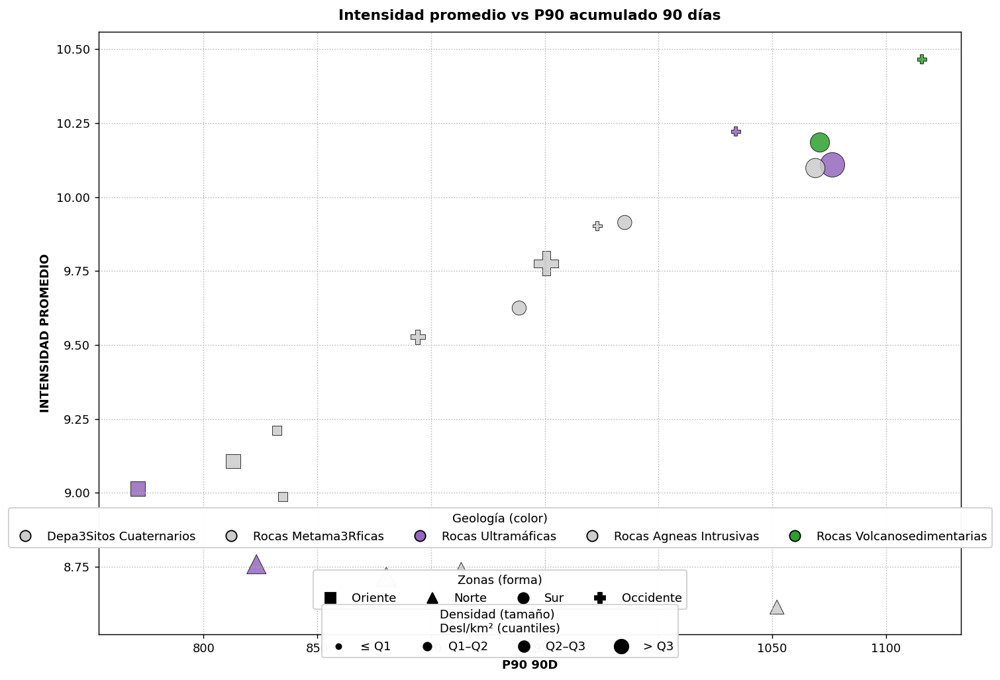

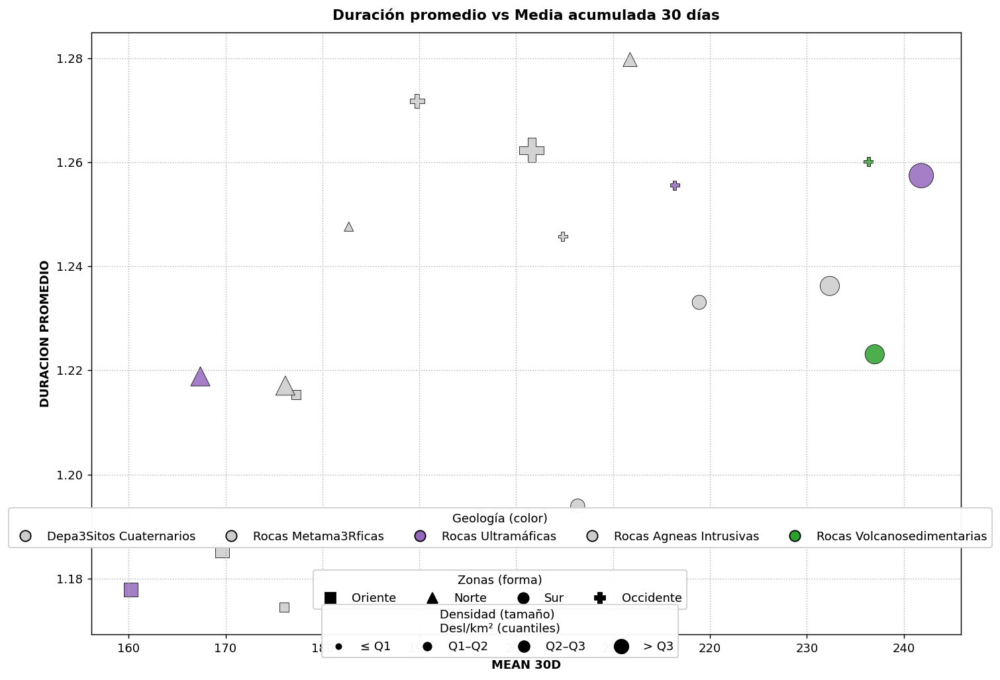

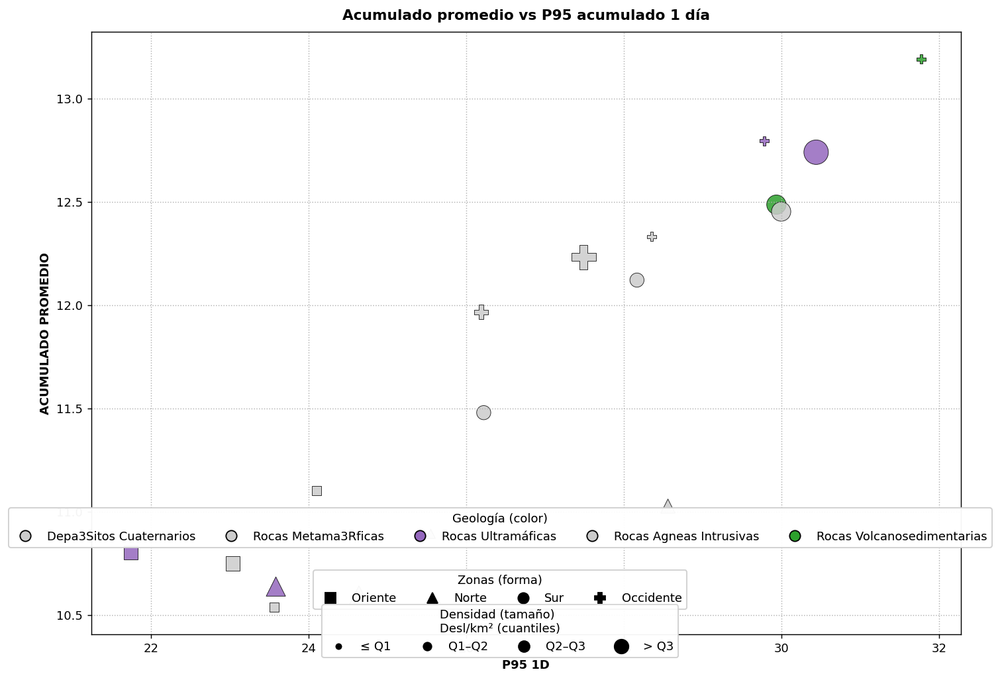

In [52]:
# Ejemplos:
scatter_geo_zona(df, x_col="p90_90d",   y_col="intensidad_promedio",
                 title="Intensidad promedio vs P90 acumulado 90 días")
scatter_geo_zona(df, x_col="mean_30d",  y_col="duracion_promedio",
                 title="Duración promedio vs Media acumulada 30 días")
scatter_geo_zona(df, x_col="p95_1d",    y_col="acumulado_promedio",
                 title="Acumulado promedio vs P95 acumulado 1 día")


In [55]:
import re, unicodedata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- nombres bonitos para la leyenda de geología ---
nice_name = {
    "depositos cuaternarios":     "Depósitos Cuaternarios",
    "rocas metamorficas":         "Rocas Metamórficas",
    "rocas ultramaficas":         "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas":    "Rocas Ígneas Intrusivas",
}

def scatter_geo_zona(df, x_col, y_col, title):
    fig, ax = plt.subplots(figsize=(11, 8), dpi=130)

    # --- asegurar columna normalizada y color (según tu _norm_geol_to_5clases y color_map_norm) ---
    if "Geologia_norm" not in df.columns:
        raise ValueError("Falta 'Geologia_norm'. Aplícalo antes con _norm_geol_to_5clases.")
    if "color" not in df.columns:
        df = df.copy()
        df["color"] = df["Geologia_norm"].map(color_map_norm).fillna("#cccccc")

    # --- iterar por zona (forma) ---
    presentes = sorted(df["zona_num"].dropna().astype(int).unique())
    for zona in presentes:
        dfz = df[df["zona_num"] == zona]
        ax.scatter(
            dfz[x_col], dfz[y_col],
            s=dfz["size_val"], c=dfz["color"],
            alpha=0.85, edgecolor="k", linewidth=0.5,
            marker=marker_por_zona.get(zona, "o"),
            label=zona_label.get(zona, f"Zona {zona}")
        )

    ax.set_xlabel(x_col.replace("_", " ").upper(), weight="bold")
    ax.set_ylabel(y_col.replace("_", " ").upper(), weight="bold")
    ax.set_title(title, weight="bold", pad=10)
    ax.grid(True, linestyle=":")

    # --- Leyenda de geología (colores) con SOLO clases presentes ---
    geos_presentes = [g for g in df["Geologia_norm"].dropna().unique() if g in color_map_norm]
    # opcional: orden fijo de las 5 clases
    orden_geo = ["depositos cuaternarios","rocas metamorficas","rocas ultramaficas",
                 "rocas volcanosedimentarias","rocas igneas intrusivas"]
    geos_presentes = [g for g in orden_geo if g in geos_presentes]

    handles_geo = [
        mlines.Line2D([], [], marker='o', linestyle='', color='k',
                      markerfacecolor=color_map_norm[g], markeredgecolor='k',
                      markersize=9, label=nice_name.get(g, g.title()))
        for g in geos_presentes
    ]

    # --- Leyenda de zonas (formas) ---
    handles_zona = [
        mlines.Line2D([], [], marker=marker_por_zona[z], linestyle='',
                      color='k', markersize=9, label=zona_label.get(z, f"Zona {z}"))
        for z in presentes
    ]

    # --- Leyenda de tamaños (densidad, en orden) ---
    order_size = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']
    handles_size = []
    for k in order_size:
        if k in size_map:
            s = size_map[k]
            handles_size.append(
                mlines.Line2D([], [], marker='o', linestyle='', color='k',
                              markersize=np.sqrt(s/3), label=k)
            )

    # --- Colocar las 3 leyendas FUERA, abajo ---
    fig.subplots_adjust(bottom=0.30)  # reserva espacio inferior

    leg_geo  = fig.legend(handles=handles_geo,  title="Geología (color)",
                          loc="lower center", bbox_to_anchor=(0.5, 0.19),
                          ncol=min(5, max(1, len(handles_geo))), frameon=True)

    leg_zona = fig.legend(handles=handles_zona, title="Zonas (forma)",
                          loc="lower center", bbox_to_anchor=(0.5, 0.10),
                          ncol=max(1, len(handles_zona)), frameon=True)

    leg_size = fig.legend(handles=handles_size, title="Densidad (tamaño)\nDesl/km² (cuantiles)",
                          loc="lower center", bbox_to_anchor=(0.5, 0.03),
                          ncol=max(1, len(handles_size)), frameon=True)

    # asegurar que queden “por encima” del eje
    ax.add_artist(leg_geo); ax.add_artist(leg_zona); ax.add_artist(leg_size)

    plt.tight_layout()
    plt.show()


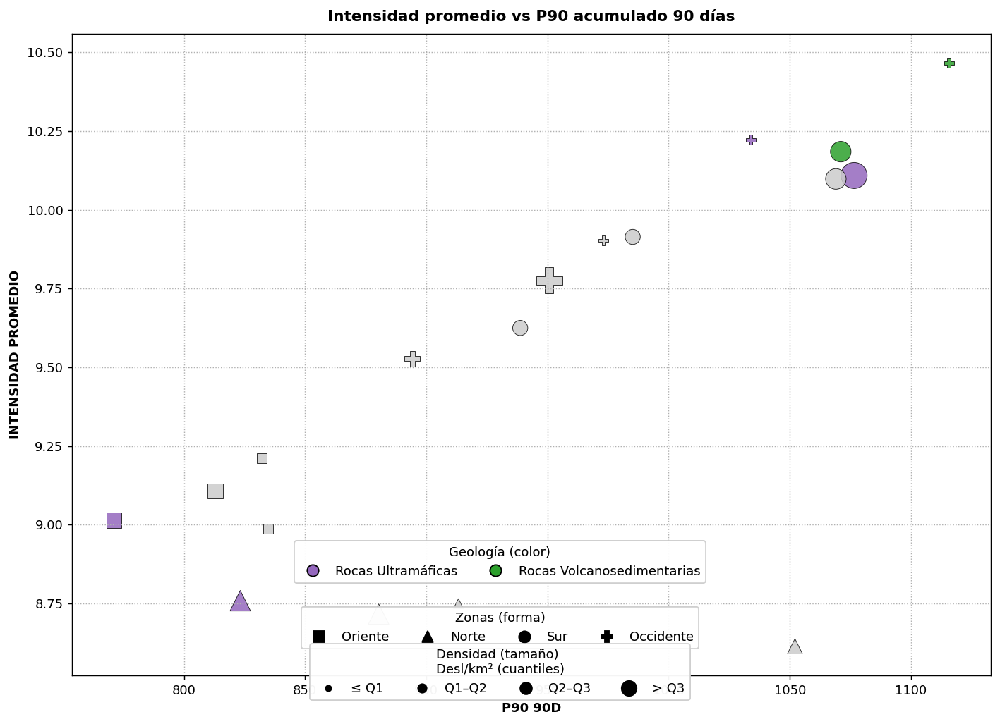

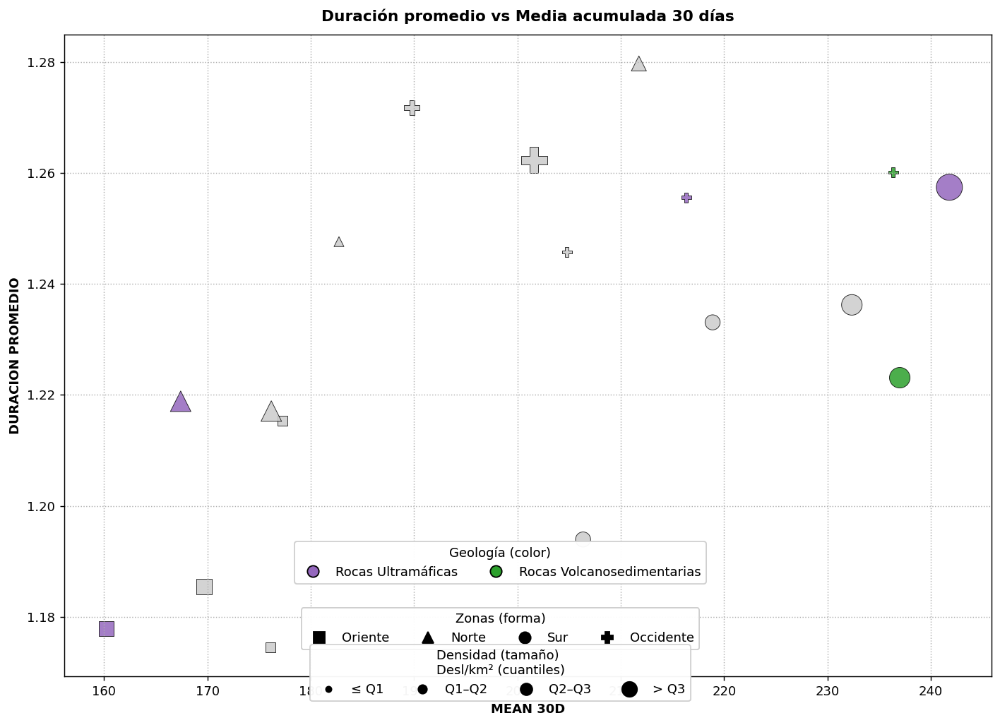

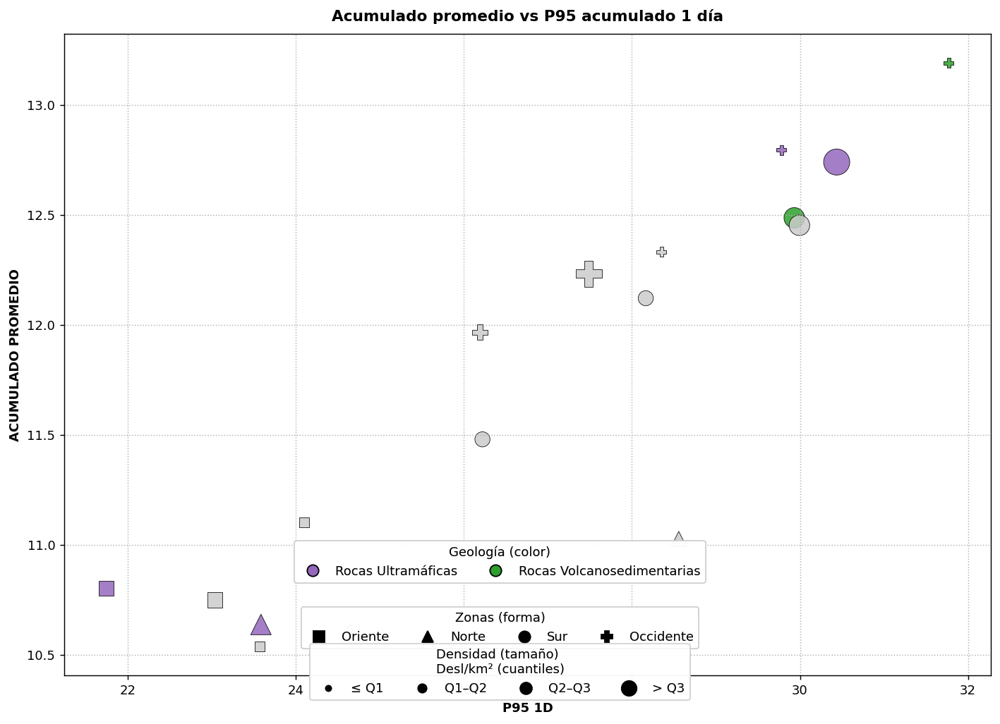

In [56]:
# Ejemplos:
scatter_geo_zona(df, x_col="p90_90d",   y_col="intensidad_promedio",
                 title="Intensidad promedio vs P90 acumulado 90 días")
scatter_geo_zona(df, x_col="mean_30d",  y_col="duracion_promedio",
                 title="Duración promedio vs Media acumulada 30 días")
scatter_geo_zona(df, x_col="p95_1d",    y_col="acumulado_promedio",
                 title="Acumulado promedio vs P95 acumulado 1 día")

In [33]:
# --- leyendas abajo ---
# Geologías presentes (para no listar colores que no aparecen)
geos_presentes = df["Geologia_norm"].dropna().unique()
# Mapeo "bonito" para mostrar nombres con tildes
nice_name = {
    "depositos cuaternarios":"Depósitos Cuaternarios",
    "rocas metamorficas":"Rocas Metamórficas",
    "rocas ultramaficas":"Rocas Ultramáficas",
    "rocas volcanosedimentarias":"Rocas Volcanosedimentarias",
    "rocas igneas intrusivas":"Rocas Ígneas Intrusivas"
}
color_ley = {nice_name.get(g, g): color_map_norm.get(g, "#cccccc") for g in geos_presentes}

# 1) Geología (color)
handles_geo = [
    mlines.Line2D([], [], marker='o', linestyle='', color='k',
                  markerfacecolor=c, markeredgecolor='k', markersize=9, label=lab)
    for lab, c in color_ley.items()
]

# 2) Zonas (forma) – solo las presentes
presentes = sorted(df["zona_num"].dropna().astype(int).unique())
handles_zona = [
    mlines.Line2D([], [], marker=marker_por_zona[z], linestyle='', color='k',
                  markersize=9, label=zona_label.get(z, f"Zona {z}"))
    for z in presentes
]

# 3) Densidad (tamaño) – usa los bins/cuanti les que ya calculaste
# Si guardaste 'display_labels' en tu helper, puedes usarlas; si no, generamos desde size_map:
# (Opcional) ordenar las categorías para que salgan en orden lógico
order_size = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']
handles_size = []
for k in order_size:
    if k in size_map:
        s = size_map[k]
        # El tamaño del marcador en legend es en "points"; uso una raíz para que se parezca visualmente
        handles_size.append(
            mlines.Line2D([], [], marker='o', linestyle='', color='k',
                          markersize=np.sqrt(s/3), label=k)
        )

# Deja espacio abajo para 3 filas de leyendas
plt.subplots_adjust(bottom=0.30)

# Coloca las 3 leyendas apiladas al centro inferior
# (ajusta las alturas 0.22, 0.12, 0.04 si necesitas más/menos separación)
leg_geo  = fig.legend(handles=handles_geo,  title="Geología (color)",
                      loc="lower center", bbox_to_anchor=(0.5, 0.22),
                      ncol=min(5, max(1, len(handles_geo))), frameon=True)

leg_zona = fig.legend(handles=handles_zona, title="Zonas (forma)",
                      loc="lower center", bbox_to_anchor=(0.5, 0.12),
                      ncol=len(handles_zona), frameon=True)

leg_size = fig.legend(handles=handles_size, title="Densidad (tamaño)\nDesl/km² (cuantiles)",
                      loc="lower center", bbox_to_anchor=(0.5, 0.04),
                      ncol=len(handles_size), frameon=True)

# Asegura que las leyendas de figura prevalezcan sobre la de ejes
ax.add_artist(leg_geo)
ax.add_artist(leg_zona)
ax.add_artist(leg_size)


<Figure size 640x480 with 0 Axes>

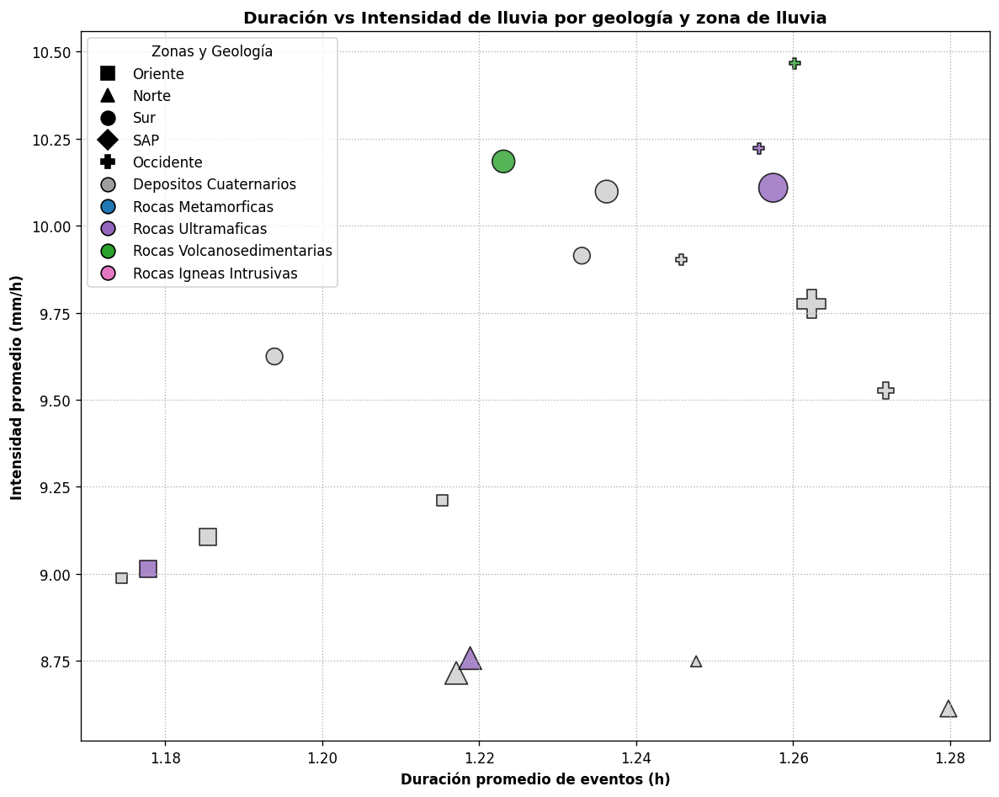

In [54]:
fig, ax = plt.subplots(figsize=(10,8), dpi=120)

for zona in sorted(df['zona_num'].dropna().astype(int).unique()):
    dfz = df[df['zona_num'] == zona]
    ax.scatter(
        dfz["duracion_promedio"], dfz["intensidad_promedio"],
        s=dfz["size_val"], c=dfz["color"], alpha=0.8, edgecolor="k",
        marker=marker_por_zona.get(zona, "o"),
        label=zona_label.get(zona, f"Zona {zona}")
    )

ax.set_xlabel("Duración promedio de eventos (h)", weight="bold")
ax.set_ylabel("Intensidad promedio (mm/h)", weight="bold")
ax.set_title("Duración vs Intensidad de lluvia por geología y zona de lluvia", weight="bold")

# --- leyenda de colores (geología) ---
handles_geo = [mlines.Line2D([],[],marker='o',color='w',
                             markerfacecolor=c,markeredgecolor='k',
                             markersize=10,label=lab.title())
               for lab,c in color_map_norm.items()]
ax.legend(handles=handles_geo, title="Unidades Geológicas", loc="upper left", frameon=True)

# --- leyenda de zonas (formas) ---
handles_zona = [mlines.Line2D([],[],marker=marker_por_zona[z],color='k',linestyle='',
                              markersize=10,label=zona_label[z])
                for z in marker_por_zona]
ax.legend(handles=handles_zona+handles_geo, loc="best", frameon=True, title="Zonas y Geología")

ax.grid(True, linestyle=':')
plt.tight_layout()
plt.show()


### **CON INVENTARIO DE GEOHAZARDS**

In [45]:
# %% ================================================================
# 0) Importaciones
# ================================================================
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=UserWarning)


# %% ================================================================
# 1) Utilidad: asegurar CRS proyectado (metros) para áreas/distancias
# ================================================================
def _ensure_projected(gdf):
    """
    Si el CRS es geográfico (grados) proyecta a un CRS UTM aproximado según el cent
    roide.
    Devuelve una copia proyectada y el CRS original.
    """
    if gdf.crs is None:
        raise ValueError("El GeoDataFrame no tiene CRS definido.")

    if not gdf.crs.is_geographic:
        return gdf.copy(), gdf.crs  # ya está proyectado (metros)

    # Estimar zona UTM a partir del centroide (asume WGS84)
    centroid = gdf.to_crs(4326).geometry.unary_union.centroid
    lon = centroid.x
    lat = centroid.y
    utm_zone = int((lon + 180) // 6) + 1
    is_north = lat >= 0
    epsg = 32600 + utm_zone if is_north else 32700 + utm_zone
    return gdf.to_crs(epsg), gdf.crs


# %% ================================================================
# 2) Tu función: filtrar e interpolar NetCDF (tal cual)
# ================================================================
def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas
    en un archivo CSV y luego interpola los valores faltantes.
    """
    coords_df = pd.read_csv(coord_file)
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values

    data = xr.open_dataset(radar_file)

    mask = xr.DataArray(
        np.ones((len(data.lon), len(data.lat)), dtype=bool),
        coords=[data.lon, data.lat],
        dims=["lon", "lat"]
    )

    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False

    data_filtrado = data.where(mask, drop=True)

    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    return interpolated_ds


# %% ================================================================
# 3) Utilidades geoespaciales y de agregación
# ================================================================
def detectar_lat_lon(ds):
    """Detecta nombres de coords lat/lon y si son 1D."""
    cand_lat = ['lat', 'latitude', 'y', 'Norte']
    cand_lon = ['lon', 'longitude', 'x', 'Este']
    lat_name = next((c for c in cand_lat if c in ds.coords or c in ds.variables), None)
    lon_name = next((c for c in cand_lon if c in ds.coords or c in ds.variables), None)
    if lat_name is None or lon_name is None:
        raise ValueError("No pude detectar coordenadas de lat/lon en el NetCDF.")
    is_1d = (ds[lat_name].ndim == 1 and ds[lon_name].ndim == 1)
    return lat_name, lon_name, is_1d


def ds_a_puntos_gdf(ds, var_names, su_crs):
    """
    Convierte un Dataset (ya filtrado/interpolado) en un GeoDataFrame de puntos con
    variables var_names. Se adapta al orden de ejes (lat,lon)/(lon,lat) y a coords 1D/2D.
    """
    lat_name, lon_name, is_1d = detectar_lat_lon(ds)

    ref_var = var_names[0]
    ref_arr = np.squeeze(ds[ref_var].values)
    ref_shape = ref_arr.shape

    if is_1d:
        x = ds[lon_name].values  # lon
        y = ds[lat_name].values  # lat
        Nx, Ny = len(x), len(y)
        # Construimos SIEMPRE malla (Ny, Nx) = (lat,lon)
        LON, LAT = np.meshgrid(x, y, indexing='xy')  # -> (Ny, Nx)
        shape_yx = (Nx, Ny)  # (lon, lat)
        need_T = (ref_shape == shape_yx)
    else:
        LON = ds[lon_name].values
        LAT = ds[lat_name].values
        if ref_shape == LON.shape:
            need_T = False
        elif ref_shape == LON.T.shape:
            LON, LAT = LON.T, LAT.T
            need_T = False
        else:
            raise ValueError(
                f"No puedo alinear lon/lat 2D con la variable de referencia. "
                f"ref_shape={ref_shape}, LON.shape={LON.shape}, LAT.shape={LAT.shape}"
            )

    data_cols = {}
    for v in var_names:
        arr = np.squeeze(ds[v].values)
        if is_1d and need_T and arr.ndim == 2 and arr.shape == (Nx, Ny):
            arr = arr.T
        if arr.ndim == 2 and arr.shape != LON.shape and arr.T.shape == LON.shape:
            arr = arr.T
        if arr.shape != LON.shape:
            raise ValueError(
                f"'{v}' no calza con la malla: {arr.shape} vs {LON.shape}. "
                f"dims de '{v}': {getattr(ds[v], 'dims', None)}"
            )
        data_cols[v] = arr.ravel()

    df = pd.DataFrame({'lon': LON.ravel(), 'lat': LAT.ravel(), **data_cols})
    df = df.dropna(subset=var_names, how='all')

    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs='EPSG:4326')
    if su_crs is not None and gdf.crs != su_crs:
        gdf = gdf.to_crs(su_crs)
    return gdf


def _estimar_tamano_celda_xy(pts_gdf):
    """Estima tamaño de celda (pasos) en X e Y (metros)."""
    xs = np.asarray(pts_gdf.geometry.x)
    ys = np.asarray(pts_gdf.geometry.y)
    dx = np.diff(np.sort(xs))
    dy = np.diff(np.sort(ys))
    dx = dx[dx > 0]
    dy = dy[dy > 0]
    step_x = np.nanmedian(dx) if dx.size else np.nanmedian(dy)
    step_y = np.nanmedian(dy) if dy.size else np.nanmedian(dx)
    return float(step_x), float(step_y)


def _puntos_a_celdas(pts_gdf, half_x, half_y):
    """Convierte cada punto centroide en un polígono-celda rectangular."""
    polys = []
    for p in pts_gdf.geometry:
        x, y = p.x, p.y
        poly = Polygon([(x-half_x, y-half_y),
                        (x+half_x, y-half_y),
                        (x+half_x, y+half_y),
                        (x-half_x, y+half_y)])
        polys.append(poly)
    gdf_cells = pts_gdf.copy()
    gdf_cells.geometry = polys
    return gdf_cells


def agregar_lluvia_a_su_area_ponderada(su_gdf, puntos_gdf, var_names, fallback_radio_m=600):
    """
    Promedia variables de lluvia por SU usando ponderación areal:
      1) Convierte puntos (centros de píxel) en celdas-polígono.
      2) Interseca SU∩celdas, promedia con pesos=área de intersección.
      3) Fallback con sjoin_nearest para SU sin datos (radio en metros).
    """
    # Asegurar CRS proyectado (metros) en ambos
    su_proj, su_crs_original = _ensure_projected(su_gdf)
    pts_proj = puntos_gdf.to_crs(su_proj.crs)

    su = su_proj.copy()
    if 'su_idx' not in su.columns:
        su['su_idx'] = su.index

    # 1) Celdas-polígono
    step_x, step_y = _estimar_tamano_celda_xy(pts_proj)
    half_x, half_y = 0.5*step_x, 0.5*step_y
    cells = _puntos_a_celdas(pts_proj[['geometry'] + var_names].copy(), half_x, half_y)
    cells = cells.set_geometry('geometry')
    cells.crs = su.crs

    # 2) Intersección SU ∩ celdas
    su = su.copy()
    su['geometry'] = su['geometry'].buffer(0)  # arreglos topológicos pequeños
    inter = gpd.overlay(cells, su[['su_idx', 'geometry']], how='intersection')
    if inter.empty:
        print("[WARN] No hubo intersecciones SU∩celdas. Verifica CRS y cobertura.")
        inter['area_w'] = np.nan
    else:
        inter['area_w'] = inter.area

    # 3) Promedio ponderado
    su_vals = []
    for suidx, grp in inter.groupby('su_idx'):
        w = grp['area_w'].to_numpy()
        W = np.nansum(w)
        rec = {'su_idx': suidx}
        for v in var_names:
            vals = grp[v].to_numpy()
            rec[v] = (np.nansum(vals * w) / W) if (np.isfinite(W) and W > 0) else np.nan
        su_vals.append(rec)
    su_stats = (pd.DataFrame(su_vals).set_index('su_idx')
                if su_vals else pd.DataFrame(columns=['su_idx']+var_names).set_index('su_idx'))

    # Volcar a SU
    for v in var_names:
        su.loc[su_stats.index, v] = su_stats[v]

    # 4) Fallback: vecino más cercano para SU sin datos
 # 4) Fallback: vecino más cercano para SU sin datos
    faltan = su[su[var_names].isna().all(axis=1)].copy()
    if not faltan.empty:
        # centroide de SU
        faltan_cent = faltan.set_geometry(faltan.centroid)

        nearest = gpd.sjoin_nearest(
            faltan_cent[['su_idx', 'geometry']],
            cells[['geometry'] + var_names],
            how='left',
            max_distance=fallback_radio_m,
            distance_col='dist'
        )

        # Si por alguna razón hay duplicados por su_idx (empates), nos quedamos con la primera (o la más cercana)
        # Aquí tomamos la fila con menor distancia por su_idx:
        nearest = (nearest.sort_values('dist')
                          .groupby('su_idx', as_index=True)
                          .first())

        # Construimos una tabla de valores por su_idx para mapear
        vals_df = nearest[var_names]  # index = su_idx

        for v in var_names:
            # Serie alineada al índice de 'su' (su_idx) usando map
            mapped = su.index.to_series().map(vals_df[v])  # devuelve Serie indexada como su.index
            # Rellenamos solo donde su[v] es NaN
            su[v] = su[v].fillna(mapped)

    # Regresar al CRS original de las SU si venía geográfico
    su_out = su.to_crs(su_crs_original)
    return su_out, su_stats


def normalizar_zona(z):
    """Convierte texto/num de zona a {1..5} con heurísticas."""
    if pd.isna(z):
        return np.nan
    s = str(z).lower().strip()
    m = re.search(r'\b([1-5])\b', s)
    if m:
        return int(m.group(1))
    if 'norte' in s: return 1
    if 'oriente' in s: return 2
    if 'occidente' in s: return 3
    if 'sur' in s: return 4
    if 'sap' in s or 'san antonio' in s: return 5
    return np.nan

def agrupar_por_tipo_y_zona(su_enriquecida, var_names):
    """
    Agrega por (tipo de SU=cluster4, zona ENTERA).
    - Lluvia: promedio entre SUs del grupo (usando datos disponibles).
    - n_mm_total: suma de deslizamientos (para tamaño de símbolo).
    Supone que 'zona' ya viene numérica (float) codificada 1..5.
    """
    # Tomamos columnas necesarias
    df = su_enriquecida[['cluster4', 'zona', 'n_mm_gpkg'] + var_names].copy()

    # n_mm seguro (suma no falle)
    df['n_mm_gpkg'] = pd.to_numeric(df['n_mm_gpkg'], errors='coerce').fillna(0)

    # cluster4 numérico
    df['cluster4'] = pd.to_numeric(df['cluster4'], errors='coerce')

    # tipo_su: si viene 0..3 -> 1..4; si ya viene 1..4, lo dejamos
    min_c4 = df['cluster4'].min(skipna=True)
    df['tipo_su'] = np.where(pd.notnull(min_c4) & (min_c4 == 0),
                             df['cluster4'] + 1, df['cluster4'])

    # zona numérica (float -> entero). Si hay decimales por redondeo, usamos round antes del cast
    df['zona_num'] = pd.to_numeric(df['zona'], errors='coerce')
    # Requerimos zona y tipo válidos
    before = len(df)
    df = df.dropna(subset=['tipo_su', 'zona_num'], how='any').copy()
    print(f"[INFO] Filas descartadas por zona/tipo NaN: {before - len(df)}")

    # Al menos UNA variable de lluvia válida (no tiramos filas por tener alguna NaN)
    mask_lluvia = df[var_names].notna().any(axis=1)
    print(f"[INFO] SU sin ninguna variable de lluvia válida: {(~mask_lluvia).sum()}")
    df = df[mask_lluvia].copy()

    # Casteos seguros
    df['tipo_su'] = df['tipo_su'].astype(int)
    # Si vienen como 1.0, 2.0... esto los vuelve 1, 2...
    # Usar .round() por si hay floats tipo 2.0000001
    df['zona'] = df['zona_num'].round().astype(int)

    # Agregación por (tipo_su, zona)
    gp = df.groupby(['tipo_su', 'zona'], as_index=False).agg({
        var_names[0]: 'mean',   # num_eventos
        var_names[1]: 'mean',   # intensidad_promedio
        var_names[2]: 'mean',   # duracion_promedio
        var_names[3]: 'mean',   # acumulado_promedio
        var_names[4]: 'mean',   # intensidad_maxima_promedio
        'n_mm_gpkg': 'sum'           # total deslizamientos
    }).rename(columns={'n_mm_gpkg': 'n_mm_total'})

    return gp

# %% ================================================================
# 4) Rutas y archivos
# ================================================================
radar_events_dir = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'              # (no usado directo aquí)
output_figures   = '../../FIGURES/spatial_analysis/radar/'
os.makedirs(output_figures, exist_ok=True)

ruta_slope_units = '../../DATA/shape_files/slope_units_analisis_geohazard.shp'
file_nc          = 'eventos_lluvia_5mm_1horas_2.nc'
coord_file       = f'{radar_events_dir}coordenadas_que_no.csv'

# %% ================================================================
# 5) Flujo principal
# ================================================================
# 5.1 Leer Slope Units
su_gdf = gpd.read_file(ruta_slope_units)
if su_gdf.crs is None:
    raise ValueError("El shapefile de Slope Units no tiene CRS. Asígnalo antes de continuar.")
su_crs = su_gdf.crs

for col in ['cluster4', 'zona', 'n_mm_gpkg', 'si_no_gpkg']:
    if col not in su_gdf.columns:
        raise ValueError(f"Falta la columna '{col}' en {ruta_slope_units}")

# 5.2 Filtrar + interpolar NetCDF
ds_filtrado = filter_and_interpolate_data(
    radar_file=os.path.join(radar_events_dir, file_nc),
    coord_file=coord_file
)

# 5.3 Dataset -> puntos (en CRS de las SU)
var_names = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio', 'intensidad_maxima_promedio']
gdf_pts = ds_a_puntos_gdf(ds_filtrado, var_names=var_names, su_crs=su_crs)
print(f"Puntos de radar tras filtrado/interpolación: {len(gdf_pts):,}")

# 5.4 Enriquecer SU con promedio ponderado por área (+fallback vecino)
su_enriquecida, su_stats = agregar_lluvia_a_su_area_ponderada(
    su_gdf=su_gdf,
    puntos_gdf=gdf_pts,
    var_names=var_names,
    fallback_radio_m=600
)

# Debug rápido
print("Total SU:", len(su_enriquecida))
print("\nValores únicos de 'zona' (muestra 15):")
print(su_enriquecida['zona'].drop_duplicates().astype(str).head(15).to_list())
print("\n¿Cuántas SU tienen cada variable de lluvia NaN?")
for v in var_names:
    nmiss = su_enriquecida[v].isna().sum()
    print(f"  {v}: NaN en {nmiss} SU ({nmiss/len(su_enriquecida):.1%})")
print("\nFaltantes en cluster4 y zona:")
print("  cluster4 NaN:", su_enriquecida['cluster4'].isna().sum())
print("  zona NaN:", su_enriquecida['zona'].isna().sum())

# 5.5 Agregar por (tipo de SU, zona)
df_plot = agrupar_por_tipo_y_zona(su_enriquecida, var_names)


Puntos de radar tras filtrado/interpolación: 13,209
Total SU: 57524

Valores únicos de 'zona' (muestra 15):
['2.0', '4.0', '5.0', '3.0', '1.0', 'nan']

¿Cuántas SU tienen cada variable de lluvia NaN?
  num_eventos: NaN en 0 SU (0.0%)
  intensidad_promedio: NaN en 0 SU (0.0%)
  duracion_promedio: NaN en 0 SU (0.0%)
  acumulado_promedio: NaN en 0 SU (0.0%)
  intensidad_maxima_promedio: NaN en 0 SU (0.0%)

Faltantes en cluster4 y zona:
  cluster4 NaN: 0
  zona NaN: 146
[INFO] Filas descartadas por zona/tipo NaN: 146
[INFO] SU sin ninguna variable de lluvia válida: 0


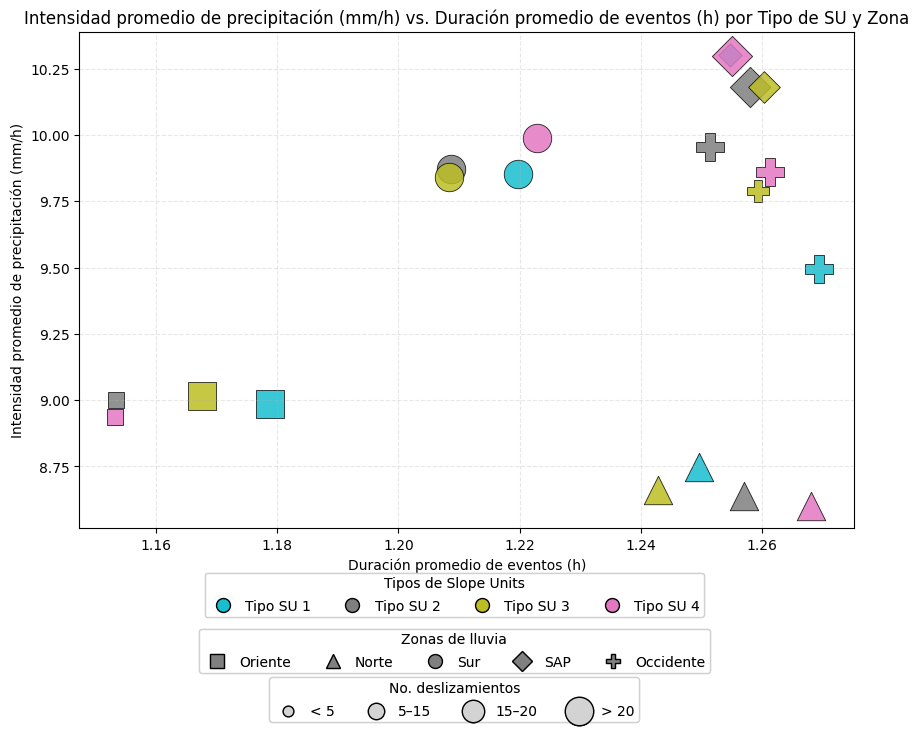

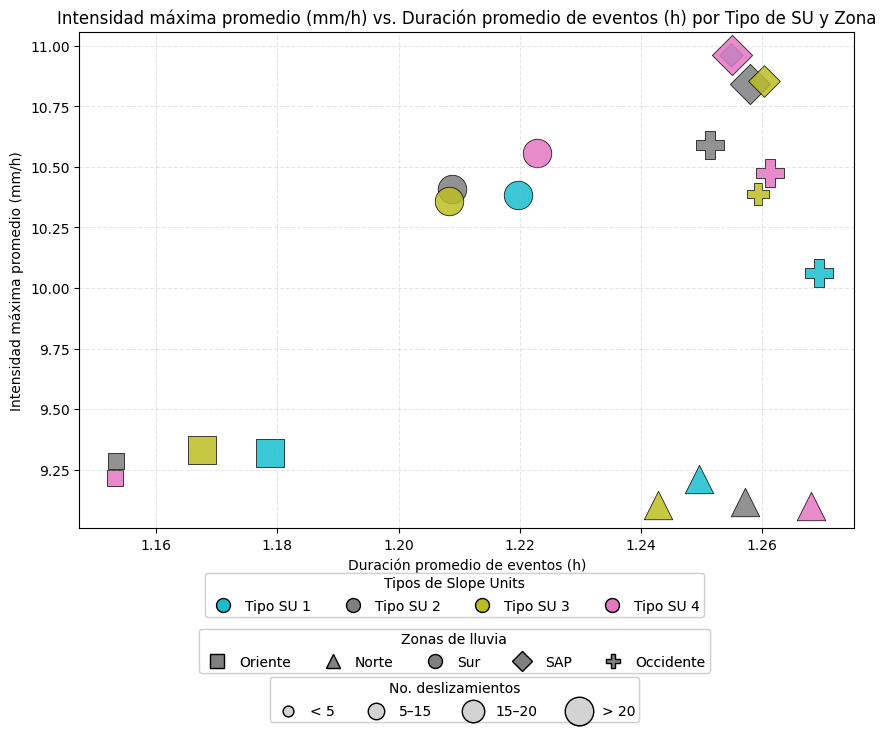

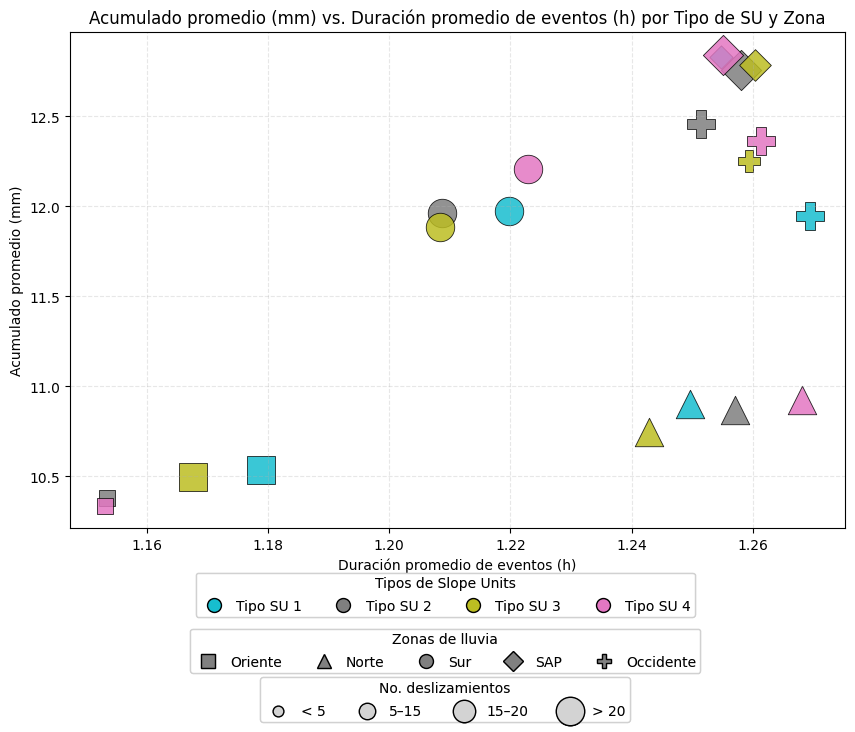

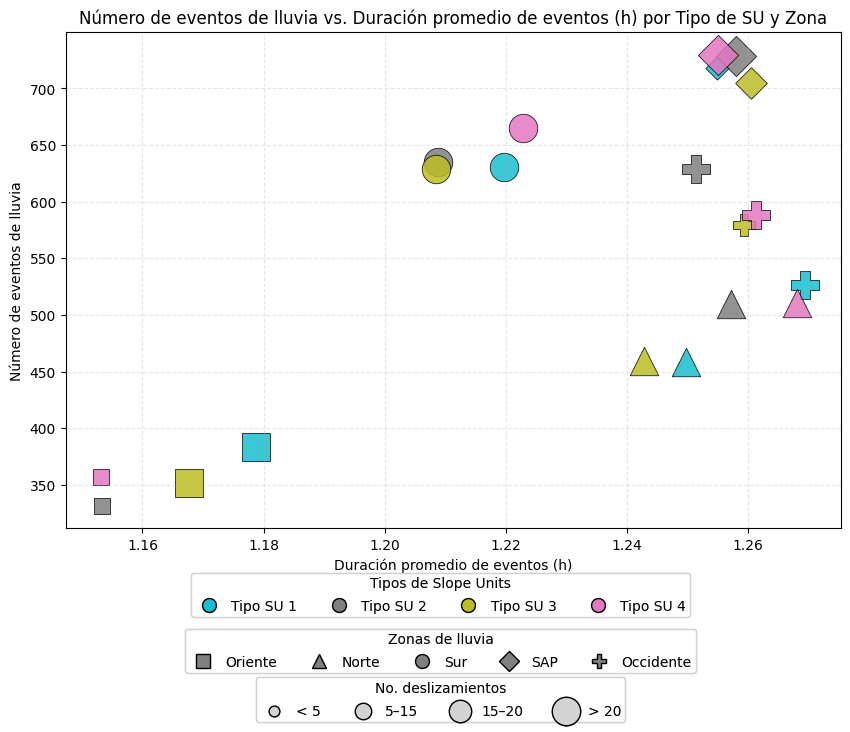

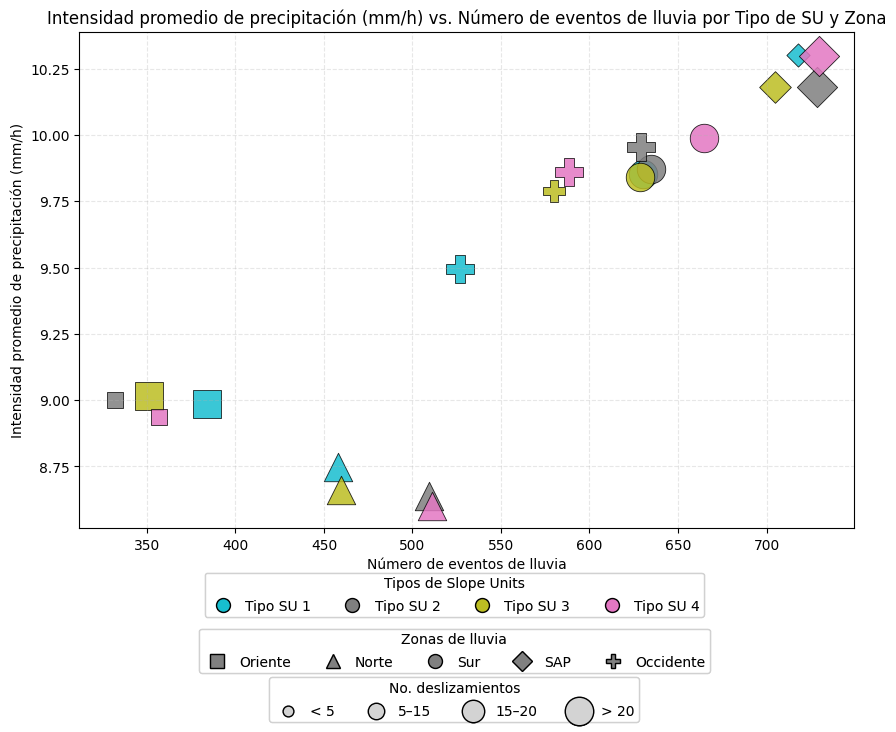

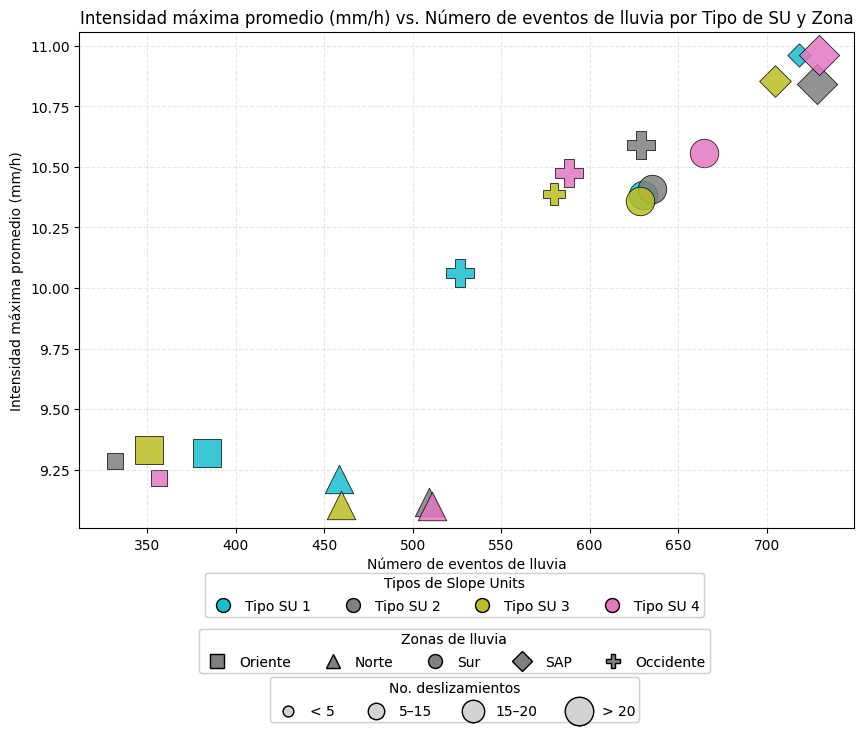

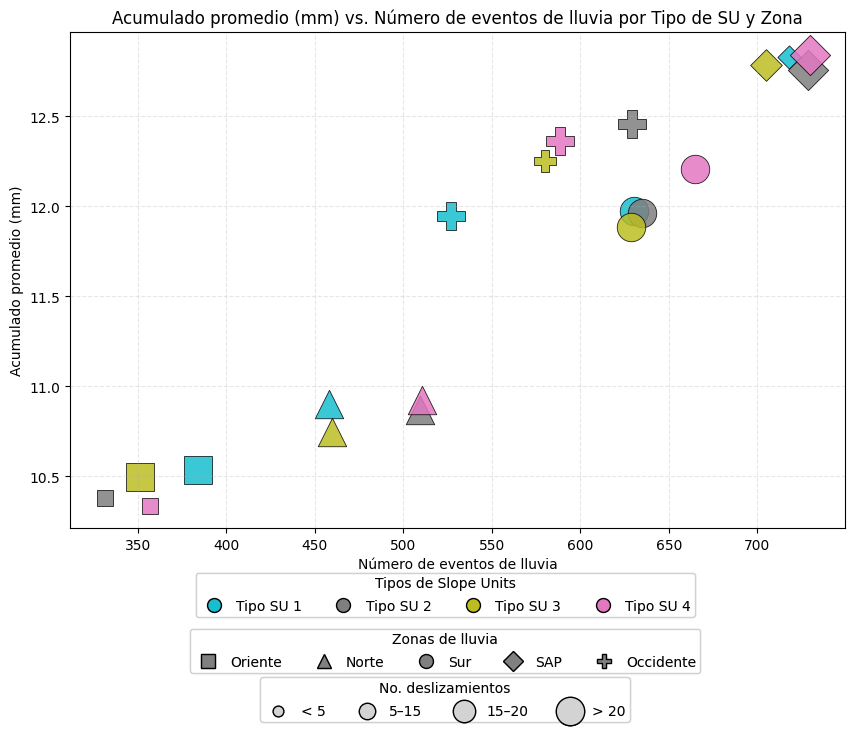

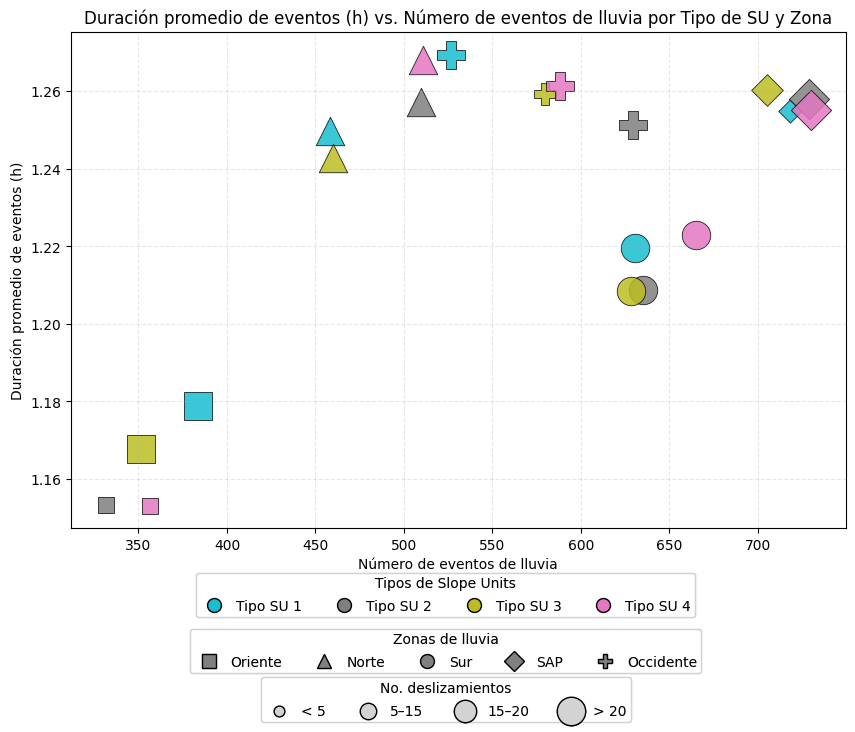

In [46]:
# ============================
# Configuración visual común
# ============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- 1) Colores por tipo de SU y marcadores por zona ---
color_por_tipo = {1: '#17becf', 2: '#7f7f7f', 3: '#bcbd22', 4: '#e377c2'}
marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}

# --- 2) Tamaños discretos por bins de deslizamientos ---
# bins = [-np.inf, 100, 200, 500, np.inf]
# bin_labels = ['< 100', '100–200', '200–500', '> 500']
# size_map = {'< 100': 60, '100–200': 140, '200–500': 260, '> 500': 420}

# --- 2) Tamaños discretos por bins de deslizamientos ---
# Bins: (-inf,100), [100,200), [200,500), [500, inf)
bins = [-np.inf, 5, 15, 20, np.inf]
bin_labels = ['< 5', '5–15', '15–20', '> 20']
# Escoge áreas (pt^2) con buena separabilidad visual
size_map = {'< 5': 60, '5–15': 140, '15–20': 260, '> 20': 420}



def _build_size_series(df):
    """Devuelve un array de tamaños a partir de df['n_mm_total'] usando bins discretos."""
    cats = pd.cut(df['n_mm_total'], bins=bins, labels=bin_labels, right=False)
    return cats.map(size_map).astype(float).values

def _add_legends(fig, ax):
    """Crea y añade las 3 leyendas (tamaños, zonas, tipos) a nivel de figura."""
    # 1) Tamaños (bins de deslizamientos)
    handles_sizes = [
        ax.scatter([], [], s=size_map[label], c='lightgray', edgecolor='k', label=label)
        for label in bin_labels
    ]
    leg1 = fig.legend(handles=handles_sizes, title='No. deslizamientos',
                      loc='lower center', bbox_to_anchor=(0.5, 0.009),
                      ncol=len(bin_labels), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 2) Zonas (formas)
    handles_zonas = [
        mlines.Line2D([], [], color='gray', marker=marker_por_zona[z], linestyle='None',
                      label=zona_label[z], markersize=10, markeredgecolor='k')
        for z in sorted(marker_por_zona.keys())
    ]
    leg2 = fig.legend(handles=handles_zonas, title='Zonas de lluvia',
                      loc='lower center', bbox_to_anchor=(0.5, 0.07),
                      ncol=len(marker_por_zona), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # 3) Tipos de SU (colores)
    handles_tipos = [
        mlines.Line2D([], [], color=color_por_tipo[t], marker='o', linestyle='None',
                      label=f'Tipo SU {t}', markersize=10, markeredgecolor='k')
        for t in sorted(color_por_tipo.keys())
    ]
    leg3 = fig.legend(handles=handles_tipos, title='Tipos de Slope Units',
                      loc='lower center', bbox_to_anchor=(0.5, 0.14),
                      ncol=len(color_por_tipo), frameon=True,
                      labelspacing=0.6, handletextpad=0.6, borderpad=0.3)

    # Asegurar que se mantengan
    fig.add_artist(leg1); fig.add_artist(leg2); fig.add_artist(leg3)

def graficar_dispersion_su(
    df, x_col, y_col,
    title=None, savepath=None,
    figsize=(10, 8), alpha=0.85
):
    """
    Grafica un scatter reutilizable para df_plot con:
      - color por tipo_su
      - marcador por zona
      - tamaño por bins de n_mm_total
    """
    # Validaciones mínimas
    req_cols = {'tipo_su', 'zona', 'n_mm_total', x_col, y_col}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    sizes = _build_size_series(df)

    fig, ax = plt.subplots(figsize=figsize)

    # Iteración por filas (mantiene la lógica exacta del original)
    for i, row in df.iterrows():
        tipo = int(row['tipo_su'])
        zona = int(row['zona'])
        x = row[x_col]
        y = row[y_col]
        s = sizes[i]  # usa el mismo índice que df
        ax.scatter(
            x, y,
            s=s,
            c=color_por_tipo.get(tipo, 'gray'),
            marker=marker_por_zona.get(zona, 'o'),
            edgecolor='k',
            linewidth=0.6,
            alpha=alpha
        )

    # Ejes y estilo
    xlabel = col_pretty.get(x_col, x_col)
    ylabel = col_pretty.get(y_col, y_col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title is None:
        # Título genérico
        title = f'{ylabel} vs. {xlabel} por Tipo de SU y Zona'
    ax.set_title(title)

    ax.grid(True, linestyle='--', alpha=0.3)

    # Leyendas compartidas a nivel de figura
    _add_legends(fig, ax)

    # Ajuste de margenes para que quepan las leyendas inferiores
    plt.subplots_adjust(bottom=0.26)

    # Guardado opcional
    if savepath:
        # Crea carpeta si no existe
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return ax  # por si quieres seguir modificando fuera



# Etiquetas legibles por columna (para ejes y títulos)
col_pretty = {
    'duracion_promedio': 'Duración promedio de eventos (h)',
    'intensidad_promedio': 'Intensidad promedio de precipitación (mm/h)',
    'intensidad_maxima_promedio': 'Intensidad máxima promedio (mm/h)',
    'acumulado_promedio': 'Acumulado promedio (mm)',
    'num_eventos': 'Número de eventos de lluvia'
}


pares = [
    ('duracion_promedio', 'intensidad_promedio'),
    ('duracion_promedio', 'intensidad_maxima_promedio'),
    ('duracion_promedio', 'acumulado_promedio'),
    ('duracion_promedio', 'num_eventos'),
    ('num_eventos', 'intensidad_promedio'),
    ('num_eventos', 'intensidad_maxima_promedio'),
    ('num_eventos', 'acumulado_promedio'),
    ('num_eventos', 'duracion_promedio')
]

# for x_col, y_col in pares:
#     titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU y Zona"
#     nombre = f"scatter_{x_col}_vs_{y_col}.png"
#     graficar_dispersion_su(
#         df_plot,
#         x_col=x_col,
#         y_col=y_col,
#         title=titulo,
#         savepath=os.path.join(output_figures, nombre)
#     )


for x_col, y_col in pares:
    titulo = f"{col_pretty.get(y_col,y_col)} vs. {col_pretty.get(x_col,x_col)} por Tipo de SU y Zona"
    nombre = f"scatter_{x_col}_vs_{y_col}.png"
    graficar_dispersion_su(
        df_plot,
        x_col=x_col,
        y_col=y_col,
        title=titulo,
        savepath=False
    )